# Imports

In [1]:
from IPython.display import Image, display, SVG, HTML
from typing import Dict, List, Tuple, Generator, Optional, Any, Literal
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
import concurrent.futures
# Print whats using memory now
import gc

# from interval_timeline import CallGraph
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.patches import Rectangle, FancyArrowPatch

import seaborn as sns
import pandas as pd
import numpy as np
import os
import re
import time
import datetime
import multiprocessing
from scipy.signal import savgol_filter, medfilt

from tqdm import tqdm
import otf2
import hatchet as ht
import thicket as tt
from collections import defaultdict


TEXLIVE_BIN_DIR = "/sw/frontier/spack-envs/base/opt/linux-sles15-x86_64/gcc-7.5.0/texlive-20220321-m56xupci4mc7hwbmnqy4oovch5pc7rrd/bin/x86_64-linux"
if TEXLIVE_BIN_DIR not in os.environ['PATH']:
    os.environ['PATH'] += os.pathsep + TEXLIVE_BIN_DIR
    print(f"Successfully added TexLive directory to PATH.")
else:
    print("TexLive directory was already in PATH.")

plt.rcParams['text.usetex'] = True

FONT_SIZE = 20
plt.rcParams.update({
    'axes.labelsize': FONT_SIZE * 0.95,        # Font size of the x and y labels
    'xtick.labelsize': FONT_SIZE * 0.9, # Font size for x-axis tick labels
    'ytick.labelsize': FONT_SIZE * 0.9, # Font size for y-axis tick labels
    # 'legend.fontsize': FONT_SIZE * 0.7,       # Font size of the legend
})

Successfully added TexLive directory to PATH.


In [2]:
# Track how long the notebook takes to run
NOTEBOOK_START_TIME = time.time()
print(f"Notebook started at {NOTEBOOK_START_TIME} ({datetime.datetime.fromtimestamp(NOTEBOOK_START_TIME)})")

Notebook started at 1766009425.6561463 (2025-12-17 17:10:25.656146)


# Preamble

### Define The Name of the Cluster & Trace Paths

Define the name of the cluster and the paths to the trace files.
This is needed to parse the trace directory paths correctly as generated by the master run script.

In [3]:
# CLUSTER_NAME = "frontier"

# ROOT_TRACE_DIR = "/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-128-node-results"

### Define Which Ranks Run on Each Node

Define the topology of the runs. This is needed to attribute energy consumption correctly. Metrics are gathered at the node level, so we
need to know which node each rank ran on to get the metrics associated with that node + rank.

In [4]:
MI250X_HPL_NODE_RANKS = {
	'node0': ['MPI Rank 0', 'MPI Rank 1', 'MPI Rank 2', 'MPI Rank 3', 'MPI Rank 4', 'MPI Rank 5', 'MPI Rank 6', 'MPI Rank 7'],
}
MI250X_HPG_NODE_RANKS = MI250X_HPL_NODE_RANKS

MI300A_HPL_NODE_RANKS = {
	'node0': ['MPI Rank 0', 'MPI Rank 1', 'MPI Rank 2', 'MPI Rank 3']
}
MI300A_HPG_NODE_RANKS = MI300A_HPL_NODE_RANKS

### Define The Metrics to Attribute to Each Rank

This defines which MPI rank is on which GCD (frontier) or APU (el capitan). Two ranks drawing from the same GPU (each GPU has 2 GCDs) will have their energy consumption estimated independently based on their exclusive runtime.

In [5]:
MI250X_HPL_RANKS_TO_METRICS = {
	'MPI Rank 0': ['A2rocm_smi:::energy_count:device=4'],
	'MPI Rank 1': ['A2rocm_smi:::energy_count:device=4'],
	'MPI Rank 2': ['A2rocm_smi:::energy_count:device=2'],
	'MPI Rank 3': ['A2rocm_smi:::energy_count:device=2'],
	'MPI Rank 4': ['A2rocm_smi:::energy_count:device=6'],
	'MPI Rank 5': ['A2rocm_smi:::energy_count:device=6'],
	'MPI Rank 6': ['A2rocm_smi:::energy_count:device=0'],
	'MPI Rank 7': ['A2rocm_smi:::energy_count:device=0'],
}
MI300A_HPL_RANKS_TO_METRICS = {
	'MPI Rank 0': ['A2rocm_smi:::energy_count:device=0'],
	'MPI Rank 1': ['A2rocm_smi:::energy_count:device=1'],
	'MPI Rank 2': ['A2rocm_smi:::energy_count:device=2'],
	'MPI Rank 3': ['A2rocm_smi:::energy_count:device=3'],
}

MI250X_HPG_RANKS_TO_METRICS = MI250X_HPL_RANKS_TO_METRICS
MI300A_HPG_RANKS_TO_METRICS = MI300A_HPL_RANKS_TO_METRICS

### Define Which Metrics to Track in the Traces

This defines the metrics we're going to pay attention to when parsing the traces.
All metrics that are used above must be included here.

In [6]:

METRICS_TO_TRACK = [
    'A2rocm_smi:::energy_count:device=0',
    'A2rocm_smi:::energy_count:device=1',
    'A2rocm_smi:::energy_count:device=2',
    'A2rocm_smi:::energy_count:device=3',
    'A2rocm_smi:::energy_count:device=4',
    'A2rocm_smi:::energy_count:device=6',
    
    'A2rocm_smi:::current_socket_power:device=0',
    'A2rocm_smi:::current_socket_power:device=1',
    'A2rocm_smi:::current_socket_power:device=2',
    'A2rocm_smi:::current_socket_power:device=3',
    
    'A2rocm_smi:::power_average:device=0:sensor=0',
    'A2rocm_smi:::power_average:device=1:sensor=0',
    'A2rocm_smi:::power_average:device=2:sensor=0',
    'A2rocm_smi:::power_average:device=3:sensor=0',
    'A2rocm_smi:::power_average:device=4:sensor=0',
    'A2rocm_smi:::power_average:device=6:sensor=0',
    
    'A2coretemp:::craypm:accel0_energy',
    'A2coretemp:::craypm:accel1_energy',
    'A2coretemp:::craypm:accel2_energy',
    'A2coretemp:::craypm:accel3_energy',
    
    'A2coretemp:::craypm:accel0_power',
    'A2coretemp:::craypm:accel1_power',
    'A2coretemp:::craypm:accel2_power',
    'A2coretemp:::craypm:accel3_power',

    'A2coretemp:::craypm:memory_power',
    'A2coretemp:::craypm:cpu_power',
    'A2coretemp:::craypm:energy',
    'A2coretemp:::craypm:power',
]

In [7]:
def process_dirname(dirroot: str, dirname: str) -> Optional[Tuple[str, str]]:
    if 'trial' not in dirname.lower():
        return None
    if 'rochplmxp' in dirname.lower():
        full_path = os.path.join(dirroot, dirname)
        return ('ROCHPL_MXP', full_path)
    elif 'rochpl' in dirname.lower():
        full_path = os.path.join(dirroot, dirname)
        return ('ROCHPL', full_path)
    elif '--run_type=standalone_mxp' in dirname.lower():
        full_path = os.path.join(dirroot, dirname)
        return ('HPG_MXP', full_path)
    elif '--run_type=standalone_ref' in dirname.lower():
        full_path = os.path.join(dirroot, dirname)
        return ('HPG', full_path)
    return None

def convert_trace_to_csv(trace_path: str):
    if os.system(f'source /lustre/orion/csc688/world-shared/scorep-amd/setup-env.sh > /dev/null 2>&1 && ./trace_to_csv_parallel --trace={trace_path} --metrics="A2coretemp:::craypm:memory_power,A2coretemp:::craypm:memory_energy,A2coretemp:::craypm:power,A2coretemp:::craypm:energy,A2coretemp:::craypm:freshness,A2coretemp:::craypm:cpu_energy,A2coretemp:::craypm:cpu_power,A2coretemp:::craypm:accel0_energy,A2coretemp:::craypm:accel0_energy_timestamp,A2coretemp:::craypm:accel0_power,A2coretemp:::craypm:accel1_energy,A2coretemp:::craypm:accel1_energy_timestamp,A2coretemp:::craypm:accel1_power,A2coretemp:::craypm:accel2_energy,A2coretemp:::craypm:accel2_energy_timestamp,A2coretemp:::craypm:accel2_power,A2coretemp:::craypm:accel3_energy,A2coretemp:::craypm:accel3_energy_timestamp,A2coretemp:::craypm:accel3_power,A2rocm_smi:::energy_count:device=0,A2rocm_smi:::energy_count:device=2,A2rocm_smi:::energy_count:device=4,A2rocm_smi:::energy_count:device=6,A2rocm_smi:::gpu_clk_freq_System:device=0:current,A2rocm_smi:::gpu_clk_freq_System:device=2:current,A2rocm_smi:::gpu_clk_freq_System:device=4:current,A2rocm_smi:::gpu_clk_freq_System:device=6:current,A2rocm_smi:::temp_current:device=0:sensor=1,A2rocm_smi:::temp_current:device=2:sensor=1,A2rocm_smi:::temp_current:device=4:sensor=1,A2rocm_smi:::temp_current:device=6:sensor=1,A2rocm_smi:::power_average:device=0:sensor=0,A2rocm_smi:::power_average:device=2:sensor=0,A2rocm_smi:::power_average:device=4:sensor=0,A2rocm_smi:::power_average:device=6:sensor=0,A2rocm_smi:::memory_busy_percent:device=0,A2rocm_smi:::memory_busy_percent:device=2,A2rocm_smi:::memory_busy_percent:device=4,A2rocm_smi:::memory_busy_percent:device=6,A2rocm_smi:::busy_percent:device=0,A2rocm_smi:::busy_percent:device=2,A2rocm_smi:::busy_percent:device=4,A2rocm_smi:::busy_percent:device=6" --outputDir={os.path.dirname(trace_path)} > /dev/null 2>&1'):
        raise RuntimeError(f"Failed to convert trace {trace_path} to CSV")

def get_trace_paths(root_dir: str) -> Dict[str, List[str]]:
    trace_paths = defaultdict(list)

    # Parallelized:
    for dirname in tqdm(os.listdir(root_dir), desc="Top-level directories"):
        dirpath = os.path.join(root_dir, dirname)
        if not os.path.isdir(dirpath):
            continue
        dirnames = os.listdir(dirpath)
        dirnames = [d for d in dirnames if os.path.isdir(os.path.join(dirpath, d))]
        if not dirnames:
            continue
        if 'rochpl' not in dirpath.lower() and 'xhpgmp' not in dirpath.lower():
            continue
        with multiprocessing.Pool(processes=os.cpu_count() or 16) as pool:
            results = pool.starmap(process_dirname, [(dirpath, dirname) for dirname in dirnames])
            for result in results:
                if result is not None:
                    benchmark_name, full_path = result
                    trace_paths[benchmark_name].append(full_path)

    # for dirname in tqdm(os.listdir(root_dir), desc="Converting traces to CSV"):
    #     if not os.path.isdir(os.path.join(root_dir, dirname)):
    #         continue
    #     dirroot = os.path.join(root_dir, dirname)
    #     # for trialdir in tqdm(os.listdir(dirroot), desc="Trial directories", leave=False):
    #     #     # Check if there's an OTF2 file and no CSV files
    #     #     trace = os.path.join(dirroot, trialdir, 'traces.otf2')
    #     #     if not os.path.exists(trace):
    #     #         continue
    #     #     if os.path.exists(os.path.join(dirroot, trialdir, 'MPI Rank 0_Master_thread_callgraph.csv')):
    #     #         continue
    #     #     # Convert the trace to CSV
    #     #     os.system(f'source /lustre/orion/csc688/world-shared/scorep-amd/setup-env.sh > /dev/null 2>&1 && ./trace_to_csv_parallel --trace={trace} --metrics="{",".join(METRICS_TO_TRACK)}" --outputDir={os.path.dirname(trace)} > /dev/null 2>&1')
    #     # Do it in parallel instead
    #     dirnames = os.listdir(dirroot)
    #     dirnames = [d for d in dirnames if os.path.isdir(os.path.join(dirroot, d))]
    #     if not dirnames:
    #         continue
    #     with multiprocessing.Pool(processes=8) as pool:
    #         pool.map(
    #             # lambda trialdir: os.system(f'source /lustre/orion/csc688/world-shared/scorep-amd/setup-env.sh > /dev/null 2>&1 && ./trace_to_csv_parallel --trace={os.path.join(dirroot, trialdir, "traces.otf2")} --metrics="{",".join(METRICS_TO_TRACK)}" --outputDir={os.path.join(dirroot, trialdir)} > /dev/null 2>&1') 
    #             convert_trace_to_csv,
    #             # [os.path.join(dirroot, trialdir, 'traces.otf2') for trialdir in dirnames if os.path.exists(os.path.join(dirroot, trialdir, 'traces.otf2'))]
    #             [os.path.join(dirroot, trialdir, 'traces.otf2') for trialdir in dirnames if os.path.exists(os.path.join(dirroot, trialdir, 'traces.otf2')) and not os.path.exists(os.path.join(dirroot, trialdir, 'MPI Rank 0_Master_thread_callgraph.csv'))]
    #         )
    
    # Wait for all processes to finish
    # for process in tqdm(processes, desc="Converting traces to CSV"):
    #     process.join()

    return trace_paths

print("Collecting MI250X paths...")
if 'MI250X_TRACES' not in globals():
    # MI250X_TRACES = get_trace_paths("/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-128-node-results")
    MI250X_TRACES = get_trace_paths("/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-results-with-memory-power")
print("Collecting MI300A trace paths...")
if 'MI300A_TRACES' not in globals():
    MI300A_TRACES = get_trace_paths("/lustre/orion/csc688/world-shared/results-mi300a-organized")

print(MI250X_TRACES)
print({k: len(v) for k, v in MI250X_TRACES.items()})
print(MI300A_TRACES)
print({k: len(v) for k, v in MI300A_TRACES.items()})

Top-level directories: 100%|██████████| 204/204 [00:07<00:00, 28.52it/s]


Top-level directories: 100%|██████████| 108/108 [00:08<00:00, 12.65it/s]

defaultdict(<class 'list'>, {'ROCHPL_MXP': ['/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-results-with-memory-power/rochplmxp-r8--P_1_-Q_8_-N_245760/trial_3-frontier08146-r8-rochplmxp--P_1_-Q_8_-N_245760', '/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-results-with-memory-power/rochplmxp-r8--P_1_-Q_8_-N_245760/trial_1-frontier09214-r8-rochplmxp--P_1_-Q_8_-N_245760', '/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-results-with-memory-power/rochplmxp-r8--P_1_-Q_8_-N_245760/trial_2-frontier08061-r8-rochplmxp--P_1_-Q_8_-N_245760', '/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-results-with-memory-power/rochplmxp-r8--P_1_-Q_8_-N_245760/trial_1-frontier00252-r8-rochplmxp--P_1_-Q_8_-N_245760', '/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-results-with-memory-power/rochplmxp-r8--P_1_-Q_8_-N_245760/trial_3-frontier06528-r8-rochplmxp--P_1_-Q_8_-N_245760', '/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-results-with-mem

### Metrics
Which metrics to trace, and functions for reading/writing them to CSVs.

In [8]:
# # def callgraph_to_csv(call_graph: CallGraph, group: str, thread: str, filename: str):
# #     """Convert a CallGraph to a CSV file."""
# #     with open(filename, 'w') as f:
# #         f.write("Thread,Group,Depth,Name,Start Time,End Time,Duration\n")
# #         intervals = call_graph.get_intervals_between(float('-inf'), float('inf'))
        
# #         for interval in intervals:
# #             start = interval.start
# #             end = interval.end or float('inf')
# #             duration = end - start
# #             name = interval.name if interval.name else "Unknown"
# #             depth = interval.depth if interval.depth else 0

# #             f.write(f"{thread},{group},{depth},\"{name}\",{start},{end},{duration}\n")

# def metrics_to_csv(group: str, thread_metrics: Dict[str, List[Tuple[float, float]]], filename: str):
#     """Convert metrics to a CSV file."""
#     with open(filename, 'w') as f:
#         f.write("Group,Metric Name,Time,Value\n")
#         for metric_name, values in thread_metrics.items():
#             for time, value in values:
#                 f.write(f"{group},{metric_name},{time},{value}\n")

# def read_metrics_dataframe(file: str) -> pd.DataFrame:
#     print(f"Reading metrics from {file}...")
#     df = pd.read_csv(file)
#     df = df[df['Metric Name'].isin(METRICS_TO_TRACK)]
#     # For all the rocm metrics, divide by 1e6 to convert from uJ to J
#     for metric_name in df['Metric Name'].unique():
#         if 'rocm_smi:::energy_count:device' in metric_name or 'rocm_smi:::power_average:device' in metric_name or 'rocm_smi:::current_socket_power:device' in metric_name:
#             df['Value'] = df['Value'].astype(float)
#             df['Value'] = df['Value'].fillna(0.0)
#             df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000
#     return df


#     # df = dd.read_csv(file)
#     # df = df[df['Metric Name'].isin(METRICS_TO_TRACK)]
#     # for metric_name in df['Metric Name'].unique():
#     #     if 'rocm_smi:::energy_count:device' in metric_name or 'rocm_smi:::power_average:device' in metric_name or 'rocm_smi:::current_socket_power:device' in metric_name:
#     #         # First, fill all NaN values with 0
#     #         df['Value'] = df['Value'].astype(float)
#     #         df['Value'] = df['Value'].fillna(0.0)
#     #         # df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000.0
#     #         # Cant use loc with dask, so use mask
#     #         mask = (df['Metric Name'] == metric_name).astype('bool')
#     #         df['Value'] = df['Value'] / 1_000_000.0 * mask + df['Value'] * (~mask)
#     # return df.compute()

# def read_call_graph_dataframe(file: str) -> pd.DataFrame:
#     print(f"Reading call graph from {file}...")
#     return pd.read_csv(file)



# def read_optimized_metrics(path: str) -> pd.DataFrame:
#     dtype_map = {
#         'Group': 'category',
#         'Metric Name': 'category',
#         # 'Time': 'float64',
#         # 'Value': 'int64' # Int64 for precision
#     }
#     return pd.read_csv(path, dtype=dtype_map, engine='c')

# def read_optimized_callgraph(path: str) -> pd.DataFrame:
#     dtype_map = {
#         'Thread': 'category',
#         'Group': 'category',
#         'Depth': 'uint32',
#         'Name': 'category',
#         # 'Start Time': 'float64',
#         # 'End Time': 'float64',
#         # 'Duration': 'float64'
#     }
#     return pd.read_csv(path, dtype=dtype_map, engine='c')

def metrics_to_csv(group: str, thread_metrics: Dict[str, List[Tuple[float, float]]], filename: str):
    """Convert metrics to a CSV file."""
    with open(filename, 'w') as f:
        f.write("Group,Metric Name,Time,Value\n")
        for metric_name, values in thread_metrics.items():
            for time, value in values:
                f.write(f"{group},{metric_name},{time},{value}\n")

def read_metrics_dataframe(file: str) -> pd.DataFrame:
    dtype_map = {
        'Group': 'category',
        'Metric Name': 'category',
        'Time': 'float64',
        'Value': 'int64' # Int64 for precision
    }
    df = pd.read_csv(file, dtype=dtype_map)
    df = df[df['Metric Name'].isin(METRICS_TO_TRACK)]
    # For all the rocm metrics, divide by 1e6 to convert from uJ to J
    for metric_name in df['Metric Name'].unique():
        if 'rocm_smi:::energy_count:device' in metric_name or 'rocm_smi:::power_average:device' in metric_name or 'rocm_smi:::current_socket_power:device' in metric_name:
            df['Value'] = df['Value'].astype(float)
            df['Value'] = df['Value'].fillna(0.0)
            df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000
    return df

def read_call_graph_dataframe(file: str) -> pd.DataFrame:
    dtype_map = {
        'Thread': 'category',
        'Group': 'category',
        'Depth': 'uint32',
        'Name': 'category',
        'Start Time': 'float64',
        'End Time': 'float64',
        'Duration': 'float64'
    }
    return pd.read_csv(file, dtype=dtype_map)


### Remove Conflicting CSVs
Remove any existing CSVs that might conflict with new ones to be generated.

In [9]:
# # Remove all the old CSV files
# for file in os.listdir('.'):
#     if file.endswith('.csv'):
#         os.remove(file)

### Setup for Loading Traces
Convert an OTF2 to a CSV dataset to be loaded into a dataframe

In [10]:
# # Walk the root trace dir and convert all OTF2 traces to CSV using trace_to_csv_parallel
# for dirpath, dnames, filenames in tqdm(os.walk(ROOT_TRACE_DIR)):
#     trace = os.path.join(dirpath, 'traces.otf2')
#     if not os.path.exists(trace):
#         continue
#     if os.path.exists(os.path.join(dirpath, 'MPI Rank 0_Master_thread_callgraph.csv')):
#         continue
#     cmd = f'source /lustre/orion/csc688/world-shared/scorep-amd/setup-env.sh > /dev/null 2>&1 && ./trace_to_csv_parallel --trace={trace} --metrics="{",".join(METRICS_TO_ATTRIBUTE)}" --outputDir={os.path.dirname(trace)} > /dev/null 2>&1'
#     os.system(cmd)
    
    
#     # trace = trace[0]
#     # if not trace.endswith(".otf2"):
#     #     print("Skipping:", trace)
#     #     continue
#     # print(f"Processing trace: {trace}")
#     # cmd = f'source /lustre/orion/csc688/world-shared/scorep-amd/setup-env.sh && ./trace_to_csv_parallel --trace={trace} --metrics="{",".join(METRICS_TO_ATTRIBUTE)}" --outputDir={os.path.dirname(trace)}'
#     # print(cmd)
#     # os.system(cmd)

In [11]:
# def trace_to_csv(trace: str, processes_to_track: List[str], metrics_to_track: List[str] = METRICS_TO_ATTRIBUTE, cray_time_offset=0.0):
#     # Remove all the old CSV files
#     for file in os.listdir('.'):
#         if file.endswith('.csv'):
#             os.remove(file)
#     # Shell out to ./trace_to_csv_parallel binary with `./trace_to_csv_parallel --tracePath=/path/to/trace.otf2`
#     print(f'Tracking metrics: {metrics_to_track}')
#     # Shell out to ./trace_to_csv_parallel binary with `./trace_to_csv_parallel --tracePath=/path/to/trace.otf2`
#     cmd = f'./trace_to_csv_parallel --trace={trace} --metrics="{",".join(metrics_to_track)}"'
#     # Add the shared library path for OTF2
#     cmd = f'source /lustre/orion/csc688/world-shared/scorep-amd/setup-env.sh && ' + cmd
#     os.system(cmd)

def trace_to_csv(trace: str, processes_to_track: List[str], metrics_to_track: List[str] = METRICS_TO_TRACK, cray_time_offset=0.0):
    pass
    # # Remove all the old CSV files
    # for file in os.listdir('.'):
    # 	if file.endswith('.csv'):
    # 		os.remove(file)
    # # Shell out to ./trace_to_csv_parallel binary with `./trace_to_csv_parallel --tracePath=/path/to/trace.otf2`
    # print(f'Tracking metrics: {metrics_to_track}')
    # # Shell out to ./trace_to_csv_parallel binary with `./trace_to_csv_parallel --tracePath=/path/to/trace.otf2`
    # cmd = f'./trace_to_csv_parallel --trace={trace} --metrics="{",".join(metrics_to_track)}"'
    # os.system(cmd)
    # Instead of getting the OTF2 trace and producing a CSV, we get the CSVs directly from the provided trace path    
    # So, copy the files from the same trace to the current directory. This means getting everything before `MPI Rank ...` in the trace path
    # And copying the matching files to the current directory
    # Get everything up to `MPI Rank ...` in the trace path
    # print('Getting prefix from:', trace)
    # trace_base = re.match(rf"^(.*)MPI Rank \d+", trace).group(1)
    
    # print(f'Copying files from trace base: {trace}')
    
    # # Get all the files in the trace base directory
    # all_files = os.listdir(trace)
    # # Copy them to the current directory if they match the processes to track
    # for file in all_files:
    #     dst = file
    #     # Trim off everything up to `MPI Rank ...` in the filename
    #     start = dst.find('MPI Rank')
    #     if start != -1:
    #         dst = dst[start:]
        
    #     if os.system(f'cp \"{os.path.join(trace, file)}\" \"{dst}\"'):
    #         # print(f"File {file} does not exist in trace {trace}.")
    #         break
    #     # else:
    #     #     print(f'Copied {dst} from trace {trace} to current directory.')
    
    # for process in processes_to_track:
    #     # Copy metrics CSV
    #     # metrics_src = f"{trace_base}{process}*.csv"
    #     # Perform the glob
    #     glob_pattern = f"{trace_base}{process}*.csv"
    #     files = [f for f in os.listdir(os.path.dirname(trace_base)) if re.match(rf"{os.path.basename(trace_base)}{re.escape(process)}.*\.csv", f)]
    #     for file in files:
    #         metrics_src = os.path.join(os.path.dirname(trace_base), file)
    #         # metrics_dst = f"."
    #         # Get only only the `MPI Rank ..._metrics.csv` part of the filename
    #         metrics_dst = file
    #         # Trip everything before `MPI Rank ...` in the filename
    #         metrics_dst = re.sub(rf"^.*?(MPI Rank \d+.*)", r"\1", metrics_dst)
    #         print(f'Copying {metrics_src} to {metrics_dst}')
    #         if os.system(f'cp \"{metrics_src}\" \"{metrics_dst}\"'):
    #             print(f"CSV files at {metrics_src} does not exist.")
    #         else:
    #             print(f"Copied {metrics_src} to {metrics_dst}")


# Visualize the dataframes
def visualize_dataframe(df):
    """Visualize the first few rows of a DataFrame as HTML."""
    # pd.set_option("display.width", 2400)
    # pd.set_option("display.max_colwidth", 100)
    # pd.set_option("display.max_rows", 20)
    
    display(HTML(df.head(n=20).to_html(index=False)))


### Math Helpers

Helpers for linearly interpolating values and computing numerical integrals + derivatives

In [12]:
def sampled_to_continuous(df, time_col='Time', value_col='Value'):
    t_samples = df[time_col].astype(float)
    y = df[value_col].astype(float)
    # Apply a savgol filter to smooth the data
    # y = scipy.signal.savgol_filter(y, window_length=11, polyorder=2, mode='nearest')
    # Apply a median filter to smooth the data
    # y = scipy.signal.medfilt(y, kernel_size=11)
 
    # Create a continuous function that interpolates the sampled data
    f = lambda t: np.interp(t, t_samples, y)
    return f

def numerical_derivative(func, h=1e-5):
    """Compute the numerical derivative of a function at a point t."""
    return lambda t: (func(t + h) - func(t - h)) / (2 * h)

def numerical_integral(f, a=0.0, dx=1e-1):
    """
    Return a function F(x) that approximates the integral of f(t) dt from t=a to t=x,
    using the trapezoidal rule in a fully vectorized manner.
    The function F(x) will return a scalar when x is a scalar, and an array
    when x is an array.
    """
    # Determinar si f soporta arrays de NumPy
    try:
        _ = f(np.array([a, a + dx]))
        f_np = f
    except Exception:
        f_np = np.vectorize(f)
    
    def F(x):
        x_arr = np.atleast_1d(x).astype(float)
        # Manejo de x < a invirtiendo signo
        sign = np.ones_like(x_arr)
        mask = x_arr < a
        sign[mask] = -1
        x_pos = np.where(mask, a + (a - x_arr), x_arr)
        
        # Grid hasta el máximo de x
        xmax = x_pos.max()
        t = np.arange(a, xmax + dx, dx)
        u = f_np(t)
        
        # Suma acumulada de trapecios
        trap_heights = (u[:-1] + u[1:]) / 2
        cum = np.concatenate(([0], np.cumsum(trap_heights * dx)))
        
        # Índices y remanentes
        idx = ((x_pos - a) // dx).astype(int)
        rem = x_pos - (a + idx * dx)
        
        # Valores en fronteras
        f_end = f_np(x_pos)
        f_start = u[idx]
        
        # Integral aproximada
        integral = cum[idx] + (f_start + f_end) * rem / 2
        result = sign * integral
        
        # Devolver escalares cuando corresponda
        return result.item() if np.isscalar(x) else result
    
    return F
        
def continuous_savgol_filter(f, window_length=11, polyorder=2, sample_rate=0.001):
    """
    Return a smoothed version of the continuous function f using a Savitzky-Golay filter.
    The function f is sampled at intervals of sample_rate to apply the filter.
    """
    def f_smooth(t):
        t = np.asarray(t)
        t_min = t.min()
        t_max = t.max()
        t_samples = np.arange(t_min, t_max + sample_rate, sample_rate)
        y_samples = f(t_samples)
        y_smooth = savgol_filter(y_samples, window_length=window_length, polyorder=polyorder, mode='nearest')
        return np.interp(t, t_samples, y_smooth)
    return f_smooth

def continuous_savgol_derivative(f, window_length=15, polyorder=3, sample_rate=0.001):
    """
    Return the derivative (d/dt) of the continuous function f using a Savitzky-Golay filter.
    
    Args:
        f: Callable continuous function (e.g., interpolated energy).
        window_length: Length of the filter window (odd integer).
        polyorder: Order of the polynomial to fit.
        sample_rate: The uniform spacing (dt) used for resampling.
        
    Returns:
        A callable function representing the derivative of f.
    """
    def f_prime(t):
        t = np.asarray(t)
        
        # 1. Create a uniform grid covering the requested time range
        # We need this because SavGol requires uniform spacing
        t_min = t.min()
        t_max = t.max()
        
        # Handle edge case: if t is a single point or range is smaller than window
        # We pad slightly to ensure the window fits if the user queries a small range
        if (t_max - t_min) < (window_length * sample_rate):
            pad = (window_length * sample_rate) / 2
            t_min -= pad
            t_max += pad

        t_samples = np.arange(t_min, t_max + sample_rate, sample_rate)
        
        # 2. Sample the input function
        y_samples = f(t_samples)
        
        # 3. Apply SavGol Derivative
        # deriv=1: Calculate 1st derivative (Slope)
        # delta=sample_rate: Scales the derivative by time (dy/dt)
        # mode='interp' or 'nearest': Handles boundaries
        y_deriv = savgol_filter(
            y_samples, 
            window_length=window_length, 
            polyorder=polyorder, 
            deriv=1, 
            delta=sample_rate, 
            mode='nearest'
        )
        
        # 4. Interpolate back to the specific query times 't'
        return np.interp(t, t_samples, y_deriv)
        
    return f_prime
        
def continous_median_filter(f, kernel_size=11, sample_rate=0.001):
    """
    Return a smoothed version of the continuous function f using a median filter.
    The function f is sampled at intervals of sample_rate to apply the filter.
    """
    def f_smooth(t):
        t = np.asarray(t)
        t_min = t.min()
        t_max = t.max()
        t_samples = np.arange(t_min, t_max + sample_rate, sample_rate)
        y_samples = f(t_samples)
        y_smooth = medfilt(y_samples, kernel_size=kernel_size)
        return np.interp(t, t_samples, y_smooth)
    return f_smooth        

def unwrap_or_zero(f):
    if not f:
        return 0.0
    else:
        return f


### Thicket + Hatchet Integration
Convert the CSV datasets into thicket/hatchet objects for analysis

In [13]:
def create_hatchet_dag(call_graph_df: pd.DataFrame, metric_functions: Dict[str, callable]):
    df = call_graph_df.copy()
    # Asume que viene “bien formado”: cada fila es una invocación con Depth que respeta el anidamiento.
    # Si no está ordenado por Start Time, ordénalo una vez.
    df = df.sort_values(by='Start Time')

    # Filtrado opcional por duración, replica tu lógica si quieres:
    df = df[df['Duration'] >= 0.001]

    pref3 = df['Name'].str[:3].str.lower()
    df = df[~pref3.isin(['hip', 'mpi'])]
    
    # Vectoriza cálculo de métricas por fila (Δ = f(end) - f(start))
    starts = df['Start Time'].to_numpy()
    ends   = df['End Time'].to_numpy()
    names  = df['Name'].to_numpy()
    depths = df['Depth'].to_numpy()
    durs   = df['Duration'].to_numpy()


    metrics_cols = {}
    for metric, f in tqdm(metric_functions.items()):
        try:
            vals = f(ends) - f(starts)            # ideal: f soporta arrays
            vals = np.asarray(vals, dtype=float)
            vals = np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0)
        except Exception:
            # Fallback si f no vectoriza
            vals = np.fromiter(
                (unwrap_or_zero(f(e) - f(s)) for s, e in zip(starts, ends)),
                dtype=float, count=len(starts)
            )
        metrics_cols[metric] = vals

    # Construcción del DAG con una pila indexada por profundidad
    # Mantenemos las referencias a los últimos nodos por cada Depth.
    # Cuando Depth sube, el nuevo nodo se anexa como hijo del nodo en Depth-1.
    dag_roots: list = []
    last_at_depth: dict[int, dict] = {}

    # Usamos itertuples para bajo overhead
    M = len(df)
    for i, (name, depth, dur) in enumerate(zip(names, depths, durs)):
        node_metrics = {'time (inc)': float(dur), 'time': 0.0}
        for m, arr in metrics_cols.items():
            node_metrics[m] = float(arr[i])

        node = {'frame': {'name': name}, 'metrics': node_metrics, 'children': []}

        if depth == 0 or (depth - 1) not in last_at_depth:
            dag_roots.append(node)
        else:
            parent = last_at_depth[depth - 1]
            parent['children'].append(node)

        last_at_depth[depth] = node

        # Si retrocede la profundidad en la siguiente fila, iremos sobreescribiendo last_at_depth
        # No hace falta “cerrar” nada aún; calculamos 'time' más adelante en una segunda pasada.

    # Segunda pasada postorden para calcular 'time' = 'time (inc)' - suma hijos.
    # Podemos hacerlo con una DFS iterativa.
    stack = [(root, False) for root in dag_roots]
    while stack:
        node, visited = stack.pop()
        if not visited:
            stack.append((node, True))
            for ch in node['children']:
                stack.append((ch, False))
        else:
            child_incs = 0.0
            for ch in node['children']:
                child_incs += ch['metrics']['time (inc)']
            node['metrics']['time'] = node['metrics']['time (inc)'] - child_incs

    return dag_roots

# Hierarchical DataFrames

Organize the data into hierarchical dataframes for easier analysis:
- `Ensemble`: all the runs of a given configuration
- `Run`: a single run of a configuration
- `Node`: a single node in a run
- `Rank`: a single MPI rank in a node

In [14]:
# class Rank:
#     def __init__(self, node: str, name: str, call_graph: pd.DataFrame):
#         self.node = node
#         self.name = name
#         self.call_graph = call_graph
#         assert self.call_graph.columns.tolist() == ['Thread', 'Group', 'Depth', 'Name', 'Start Time', 'End Time', 'Duration'], f"Call graph DataFrame has incorrect columns, found {call_graph.columns.tolist()}"
        
#     def get_all_code_regions(self) -> List[str]:
#         return self.call_graph['Name'].unique().tolist()

#     def compute_attribution(
#         self,
#         metrics_accumulated: Dict[str, callable],
#         duration_threshold: float = 0.001,
#         weights_by_metric: Optional[Dict[str, np.ndarray]] = None):
#         df = self.call_graph
#         df = df[df['Duration'] >= duration_threshold]
#         pref3 = df['Name'].str[:3].str.lower()
#         df = df[~pref3.isin(['hip', 'mpi'])]

#         if df.empty:
#             return pd.DataFrame(columns=['Code Region'] + list(metrics_accumulated.keys()))

#         starts = df['Start Time'].to_numpy()
#         ends   = df['End Time'].to_numpy()
#         names  = df['Name'].to_numpy()

#         cols = {}
#         for metric, f in metrics_accumulated.items():
#             try:
#                 deltas = f(ends) - f(starts)
#                 deltas = np.asarray(deltas, dtype=float)
#                 deltas = np.nan_to_num(deltas, nan=0.0, posinf=0.0, neginf=0.0)
#             except Exception:
#                 deltas = np.fromiter(
#                     (unwrap_or_zero(f(e) - f(s)) for s, e in zip(starts, ends)),
#                     dtype=float, count=len(starts)
#                 )

#             # Apply weights if present for this metric (1.0 if not provided)
#             if weights_by_metric and metric in weights_by_metric:
#                 w = np.asarray(weights_by_metric[metric], dtype=float)
#                 if w.shape[0] == deltas.shape[0]:
#                     deltas = deltas * w
#                 elif w.size == 1:
#                     deltas = deltas * float(w)
#                 else:
#                     # Safe fallback if the length does not match for some reason
#                     deltas = deltas * 1.0

#             cols[metric] = deltas

#         out = pd.DataFrame(cols)
#         out['Code Region'] = names
#         # Aggregate by region
#         out = out.groupby('Code Region', as_index=False).sum()
#         return out

#     def refresh(self):
#         return Rank(self.node, self.name, self.call_graph)

#     def __str__(self):
#         return f"Rank({self.name})"

# def build_inclusive_masks_for_rank(breaks, s, e, names, depths):
#     """
#     For each segment [breaks[i], breaks[i+1]), return a dict:
#       masks[region_name][i] = True  iff the region is on the call stack
#                                    (ancestor of top-of-stack) for the ENTIRE segment.
#     Assumptions:
#       - breaks includes all start/end times (so inside a segment no boundary occurs).
#       - 'depths' is 0-based, increasing with nesting.
#     """
#     seg_count = breaks.size - 1
#     masks = defaultdict(lambda: np.zeros(seg_count, dtype=bool))

#     lefts, rights = breaks[:-1], breaks[1:]
#     for i in range(seg_count):
#         L, R = lefts[i], rights[i]

#         # Regions that cover the whole segment (active across the entire segment)
#         idx = np.where((s <= L) & (e >= R))[0]
#         if idx.size == 0:
#             continue

#         # Top of stack depth
#         dmax = depths[idx].max()

#         # Inclusive chain = exactly one region per depth 0..dmax that covers the whole segment
#         # (there should typically be at most one per depth due to proper nesting)
#         for d in range(dmax + 1):
#             cand = idx[depths[idx] == d]
#             if cand.size:
#                 # If instrumentation duplicates exist at same depth, pick the one that covers the segment;
#                 # here cand already covers segment; pick the first deterministically.
#                 j = cand[0]
#                 masks[names[j]][i] = True

#     return masks

# class Node:
#     def __init__(self, name: str, metrics_df: pd.DataFrame, ranks: List[Rank]):
#         self.name = name
#         self.ranks = ranks
#         self.metrics = metrics_df
#         assert self.metrics.columns.tolist() == ['Group', 'Metric Name', 'Time', 'Value'], f"Metrics DataFrame has incorrect columns, found {metrics_df.columns.tolist()}"

#     def refresh(self):
#         return Node(self.name, self.metrics, [rank.refresh() for rank in self.ranks])

#     def get_metric_names(self) -> List[str]:
#         return self.metrics['Metric Name'].unique().tolist()
    
#     def get_metric_samples(self, metric_name: str) -> pd.DataFrame:
#         return self.metrics[self.metrics['Metric Name'] == metric_name]

#     def _filtered_callgraph(self, rank: Rank, duration_threshold: float):
#         df = rank.call_graph
#         df = df[df['Duration'] >= duration_threshold]
#         pref3 = df['Name'].str[:3].str.lower()
#         df = df[~pref3.isin(['hip', 'mpi'])]
#         # Finite and non-degenerate
#         mfin = np.isfinite(df['Start Time']) & np.isfinite(df['End Time'])
#         df = df[mfin & (df['End Time'] > df['Start Time'])]
#         return df

#     def compute_attribution(
#         self,
#         ranks_to_metrics: Dict[str, List[str]] = {},
#         instantaneous_metrics = [],
#         duration_threshold: float = 0.001,
#     ):
#         # --- Only the metrics actually used ---
#         used_metrics = sorted({m for ml in ranks_to_metrics.values() for m in ml})
#         if not used_metrics:
#             return pd.DataFrame(columns=['Code Region'])

#         # accumulated f(t) per metric (if instantaneous, integrate first)
#         metrics_continuous = {m: sampled_to_continuous(self.get_metric_samples(m)) for m in used_metrics}
#         metrics_accumulated = {
#             m: (numerical_integral(metrics_continuous[m]) if m in instantaneous_metrics else metrics_continuous[m])
#             for m in used_metrics
#         }
#         # print(f"Node {self.name} has metrics: {list(metrics_accumulated.keys())}")

#         # --- Pre-filtered by rank (and base arrays, incl. Depth) ---
#         rank_df = {r.name: self._filtered_callgraph(r, duration_threshold) for r in self.ranks}
#         rank_events = {
#             rname: (
#                 df['Start Time'].to_numpy(),
#                 df['End Time'].to_numpy(),
#                 df['Name'].to_numpy(),
#                 df['Depth'].astype(int).to_numpy()
#             )
#             for rname, df in rank_df.items()
#         }

#         # metric -> ranks that use it
#         metric_to_ranks: Dict[str, List[str]] = {}
#         for rname, mlist in ranks_to_metrics.items():
#             for m in mlist:
#                 metric_to_ranks.setdefault(m, []).append(rname)

#         # Accumulator: per rank → per region → per metric → energy
#         rank_tables: Dict[str, Dict[str, Dict[str, float]]] = {r.name: {} for r in self.ranks}

#         # --- Loop per metric: segment time, split across ranks, and attribute inclusively ---
#         for metric in used_metrics:
#             f = metrics_accumulated[metric]
#             rnames = [rn for rn in metric_to_ranks.get(metric, []) if rn in rank_events]
#             if not rnames:
#                 continue

#             # Global cuts (union of starts/ends of these ranks)
#             all_s, all_e = [], []
#             for rn in rnames:
#                 s, e, _, _ = rank_events[rn]
#                 if s.size:
#                     all_s.append(s); all_e.append(e)
#             if not all_s:
#                 continue

#             S_concat = np.concatenate(all_s)
#             E_concat = np.concatenate(all_e)
#             breaks = np.unique(np.concatenate([S_concat, E_concat]))
#             breaks = breaks[np.isfinite(breaks)]
#             if breaks.size < 2:
#                 continue
#             seg_count = breaks.size - 1

#             # ΔE per segment (sanitized)
#             try:
#                 E_vals = f(breaks)
#                 E_vals = np.asarray(E_vals, dtype=float)
#                 if E_vals.shape != breaks.shape:
#                     raise ValueError
#             except Exception:
#                 print(f"Warning: Non-vectorized metric function for metric {metric}, falling back to loop.")
#                 E_vals = np.array([float(f(float(t))) for t in breaks], dtype=float)

#             dE = E_vals[1:] - E_vals[:-1]
#             dE = np.nan_to_num(dE, nan=0.0, posinf=0.0, neginf=0.0)
#             dE = np.maximum(dE, 0.0)

#             # Which ranks are active in each segment?
#             active_by_rank: Dict[str, np.ndarray] = {}
#             lr_by_rank: Dict[str, Tuple[np.ndarray, np.ndarray]] = {}

#             zeros_seg = np.zeros(seg_count, dtype=bool)
#             for rn in rnames:
#                 s, e, _, _ = rank_events[rn]
#                 if s.size == 0:
#                     active_by_rank[rn] = zeros_seg
#                     lr_by_rank[rn] = (np.empty(0, dtype=int), np.empty(0, dtype=int))
#                     continue

#                 L = np.searchsorted(breaks, s, side='right') - 1
#                 R = np.searchsorted(breaks, e, side='left') - 1
#                 valid = (R >= L) & (R >= 0) & (L < seg_count)
#                 L = np.clip(L[valid], 0, seg_count - 1)
#                 R = np.clip(R[valid], 0, seg_count - 1)

#                 lr_by_rank[rn] = (L, R)

#                 # coverage count via difference array
#                 diff = np.zeros(seg_count + 1, dtype=int)
#                 # vectorized add/sub using slices
#                 # (loop remains but touches integers only; fast and cache-friendly)
#                 for l, r in zip(L, R):
#                     diff[l] += 1
#                     diff[r + 1] -= 1
#                 c = np.cumsum(diff[:-1])
#                 active_by_rank[rn] = (c > 0)

#             # k(t): number of active ranks per segment
#             k = np.zeros(seg_count, dtype=int)
#             for rn in rnames:
#                 k += active_by_rank[rn].astype(int)

#             # Energy share per segment for each rank: ΔE/k (if k==0, remains unattributed)
#             share_per_seg = np.zeros_like(dE, dtype=float)
#             mask_k = (k > 0)
#             share_per_seg[mask_k] = dE[mask_k] / k[mask_k]

#             # Inclusive attribution per rank: replicate share_per_seg to the entire inclusive chain
#             for rn in rnames:
#                 s, e, names, depths = rank_events[rn]
#                 if s.size == 0:
#                     continue

#                 # Fast coverage masks per region using L/R (equivalent to inclusive chain under proper nesting):
#                 # region mask is True on segments where ANY of that region's events covers the whole segment.
#                 L, R = lr_by_rank[rn]
#                 masks: Dict[str, np.ndarray] = defaultdict(lambda: np.zeros(seg_count, dtype=bool))
#                 for j in range(L.size):
#                     l = L[j]; r = R[j]
#                     if r < l:
#                         continue
#                     masks[names[j]][l:r+1] = True

#                 # Add the SAME share_per_seg energy to each ancestor/region mask
#                 for region_name, seg_mask in masks.items():
#                     if not seg_mask.any():
#                         continue
#                     # sum over selected segments
#                     contrib = float(share_per_seg[seg_mask].sum())
#                     if contrib == 0.0:
#                         continue
#                     tbl = rank_tables[rn].setdefault(region_name, {})
#                     tbl[metric] = tbl.get(metric, 0.0) + contrib

#         # --- Convert to per-rank DataFrames and do a wide merge ---
#         attribution = None
#         for rank in self.ranks:
#             rn = rank.name
#             # Filter only the metrics requested for this rank
#             wanted = ranks_to_metrics.get(rn, [])
#             if not wanted:
#                 continue

#             rows = []
#             for region, mdict in rank_tables.get(rn, {}).items():
#                 row = {'Code Region': region}
#                 # Ensure a column for each requested metric
#                 for m in wanted:
#                     row[m] = mdict.get(m, 0.0)
#                 rows.append(row)

#             df_rank = pd.DataFrame(rows) if rows else pd.DataFrame({'Code Region': []})
#             # Ensure columns if they are missing
#             for m in wanted:
#                 if m not in df_rank.columns:
#                     df_rank[m] = 0.0

#             # Rename metrics with rank suffix to avoid collisions
#             rename_map = {m: f"{m}_{rn}" for m in wanted}
#             df_rank = df_rank.rename(columns=rename_map)

#             # Outer merge on 'Code Region'
#             attribution = df_rank if attribution is None else pd.merge(
#                 attribution, df_rank, on='Code Region', how='outer'
#             )

#         # If there was nothing, return minimal header
#         if attribution is None:
#             all_cols = ['Code Region'] + [f"{m}_{r.name}" for r, ml in ranks_to_metrics.items() for m in ml]
#             return pd.DataFrame(columns=all_cols)

#         return attribution.fillna(0.0)

#     def __str__(self):
#         return f"Node(name={self.name}, ranks={[rank.name for rank in self.ranks]})"

# class Run:
#     def __init__(self, path: str, nodes: List[Node] = []):
#         self.path = path
#         self.nodes = nodes
        
#     def refresh(self):
#         return Run(self.path, [node.refresh() for node in self.nodes])

#     @staticmethod
#     def from_trace_path(trace_path: str, node_ranks: Dict[str, List[str]]):
#         # Load the trace dataframes for each node and its ranks
#         if not os.path.exists(trace_path):
#             raise FileNotFoundError(f"Trace file {trace_path} does not exist.")
#         # print(f"Loading trace from {trace_path} for idle period {idle_period_ms} ms and active period {active_period_ms} ms.")
#         # trace_to_csv(trace_path, processes, METRICS_TO_TRACK)
#         # Load the CSV files into dataframes
#         all_threads = []
#         for _, ranks in node_ranks.items():
#             all_threads.extend(ranks)
#         result = {}
#         trace_to_csv(trace_path, all_threads, METRICS_TO_TRACK)
#         for node, ranks in node_ranks.items():
#             if not os.path.exists(os.path.join(trace_path, f"{ranks[0]}_metrics.csv")):
#                 raise FileNotFoundError(f"Metrics file for rank {ranks[0]} does not exist in trace path {trace_path}.")
#             metrics_df = read_metrics_dataframe(os.path.join(trace_path, f"{ranks[0]}_metrics.csv"))
#             # print(f"Loaded metrics dataframe from {trace_path}")
#             assert metrics_df.columns.tolist() == ['Group', 'Metric Name', 'Time', 'Value'], f"Metrics DataFrame has incorrect columns, found {metrics_df.columns.tolist()}"
#             rank_callgraphs = []
#             for rank in ranks:
#                 if os.path.exists(os.path.join(trace_path, f"{rank}_Master_thread_callgraph.csv")):
#                     call_graph = read_call_graph_dataframe(os.path.join(trace_path, f"{rank}_Master_thread_callgraph.csv"))
#                     assert call_graph.columns.tolist() == ['Thread', 'Group', 'Depth', 'Name', 'Start Time', 'End Time', 'Duration'], f"Call graph DataFrame has incorrect columns, found {call_graph.columns.tolist()}"
#                     # Construct the Hatchet and Thicket graphs
#                     rank_callgraphs.append(Rank(node, rank, call_graph))
#                 else:
#                     raise FileNotFoundError(f"Call graph file for rank {rank} does not exist in trace path {trace_path}.")
#             result[node] = Node(node, metrics_df, rank_callgraphs)
#         return Run(trace_path, list(result.values()))

#     def compute_attribution(self, ranks_to_metrics: Dict[str, List[str]]={}, instantaneous_metrics=[]):
#         attributions = {}
#         for node in self.nodes:
#             print(f"Computing attribution for node {node.name}...")
#             attributions[node.name] = node.compute_attribution(ranks_to_metrics, instantaneous_metrics)
#         return attributions
    
#     def get_metric_samples(self, node_name: str, metric_name: str) -> pd.DataFrame:
#         for node in self.nodes:
#             if node.name == node_name:
#                 return node.get_metric_samples(metric_name)
#         raise ValueError(f"Node {node_name} not found in run.")
    
#     def to_thicket(self, **metadata) -> tt.Thicket:
#         thickets = []
        
#         for node in self.nodes:
#             # self.get_metric_samples(node)
#             metric_functions = {}
#             for metric_name in node.get_metric_names():
#                 metric_functions[metric_name] = sampled_to_continuous(node.get_metric_samples(metric_name))
            
#             for rank in node.ranks:
#                 print(f"Creating Thicket for node {node.name}, rank {rank.name}...")
#                 dag = create_hatchet_dag(rank.call_graph, metric_functions)
#                 tf = tt.Thicket.from_literal(dag)
#                 # tf = tt.Thicket.from_literal(dag)
#                 print("Thicket created from DAG.")
#                 tf.metadata = pd.DataFrame.from_dict(tf.profile_mapping, orient="index")
#                 tf.metadata['rank'] = rank.name
#                 tf.metadata['node'] = node.name
#                 tf.metadata = tf.metadata.assign(**metadata)
#                 tf.metadata.index.name = tf.dataframe.index.names[1]
        
#                 thickets.append(tf)
        
#         print(f"Total thickets created: {len(thickets)}")
#         if thickets:
#             print("Combining thickets...")
#             return tt.Thicket.concat_thickets(thickets, disable_tqdm=True)
#         raise ValueError("No thickets were created from the run.")
        
#     def __str__(self):
#         return f"Run(path={self.path}, nodes={[str(node) for node in self.nodes]})"

# class Ensemble:
#     def __init__(self, runs: List[Run]):
#         self.runs = runs
#         self.attributions = {}
    
#     @staticmethod
#     def from_trace_paths(trace_paths: List[str], node_ranks: Dict[str, List[str]]):
#         # runs = []
        
#         # for path in trace_paths:
#         #     # print(f"Loading run from trace path: {path}")
#         #     run = Run.from_trace_path(path, node_ranks)
#         #     runs.append(run)
#         # Use multiprocessing to load runs in parallel


#         # with multiprocessing.Pool(processes=min(len(trace_paths), os.cpu_count() or 32)) as pool:
#         #     # runs = pool.starmap(Run.from_trace_path, [(path, node_ranks) for path in trace_paths])
#         #     # Use tqdm to show progress bar
#         #     runs = list(tqdm(
#         #         pool.imap_unordered(
#         #             __run_from_trace_path_helper,
#         #             [(path, node_ranks) for path in trace_paths]
#         #         ),
#         #         total=len(trace_paths),
#         #         desc="Loading runs from trace paths"
#         #     ))
#         #     return Ensemble(runs)

#         return ensemble_from_trace_path_helper(trace_paths, node_ranks)
 
#     def refresh(self):
#         return Ensemble([run.refresh() for run in self.runs])
    
#     def compute_attribution(self, ranks_to_metrics: Dict[str, List[str]]={}, instantaneous_metrics=[]):
#         if self.attributions != {}:
#             print("Attributions already computed, returning cached results.")
#             return self.attributions
        
#         for run in self.runs:
#             self.attributions[os.path.basename(os.path.dirname(run.path))] = run.compute_attribution(ranks_to_metrics, instantaneous_metrics)
#         return self.attributions
 
#     def compute_attribution_across_runs(self, ranks_to_metrics: Dict[str, List[str]] = {}, instantaneous_metrics = []):
#         attributions = self.compute_attribution(ranks_to_metrics, instantaneous_metrics)
#         if not attributions:
#             return pd.DataFrame(columns=['Run', 'Node', 'Code Region', 'Metric', 'Value'])

#         records = []
#         for run_name, node_attribs in attributions.items():
#             for node_name, df in node_attribs.items():
#                 if df is None or df.empty: 
#                     continue
#                 code = df['Code Region'].to_numpy()
#                 for metric in df.columns:
#                     if metric == 'Code Region': 
#                         continue
#                     vals = df[metric].to_numpy()
#                     # Extend in bulk (no per-iteration concatenations)
#                     records.extend(
#                         {'Run': run_name, 'Node': node_name, 'Code Region': c, 'Metric': metric, 'Value': v}
#                         for c, v in zip(code, vals)
#                     )
#         return pd.DataFrame.from_records(records)

#     def to_thicket(self) -> tt.Thicket:
#         thickets = []
#         for run in self.runs:
#             name = os.path.basename(os.path.dirname(run.path))
#             print(f"Creating Thicket for run {run.path} ({name})...")
#             tf = run.to_thicket(trace=run.path, run=name)
#             thickets.append(tf)
#         if thickets:
#             return tt.Thicket.concat_thickets(thickets, disable_tqdm=True)
#         else:
#             return tt.Thicket()


# _global_executor = None

# def get_threadpool(max_workers=None):
#     global _global_executor
#     if _global_executor is None:
#         max_workers = max_workers or min(os.cpu_count(), 256)
#         # print(f"Initializing global thread pool with {max_workers} workers...\r")
#         _global_executor = ProcessPoolExecutor(max_workers=max_workers)
#     return _global_executor

# def run_from_trace_path_helper(args) -> Run:
#     path, node_ranks = args
#     return Run.from_trace_path(path, node_ranks)

# def _load_metrics(args):
#     path, node, mpath = args
#     if not os.path.exists(mpath):
#         raise FileNotFoundError(f"Metrics file {mpath} missing.")
#     df = read_metrics_dataframe(mpath)
#     assert df.columns.tolist() == ['Group', 'Metric Name', 'Time', 'Value'], f"Bad metrics columns in {mpath}: {df.columns.tolist()}"
#     return path, node, df

# def _load_callgraph(args):
#     path, node, rank, cpath = args
#     if not os.path.exists(cpath):
#         raise FileNotFoundError(f"Call graph file {cpath} missing.")
#     df = read_call_graph_dataframe(cpath)
#     assert df.columns.tolist() == ['Thread', 'Group', 'Depth', 'Name', 'Start Time', 'End Time', 'Duration'], f"Bad callgraph columns in {cpath}: {df.columns.tolist()}"
#     return path, node, rank, df

# # def ensemble_from_trace_path_helper(trace_paths: List[str], node_ranks: Dict[str, List[str]]) -> Ensemble:
# #     executor = get_threadpool(512)
# #     futures = [executor.submit(run_from_trace_path_helper, (path, node_ranks)) for path in trace_paths]
# #     runs = [f.result() for f in tqdm(as_completed(futures), total=len(trace_paths), desc="Loading runs")]
# #     return Ensemble(runs)

# def ensemble_from_trace_path_helper(trace_paths: List[str], node_ranks: Dict[str, List[str]]) -> Ensemble:
#     # Flatten all work across all runs (trace_to_csv + metrics + callgraphs)
#     for path in trace_paths:
#         if not os.path.exists(path):
#             raise FileNotFoundError(f"Trace path {path} does not exist.")
#     all_threads = [rank for ranks in node_ranks.values() for rank in ranks]

#     # Phase 1: generate CSVs for every run (one trace_to_csv per run)
#     exec_csv = get_threadpool(128)
#     # fut_csv = {exec_csv.submit(trace_to_csv, path, all_threads, METRICS_TO_TRACK): path for path in trace_paths}
#     # for _ in tqdm(as_completed(fut_csv), total=len(fut_csv), desc="Generating CSVs", leave=False, position=1):
#     #     _.result()

#     # Build tasks for metrics (one per (run,node)) and callgraphs (one per (run,node,rank))
#     metrics_tasks = []
#     callgraph_tasks = []
#     for path in trace_paths:
#         for node, ranks in node_ranks.items():
#             metrics_tasks.append((path, node, os.path.join(path, f"{ranks[0]}_metrics.csv")))
#             for rank in ranks:
#                 callgraph_tasks.append((path, node, rank, os.path.join(path, f"{rank}_Master_thread_callgraph.csv")))

#     exec_load = get_threadpool()
#     fut_metrics = [exec_load.submit(_load_metrics, t) for t in metrics_tasks]
#     fut_callgraphs = [exec_load.submit(_load_callgraph, t) for t in callgraph_tasks]

#     metrics_by_run_node = defaultdict(dict)
#     for f in tqdm(as_completed(fut_metrics), total=len(fut_metrics), desc="Loading metrics", leave=False, position=2):
#         path, node, dfm = f.result()
#         metrics_by_run_node[(path, node)] = dfm

#     callgraph_by_run_node_rank = defaultdict(dict)
#     for f in tqdm(as_completed(fut_callgraphs), total=len(fut_callgraphs), desc="Loading callgraphs", leave=False, position=3):
#         path, node, rank, dfc = f.result()
#         callgraph_by_run_node_rank[(path, node, rank)] = dfc

#     # Assemble Run objects
#     runs = []
#     for path in trace_paths:
#         node_objs = []
#         for node, ranks in node_ranks.items():
#             mdf = metrics_by_run_node.get((path, node))
#             if mdf is None:
#                 raise ValueError(f"Missing metrics for run {path}, node {node}")
#             rank_objs = []
#             for rank in ranks:
#                 cdf = callgraph_by_run_node_rank.get((path, node, rank))
#                 if cdf is None:
#                     raise ValueError(f"Missing callgraph for run {path}, node {node}, rank {rank}")
#                 rank_objs.append(Rank(node, rank, cdf))
#             node_objs.append(Node(node, mdf, rank_objs))
#         runs.append(Run(path, node_objs))
    
#     return Ensemble(runs)

In [15]:
class Rank:
    def __init__(self, node: str, name: str, call_graph: pd.DataFrame):
        self.node = node
        self.name = name
        self.call_graph = call_graph
        assert self.call_graph.columns.tolist() == ['Thread', 'Group', 'Depth', 'Name', 'Start Time', 'End Time', 'Duration'], f"Call graph DataFrame has incorrect columns, found {call_graph.columns.tolist()}"
        
    def get_all_code_regions(self) -> List[str]:
        return self.call_graph['Name'].unique().tolist()

    def compute_attribution(
        self,
        metrics_accumulated: Dict[str, callable],
        duration_threshold: float = 0.001,
        weights_by_metric: Optional[Dict[str, np.ndarray]] = None):
        df = self.call_graph
        df = df[df['Duration'] >= duration_threshold]
        pref3 = df['Name'].str[:3].str.lower()
        df = df[~pref3.isin(['hip', 'mpi'])]

        if df.empty:
            return pd.DataFrame(columns=['Code Region'] + list(metrics_accumulated.keys()))

        starts = df['Start Time'].to_numpy()
        ends   = df['End Time'].to_numpy()
        names  = df['Name'].to_numpy()

        cols = {}
        for metric, f in metrics_accumulated.items():
            try:
                deltas = f(ends) - f(starts)
                deltas = np.asarray(deltas, dtype=float)
                deltas = np.nan_to_num(deltas, nan=0.0, posinf=0.0, neginf=0.0)
            except Exception:
                deltas = np.fromiter(
                    (unwrap_or_zero(f(e) - f(s)) for s, e in zip(starts, ends)),
                    dtype=float, count=len(starts)
                )

            # Apply weights if present for this metric (1.0 if not provided)
            if weights_by_metric and metric in weights_by_metric:
                w = np.asarray(weights_by_metric[metric], dtype=float)
                if w.shape[0] == deltas.shape[0]:
                    deltas = deltas * w
                elif w.size == 1:
                    deltas = deltas * float(w)
                else:
                    # Safe fallback if the length does not match for some reason
                    deltas = deltas * 1.0

            cols[metric] = deltas

        out = pd.DataFrame(cols)
        out['Code Region'] = names
        # Aggregate by region
        out = out.groupby('Code Region', as_index=False).sum()
        return out

    def refresh(self):
        return Rank(self.node, self.name, self.call_graph)

    def __str__(self):
        return f"Rank({self.name})"

def build_inclusive_masks_for_rank(breaks, s, e, names, depths):
    """
    For each segment [breaks[i], breaks[i+1]), return a dict:
      masks[region_name][i] = True  iff the region is on the call stack
                                   (ancestor of top-of-stack) for the ENTIRE segment.
    Assumptions:
      - breaks includes all start/end times (so inside a segment no boundary occurs).
      - 'depths' is 0-based, increasing with nesting.
    """
    seg_count = breaks.size - 1
    masks = defaultdict(lambda: np.zeros(seg_count, dtype=bool))

    lefts, rights = breaks[:-1], breaks[1:]
    for i in range(seg_count):
        L, R = lefts[i], rights[i]

        # Regions that cover the whole segment (active across the entire segment)
        idx = np.where((s <= L) & (e >= R))[0]
        if idx.size == 0:
            continue

        # Top of stack depth
        dmax = depths[idx].max()

        # Inclusive chain = exactly one region per depth 0..dmax that covers the whole segment
        # (there should typically be at most one per depth due to proper nesting)
        for d in range(dmax + 1):
            cand = idx[depths[idx] == d]
            if cand.size:
                # If instrumentation duplicates exist at same depth, pick the one that covers the segment;
                # here cand already covers segment; pick the first deterministically.
                j = cand[0]
                masks[names[j]][i] = True

    return masks

class Node:
    def __init__(self, name: str, metrics_df: pd.DataFrame, ranks: List[Rank]):
        self.name = name
        self.ranks = ranks
        self.metrics = metrics_df
        assert self.metrics.columns.tolist() == ['Group', 'Metric Name', 'Time', 'Value'], f"Metrics DataFrame has incorrect columns, found {metrics_df.columns.tolist()}"

    def refresh(self):
        return Node(self.name, self.metrics, [rank.refresh() for rank in self.ranks])

    def get_metric_names(self) -> List[str]:
        return self.metrics['Metric Name'].unique().tolist()
    
    def get_metric_samples(self, metric_name: str) -> pd.DataFrame:
        return self.metrics[self.metrics['Metric Name'] == metric_name]

    def _filtered_callgraph(self, rank: Rank, duration_threshold: float):
        df = rank.call_graph
        df = df[df['Duration'] >= duration_threshold]
        pref3 = df['Name'].str[:3].str.lower()
        # df = df[~pref3.isin(['hip', 'mpi'])]
        # Finite and non-degenerate
        mfin = np.isfinite(df['Start Time']) & np.isfinite(df['End Time'])
        df = df[mfin & (df['End Time'] > df['Start Time'])]
        return df

    # ---- NEW CORE HELPER: inclusive vs exclusive controlled by flag ----
    def _compute_attribution_core(
        self,
        ranks_to_metrics: Dict[str, List[str]],
        instantaneous_metrics = [],
        duration_threshold: float = 0.0,
        inclusive: bool = True,
    ):
        # --- Only the metrics actually used ---
        used_metrics = sorted({m for ml in ranks_to_metrics.values() for m in ml})
        if not used_metrics:
            return pd.DataFrame(columns=['Code Region'])

        # accumulated f(t) per metric (if instantaneous, integrate first)
        metrics_continuous = {m: sampled_to_continuous(self.get_metric_samples(m)) for m in used_metrics}
        metrics_accumulated = {
            m: (numerical_integral(metrics_continuous[m]) if m in instantaneous_metrics else metrics_continuous[m])
            for m in used_metrics
        }

        # --- Pre-filtered by rank (and base arrays, incl. Depth) ---
        rank_df = {r.name: self._filtered_callgraph(r, duration_threshold) for r in self.ranks}
        rank_events = {
            rname: (
                df['Start Time'].to_numpy(),
                df['End Time'].to_numpy(),
                df['Name'].to_numpy(),
                df['Depth'].astype(int).to_numpy()
            )
            for rname, df in rank_df.items()
        }

        # metric -> ranks that use it
        metric_to_ranks: Dict[str, List[str]] = {}
        for rname, mlist in ranks_to_metrics.items():
            for m in mlist:
                metric_to_ranks.setdefault(m, []).append(rname)

        # Accumulator: per rank → per region → per metric → energy
        rank_tables: Dict[str, Dict[str, Dict[str, float]]] = {r.name: {} for r in self.ranks}

        # --- Loop per metric: segment time, split across ranks, and attribute ---
        for metric in used_metrics:
            f = metrics_accumulated[metric]
            rnames = [rn for rn in metric_to_ranks.get(metric, []) if rn in rank_events]
            if not rnames:
                continue

            # Global cuts (union of starts/ends of these ranks)
            all_s, all_e = [], []
            for rn in rnames:
                s, e, _, _ = rank_events[rn]
                if s.size:
                    all_s.append(s); all_e.append(e)
            if not all_s:
                continue

            S_concat = np.concatenate(all_s)
            E_concat = np.concatenate(all_e)
            breaks = np.unique(np.concatenate([S_concat, E_concat]))
            breaks = breaks[np.isfinite(breaks)]
            if breaks.size < 2:
                continue
            seg_count = breaks.size - 1

            # ΔE per segment (sanitized)
            try:
                E_vals = f(breaks)
                E_vals = np.asarray(E_vals, dtype=float)
                if E_vals.shape != breaks.shape:
                    raise ValueError
            except Exception:
                print(f"Warning: Non-vectorized metric function for metric {metric}, falling back to loop.")
                E_vals = np.array([float(f(float(t))) for t in breaks], dtype=float)

            dE = E_vals[1:] - E_vals[:-1]
            dE = np.nan_to_num(dE, nan=0.0, posinf=0.0, neginf=0.0)
            dE = np.maximum(dE, 0.0)

            # Which ranks are active in each segment?
            active_by_rank: Dict[str, np.ndarray] = {}
            lr_by_rank: Dict[str, Tuple[np.ndarray, np.ndarray]] = {}

            zeros_seg = np.zeros(seg_count, dtype=bool)
            for rn in rnames:
                s, e, _, _ = rank_events[rn]
                if s.size == 0:
                    active_by_rank[rn] = zeros_seg
                    lr_by_rank[rn] = (np.empty(0, dtype=int), np.empty(0, dtype=int))
                    continue

                L = np.searchsorted(breaks, s, side='right') - 1
                R = np.searchsorted(breaks, e, side='left') - 1
                valid = (R >= L) & (R >= 0) & (L < seg_count)
                L = np.clip(L[valid], 0, seg_count - 1)
                R = np.clip(R[valid], 0, seg_count - 1)

                lr_by_rank[rn] = (L, R)

                # coverage count via difference array
                diff = np.zeros(seg_count + 1, dtype=int)
                for l, r in zip(L, R):
                    diff[l] += 1
                    diff[r + 1] -= 1
                c = np.cumsum(diff[:-1])
                active_by_rank[rn] = (c > 0)

            # k(t): number of active ranks per segment
            k = np.zeros(seg_count, dtype=int)
            for rn in rnames:
                k += active_by_rank[rn].astype(int)

            # Energy share per segment for each rank: ΔE/k (if k==0, remains unattributed)
            share_per_seg = np.zeros_like(dE, dtype=float)
            mask_k = (k > 0)
            share_per_seg[mask_k] = dE[mask_k] / k[mask_k]

            # --- Attribution per rank ---
            for rn in rnames:
                s, e, names, depths = rank_events[rn]
                if s.size == 0:
                    continue

                L, R = lr_by_rank[rn]
                if L.size == 0:
                    continue

                if inclusive:
                    # === INCLUSIVE: same as your existing implementation ===
                    masks: Dict[str, np.ndarray] = defaultdict(lambda: np.zeros(seg_count, dtype=bool))
                    for j in range(L.size):
                        l = L[j]; r = R[j]
                        if r < l:
                            continue
                        masks[names[j]][l:r+1] = True

                    for region_name, seg_mask in masks.items():
                        if not seg_mask.any():
                            continue
                        contrib = float(share_per_seg[seg_mask].sum())
                        if contrib == 0.0:
                            continue
                        tbl = rank_tables[rn].setdefault(region_name, {})
                        tbl[metric] = tbl.get(metric, 0.0) + contrib
                else:
                    # === EXCLUSIVE: only deepest active region gets the share ===
                    top_depth = np.full(seg_count, -1, dtype=int)
                    top_idx   = np.full(seg_count, -1, dtype=int)

                    # For each event j, mark segments [L[j], R[j]] and keep the deepest
                    for j in range(L.size):
                        l = L[j]; r = R[j]
                        if r < l:
                            continue
                        d = depths[j]
                        seg_slice = slice(l, r + 1)

                        current_depths = top_depth[seg_slice]
                        mask = d >= current_depths
                        if not np.any(mask):
                            continue

                        # Update depths
                        current_depths[mask] = d
                        top_depth[seg_slice] = current_depths

                        # Update indices
                        current_idx = top_idx[seg_slice]
                        current_idx[mask] = j
                        top_idx[seg_slice] = current_idx

                    # Now attribute share_per_seg only to top-of-stack region per segment
                    for seg_i, j in enumerate(top_idx):
                        if j < 0:
                            continue  # rank not active here
                        contrib = float(share_per_seg[seg_i])
                        if contrib == 0.0:
                            continue
                        region_name = names[j]
                        tbl = rank_tables[rn].setdefault(region_name, {})
                        tbl[metric] = tbl.get(metric, 0.0) + contrib

        # --- Convert to per-rank DataFrames and do a wide merge ---
        attribution = None
        for rank in self.ranks:
            rn = rank.name
            # Filter only the metrics requested for this rank
            wanted = ranks_to_metrics.get(rn, [])
            if not wanted:
                continue

            rows = []
            for region, mdict in rank_tables.get(rn, {}).items():
                row = {'Code Region': region}
                # Ensure a column for each requested metric
                for m in wanted:
                    row[m] = mdict.get(m, 0.0)
                rows.append(row)

            df_rank = pd.DataFrame(rows) if rows else pd.DataFrame({'Code Region': []})
            # Ensure columns if they are missing
            for m in wanted:
                if m not in df_rank.columns:
                    df_rank[m] = 0.0

            # Rename metrics with rank suffix to avoid collisions
            rename_map = {m: f"{m}_{rn}" for m in wanted}
            df_rank = df_rank.rename(columns=rename_map)

            # Outer merge on 'Code Region'
            attribution = df_rank if attribution is None else pd.merge(
                attribution, df_rank, on='Code Region', how='outer'
            )

        # If there was nothing, return minimal header
        if attribution is None:
            all_cols = ['Code Region'] + [f"{m}_{r.name}" for r, ml in ranks_to_metrics.items() for m in ml]
            return pd.DataFrame(columns=all_cols)

        return attribution.fillna(0.0)

    # ---- PUBLIC API: inclusive (existing behavior) ----
    def compute_attribution(
        self,
        ranks_to_metrics: Dict[str, List[str]] = {},
        instantaneous_metrics = [],
        duration_threshold: float = 0.001,
    ):
        return self._compute_attribution_core(
            ranks_to_metrics=ranks_to_metrics,
            instantaneous_metrics=instantaneous_metrics,
            duration_threshold=duration_threshold,
            inclusive=True,
        )

    # ---- NEW PUBLIC API: exclusive attribution ----
    def compute_attribution_exclusive(
        self,
        ranks_to_metrics: Dict[str, List[str]] = {},
        instantaneous_metrics = [],
        duration_threshold: float = 0.001,
    ):
        """
        Exclusive attribution: for each segment and rank, only the *deepest*
        active region on the stack receives that segment's share of energy.
        """
        return self._compute_attribution_core(
            ranks_to_metrics=ranks_to_metrics,
            instantaneous_metrics=instantaneous_metrics,
            duration_threshold=duration_threshold,
            inclusive=False,
        )

    def __str__(self):
        return f"Node(name={self.name}, ranks={[rank.name for rank in self.ranks]})"

class Run:
    def __init__(self, path: str, nodes: List[Node] = []):
        self.path = path
        self.nodes = nodes
        
    def refresh(self):
        return Run(self.path, [node.refresh() for node in self.nodes])

    @staticmethod
    def from_trace_path(trace_path: str, node_ranks: Dict[str, List[str]]):
        # Load the trace dataframes for each node and its ranks
        if not os.path.exists(trace_path):
            raise FileNotFoundError(f"Trace file {trace_path} does not exist.")
        # print(f"Loading trace from {trace_path} for idle period {idle_period_ms} ms and active period {active_period_ms} ms.")
        # trace_to_csv(trace_path, processes, METRICS_TO_TRACK)
        # Load the CSV files into dataframes
        all_threads = []
        for _, ranks in node_ranks.items():
            all_threads.extend(ranks)
        result = {}
        # trace_to_csv(trace_path, all_threads, METRICS_TO_TRACK)
        for node, ranks in node_ranks.items():
            if not os.path.exists(os.path.join(trace_path, f"{ranks[0]}_metrics.csv")):
                raise FileNotFoundError(f"Metrics file for rank {ranks[0]} does not exist in trace path {trace_path}.")
            metrics_df = read_metrics_dataframe(os.path.join(trace_path, f"{ranks[0]}_metrics.csv"))
            # print(f"Loaded metrics dataframe from {trace_path}")
            assert metrics_df.columns.tolist() == ['Group', 'Metric Name', 'Time', 'Value'], f"Metrics DataFrame has incorrect columns, found {metrics_df.columns.tolist()}"
            rank_callgraphs = []
            for rank in ranks:
                if os.path.exists(os.path.join(trace_path, f"{rank}_Master_thread_callgraph.csv")):
                    call_graph = read_call_graph_dataframe(os.path.join(trace_path, f"{rank}_Master_thread_callgraph.csv"))
                    assert call_graph.columns.tolist() == ['Thread', 'Group', 'Depth', 'Name', 'Start Time', 'End Time', 'Duration'], f"Call graph DataFrame has incorrect columns, found {call_graph.columns.tolist()}"
                    # Construct the Hatchet and Thicket graphs
                    rank_callgraphs.append(Rank(node, rank, call_graph))
                else:
                    raise FileNotFoundError(f"Call graph file for rank {rank} does not exist in trace path {trace_path}.")
            result[node] = Node(node, metrics_df, rank_callgraphs)
        return Run(trace_path, list(result.values()))

    def compute_attribution(self, ranks_to_metrics: Dict[str, List[str]]={}, instantaneous_metrics=[]):
        attributions = {}
        for node in self.nodes:
            # print(f"Computing attribution for node {node.name}...")
            attributions[node.name] = node.compute_attribution(ranks_to_metrics, instantaneous_metrics)
        return attributions
    
    def compute_attribution_exclusive(self, ranks_to_metrics: Dict[str, List[str]] = {}, instantaneous_metrics = []):
        attributions = {}
        for node in self.nodes:
            # print(f"Computing EXCLUSIVE attribution for node {node.name}...")
            attributions[node.name] = node.compute_attribution_exclusive(
                ranks_to_metrics,
                instantaneous_metrics,
            )
        return attributions
    
    def get_metric_samples(self, node_name: str, metric_name: str) -> pd.DataFrame:
        for node in self.nodes:
            if node.name == node_name:
                return node.get_metric_samples(metric_name)
        raise ValueError(f"Node {node_name} not found in run.")
    
    def to_thicket(self, **metadata) -> tt.Thicket:
        thickets = []
        
        for node in self.nodes:
            # self.get_metric_samples(node)
            metric_functions = {}
            for metric_name in node.get_metric_names():
                metric_functions[metric_name] = sampled_to_continuous(node.get_metric_samples(metric_name))
            
            for rank in node.ranks:
                print(f"Creating Thicket for node {node.name}, rank {rank.name}...")
                dag = create_hatchet_dag(rank.call_graph, metric_functions)
                tf = tt.Thicket.from_literal(dag)
                # tf = tt.Thicket.from_literal(dag)
                print("Thicket created from DAG.")
                tf.metadata = pd.DataFrame.from_dict(tf.profile_mapping, orient="index")
                tf.metadata['rank'] = rank.name
                tf.metadata['node'] = node.name
                tf.metadata = tf.metadata.assign(**metadata)
                tf.metadata.index.name = tf.dataframe.index.names[1]
        
                thickets.append(tf)
        
        print(f"Total thickets created: {len(thickets)}")
        if thickets:
            print("Combining thickets...")
            return tt.Thicket.concat_thickets(thickets, disable_tqdm=True)
        raise ValueError("No thickets were created from the run.")
        
    def __str__(self):
        return f"Run(path={self.path}, nodes={[str(node) for node in self.nodes]})"

class Ensemble:
    def __init__(self, runs: List[Run]):
        self.runs = runs
        self.attributions = {}
        self.attributions_exclusive = {}
    
    @staticmethod
    def from_trace_paths(trace_paths: List[str], node_ranks: Dict[str, List[str]]):
        # runs = []
        
        # for path in trace_paths:
        #     # print(f"Loading run from trace path: {path}")
        #     run = Run.from_trace_path(path, node_ranks)
        #     runs.append(run)
        # Use multiprocessing to load runs in parallel


        # with multiprocessing.Pool(processes=min(len(trace_paths), os.cpu_count() or 32)) as pool:
        #     # runs = pool.starmap(Run.from_trace_path, [(path, node_ranks) for path in trace_paths])
        #     # Use tqdm to show progress bar
        #     runs = list(tqdm(
        #         pool.imap_unordered(
        #             __run_from_trace_path_helper,
        #             [(path, node_ranks) for path in trace_paths]
        #         ),
        #         total=len(trace_paths),
        #         desc="Loading runs from trace paths"
        #     ))
        #     return Ensemble(runs)

        return ensemble_from_trace_path_helper(trace_paths, node_ranks)
 
    def refresh(self):
        return Ensemble([run.refresh() for run in self.runs])
    
    def compute_attribution(self, ranks_to_metrics: Dict[str, List[str]]={}, instantaneous_metrics=[]):
        if self.attributions != {}:
            print("Attributions already computed, returning cached results.")
            return self.attributions
        
        for run in self.runs:
            self.attributions[os.path.basename(os.path.dirname(run.path))] = run.compute_attribution(ranks_to_metrics, instantaneous_metrics)
        return self.attributions
 
    def compute_attribution_across_runs(self, ranks_to_metrics: Dict[str, List[str]] = {}, instantaneous_metrics = []):
        attributions = self.compute_attribution(ranks_to_metrics, instantaneous_metrics)
        if not attributions:
            return pd.DataFrame(columns=['Run', 'Node', 'Code Region', 'Metric', 'Value'])

        records = []
        for run_name, node_attribs in attributions.items():
            for node_name, df in node_attribs.items():
                if df is None or df.empty: 
                    continue
                code = df['Code Region'].to_numpy()
                for metric in df.columns:
                    if metric == 'Code Region': 
                        continue
                    vals = df[metric].to_numpy()
                    # Extend in bulk (no per-iteration concatenations)
                    records.extend(
                        {'Run': run_name, 'Node': node_name, 'Code Region': c, 'Metric': metric, 'Value': v}
                        for c, v in zip(code, vals)
                    )
        return pd.DataFrame.from_records(records)

    def compute_attribution_exclusive(self, ranks_to_metrics: Dict[str, List[str]] = {}, instantaneous_metrics = []):
        if self.attributions_exclusive != {}:
            print("Exclusive attributions already computed, returning cached results.")
            return self.attributions_exclusive
        
        for run in self.runs:
            run_name = os.path.basename(os.path.dirname(run.path))
            print(f"Computing EXCLUSIVE attribution for run {run_name}...")
            self.attributions_exclusive[run_name] = run.compute_attribution_exclusive(
                ranks_to_metrics,
                instantaneous_metrics,
            )
        return self.attributions_exclusive

    def compute_attribution_exclusive_across_runs(
        self,
        ranks_to_metrics: Dict[str, List[str]] = {},
        instantaneous_metrics = [],
    ):
        attributions = self.compute_attribution_exclusive(ranks_to_metrics, instantaneous_metrics)
        if not attributions:
            return pd.DataFrame(columns=['Run', 'Node', 'Code Region', 'Metric', 'Value'])

        records = []
        for run_name, node_attribs in attributions.items():
            for node_name, df in node_attribs.items():
                if df is None or df.empty:
                    continue
                code = df['Code Region'].to_numpy()
                for metric in df.columns:
                    if metric == 'Code Region':
                        continue
                    vals = df[metric].to_numpy()
                    records.extend(
                        {
                            'Run': run_name,
                            'Node': node_name,
                            'Code Region': c,
                            'Metric': metric,
                            'Value': v,
                        }
                        for c, v in zip(code, vals)
                    )
        return pd.DataFrame.from_records(records)
    
    def to_thicket(self) -> tt.Thicket:
        thickets = []
        for run in self.runs:
            name = os.path.basename(os.path.dirname(run.path))
            print(f"Creating Thicket for run {run.path} ({name})...")
            tf = run.to_thicket(trace=run.path, run=name)
            thickets.append(tf)
        if thickets:
            return tt.Thicket.concat_thickets(thickets, disable_tqdm=True)
        else:
            return tt.Thicket()


_global_executor = None

def get_threadpool(max_workers=None):
    global _global_executor
    if _global_executor is None:
        max_workers = max_workers or min(os.cpu_count(), 256)
        # print(f"Initializing global thread pool with {max_workers} workers...\r")
        _global_executor = ProcessPoolExecutor(max_workers=max_workers)
    return _global_executor

def run_from_trace_path_helper(args) -> Run:
    path, node_ranks = args
    return Run.from_trace_path(path, node_ranks)

def _load_metrics(args):
    path, node, mpath = args
    if not os.path.exists(mpath):
        raise FileNotFoundError(f"Metrics file {mpath} missing.")
    df = read_metrics_dataframe(mpath)
    assert df.columns.tolist() == ['Group', 'Metric Name', 'Time', 'Value'], f"Bad metrics columns in {mpath}: {df.columns.tolist()}"
    return path, node, df

def _load_callgraph(args):
    path, node, rank, cpath = args
    if not os.path.exists(cpath):
        raise FileNotFoundError(f"Call graph file {cpath} missing.")
    df = read_call_graph_dataframe(cpath)
    assert df.columns.tolist() == ['Thread', 'Group', 'Depth', 'Name', 'Start Time', 'End Time', 'Duration'], f"Bad callgraph columns in {cpath}: {df.columns.tolist()}"
    return path, node, rank, df

# def ensemble_from_trace_path_helper(trace_paths: List[str], node_ranks: Dict[str, List[str]]) -> Ensemble:
#     executor = get_threadpool(512)
#     futures = [executor.submit(run_from_trace_path_helper, (path, node_ranks)) for path in trace_paths]
#     runs = [f.result() for f in tqdm(as_completed(futures), total=len(trace_paths), desc="Loading runs")]
#     return Ensemble(runs)

def ensemble_from_trace_path_helper(trace_paths: List[str], node_ranks: Dict[str, List[str]]) -> Ensemble:
    # Flatten all work across all runs (trace_to_csv + metrics + callgraphs)
    for path in trace_paths:
        if not os.path.exists(path):
            raise FileNotFoundError(f"Trace path {path} does not exist.")
    all_threads = [rank for ranks in node_ranks.values() for rank in ranks]

    # Phase 1: generate CSVs for every run (one trace_to_csv per run)
    exec_csv = get_threadpool(128)
    # fut_csv = {exec_csv.submit(trace_to_csv, path, all_threads, METRICS_TO_TRACK): path for path in trace_paths}
    # for _ in tqdm(as_completed(fut_csv), total=len(fut_csv), desc="Generating CSVs", leave=False, position=1):
    #     _.result()

    # Build tasks for metrics (one per (run,node)) and callgraphs (one per (run,node,rank))
    metrics_tasks = []
    callgraph_tasks = []
    for path in trace_paths:
        for node, ranks in node_ranks.items():
            metrics_tasks.append((path, node, os.path.join(path, f"{ranks[0]}_metrics.csv")))
            for rank in ranks:
                callgraph_tasks.append((path, node, rank, os.path.join(path, f"{rank}_Master_thread_callgraph.csv")))

    exec_load = get_threadpool()
    fut_metrics = [exec_load.submit(_load_metrics, t) for t in metrics_tasks]
    fut_callgraphs = [exec_load.submit(_load_callgraph, t) for t in callgraph_tasks]

    metrics_by_run_node = defaultdict(dict)
    for f in tqdm(as_completed(fut_metrics), total=len(fut_metrics), desc="Loading metrics", leave=False):
        path, node, dfm = f.result()
        metrics_by_run_node[(path, node)] = dfm

    callgraph_by_run_node_rank = defaultdict(dict)
    for f in tqdm(as_completed(fut_callgraphs), total=len(fut_callgraphs), desc="Loading callgraphs", leave=False):
        path, node, rank, dfc = f.result()
        callgraph_by_run_node_rank[(path, node, rank)] = dfc

    # Assemble Run objects
    runs = []
    for path in trace_paths:
        node_objs = []
        for node, ranks in node_ranks.items():
            mdf = metrics_by_run_node.get((path, node))
            if mdf is None:
                raise ValueError(f"Missing metrics for run {path}, node {node}")
            rank_objs = []
            for rank in ranks:
                cdf = callgraph_by_run_node_rank.get((path, node, rank))
                if cdf is None:
                    raise ValueError(f"Missing callgraph for run {path}, node {node}, rank {rank}")
                rank_objs.append(Rank(node, rank, cdf))
            node_objs.append(Node(node, mdf, rank_objs))
        runs.append(Run(path, node_objs))
    
    return Ensemble(runs)

# First, replace all function names with the following function:
def replace_prefix_and_suffix(name: str) -> str:
    """Replace the prefix and everything after the `<` or `(` in the function name."""
    # name = name.replace('HPLMXP_', 'HPL_')  # Replace HPLMXP with HPL
    if '<' in name:
        name = name.split('<')[0]
    if '(' in name:
        name = name.split('(')[0]
    return name.strip()


def take_alphanumeric(s):
    # Take up to the first non-alphanumeric characters
    match = re.match(r'^[~<, >:a-zA-Z0-9_]+', s)
    return replace_prefix_and_suffix(match.group(0) if match else s)

In [16]:
# # First, replace all function names with the following function:
# def replace_prefix_and_suffix(name: str) -> str:
#     """Replace the prefix and everything after the `<` or `(` in the function name."""
#     # name = name.replace('HPLMXP_', 'HPL_')  # Replace HPLMXP with HPL
#     if '<' in name:
#         name = name.split('<')[0]
#     if '(' in name:
#         name = name.split('(')[0]
#     return name.strip()


# def take_alphanumeric(s):
#     # Take up to the first non-alphanumeric characters
#     match = re.match(r'^[~<, >:a-zA-Z0-9_]+', s)
#     return replace_prefix_and_suffix(match.group(0) if match else s)

In [17]:
# 3) Un solo PatchCollection con muchos rectángulos (¡una llamada de dibujo!)
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection

# First, compare the energy graphs over time for both runs
# Just the raw metrics, not attributions
def visualize_energy_of_runs(runs_fp: Ensemble, runs_mxp: Optional[Ensemble]=None, gpus: List[str]=['A2rocm_smi:::energy_count:device=0', 'A2rocm_smi:::energy_count:device=2', 'A2rocm_smi:::energy_count:device=4', 'A2rocm_smi:::energy_count:device=6'], name='', show_callgraph_events: str='full', run_count: int=1):
    plt.figure(figsize=(16, 8))
    if name != '':
        name += ' '
        
    for i, run in enumerate(runs_fp.runs):
        if i >= run_count:
            break
        for j, gpu in enumerate(gpus):
            run_node0_energy = run.get_metric_samples('node0', gpu)
            # run_node0_energy['Value'] = run_node0_energy['Value'] - run_node0_energy['Value'].min()
            # Pandas doesnt like assigning to a series so we do it this way
            run_node0_energy.loc[:, 'Value'] = run_node0_energy['Value'] - run_node0_energy['Value'].min()
            # plt.plot(run_node0_energy['Time'], run_node0_energy['Value'], label=f'{name}Full Precision' if i + j == 0 else '', color='red', lw=1)
            if runs_mxp is not None:
                plt.plot(run_node0_energy['Time'], run_node0_energy['Value'], label=f'{name}Full Precision' if i + j == 0 else '', color='red', lw=1)
            else:
                plt.plot(run_node0_energy['Time'], run_node0_energy['Value'], label=name if i + j == 0 else '', color='red', lw=1)

    if runs_mxp is not None:
        for i, run in enumerate(runs_mxp.runs):
            if i >= run_count:
                break
            for j, gpu in enumerate(gpus):
                run_mxp_node0_energy = run.get_metric_samples('node0', gpu)
                # run_mxp_node0_energy['Value'] = run_mxp_node0_energy['Value'] - run_mxp_node0_energy['Value'].min()
                run_mxp_node0_energy.loc[:, 'Value'] = run_mxp_node0_energy['Value'] - run_mxp_node0_energy['Value'].min()
                plt.plot(run_mxp_node0_energy['Time'], run_mxp_node0_energy['Value'], label=f'{name}Mixed Precision' if i + j == 0 else '', color='blue', lw=1)

    # 2) Prepara colores por categoría (sin dict ni set por evento)
    if show_callgraph_events:
        first_run = runs_fp.runs[0]
        if show_callgraph_events == 'mxp' and runs_mxp is not None:
            first_run = runs_mxp.runs[0]
        ax = plt.gca()
        call_graph_df = first_run.nodes[0].ranks[0].call_graph
        call_graph_df = call_graph_df.sort_values(by='Start Time')
        call_graph_df = call_graph_df[call_graph_df['Duration'] >= 0.1]  # Filter out very short events
        call_graph_df.loc[:, 'Name'] = call_graph_df['Name'].apply(take_alphanumeric)
        
        df = call_graph_df.copy()
        names = pd.Categorical(df['Name'])
        ncat = len(names.categories)
        cmap = plt.cm.get_cmap('tab10', max(10, ncat))
        color_arr = np.asarray([cmap(i) for i in names.codes])

        y0, y1 = ax.get_ylim()
        h = (y1 - y0)

        starts = df['Start Time'].to_numpy()
        ends   = df['End Time'  ].to_numpy()
        widths = ends - starts

        rects = [Rectangle((x, y0), w, h) for x, w in zip(starts, widths)]
        pc = PatchCollection(rects, facecolors=color_arr, edgecolor='none', alpha=0.1, rasterized=True, zorder=-5)
        ax.add_collection(pc)

        # 4) Etiquetas: 1 por región (no por evento) y solo para las más importantes
        #    Calculamos duración total por Name y etiquetamos las top-K.
        K = 8  # ajusta según gustes
        totals = df.groupby(df['Name'])['Duration'].sum().nlargest(K)

        # posición de etiqueta = centro del primer intervalo de esa región (o del intervalo mediano)
        last_region_x = -1
        for region in totals.index:
            sub = df.loc[df['Name'] == region]
            # usa el primer intervalo largo para colocar etiqueta
            i = sub['Duration'].to_numpy().argmax()
            sx = sub['Start Time'].iloc[i]
            ex = sub['End Time'  ].iloc[i]
            # xmid = 0.5*(sx+ex)
            # Use the start time for better visibility
            xmid = max(sx + (ex - sx) * 0.01, last_region_x + 0.005 * (ax.get_xlim()[1] - ax.get_xlim()[0]))
            # Skip labels that are too close to the last one
            # if xmid - last_region_x < 0.05 * (ax.get_xlim()[1] - ax.get_xlim()[0]):
            #     continue
            last_region_x = xmid
            ax.text(xmid, y0 + 0.95*h, region, ha='center', va='top', fontsize=8, rotation=90,
                    clip_on=True)
        
        
    plt.xlabel('Time (s)')
    plt.ylabel('Energy Count (Joules)')
    if name != '':
        plt.title(f'{name}Energy Consumption Over Time')
    else:
        plt.title('Energy Consumption Over Time')
    plt.legend()
    plt.show()


In [18]:

def visualize_power_of_runs(runs_fp: Ensemble, runs_mxp: Optional[Ensemble]=None, gpus: List[str]=['A2rocm_smi:::energy_count:device=0', 'A2rocm_smi:::energy_count:device=2', 'A2rocm_smi:::energy_count:device=4', 'A2rocm_smi:::energy_count:device=6'], differentiate_rocm=True, name='', show_callgraph_events: str='full', run_count=1):
    plt.figure(figsize=(24, 8))
    if name != '':
        name += ' '
        
    for i, run in enumerate(runs_fp.runs):
        if i >= run_count:
            break
        for j, gpu in enumerate(gpus):
            run_node0_metrics = run.get_metric_samples('node0', gpu)
            # If this is rocm, differentiate by time delta
            if differentiate_rocm and 'rocm' in gpu.lower():
                # run_node0_metrics['Value'] = run_node0_metrics['Value'] - run_node0_metrics['Value'].min()
                run_node0_metrics.loc[:, 'Value'] = run_node0_metrics['Value'] - run_node0_metrics['Value'].min()
                run_node0_energy = sampled_to_continuous(run_node0_metrics)
                run_node0_power = numerical_derivative(run_node0_energy)
                if runs_mxp is not None:
                    plt.plot(run_node0_metrics['Time'], run_node0_power(run_node0_metrics['Time']), label=f'{name}Full Precision' if i + j == 0 else '', color='red', lw=1)
                else:
                    plt.plot(run_node0_metrics['Time'], run_node0_power(run_node0_metrics['Time']), label=name if i + j == 0 else '', color='red', lw=1)
                
                # run_node0_metrics = run_node0_metrics[run_node0_metrics['Value'].diff() > 0]
                # time_deltas = run_node0_metrics['Time'].diff()
                # energy_deltas = run_node0_metrics['Value'].diff()
                # power_values = energy_deltas / time_deltas
                # run_node0_metrics['Value'] = power_values
                # plt.plot(run_node0_metrics['Time'], run_node0_metrics['Value'], label=f'{name}Full Precision' if i + j == 0 else '', color='red', lw=1)
            else:
                plt.plot(run_node0_metrics['Time'], run_node0_metrics['Value'], label=f'{name}Full Precision' if i + j == 0 else '', color='red', lw=1)

    if runs_mxp is not None:
        for i, run in enumerate(runs_mxp.runs):
            if i >= run_count:
                break
            for j, gpu in enumerate(gpus):
                run_node0_metrics = run.get_metric_samples('node0', gpu)
                # If this is rocm, differentiate by time delta
                if differentiate_rocm and 'rocm' in gpu.lower():
                    # run_node0_metrics['Value'] = run_node0_metrics['Value'] - run_node0_metrics['Value'].min()
                    run_node0_metrics.loc[:, 'Value'] = run_node0_metrics['Value'] - run_node0_metrics['Value'].min()
                    run_node0_energy = sampled_to_continuous(run_node0_metrics)
                    run_node0_power = numerical_derivative(run_node0_energy)
                    plt.plot(run_node0_metrics['Time'], run_node0_power(run_node0_metrics['Time']), label=f'{name}Mixed Precision' if i + j == 0 else '', color='blue', lw=1)
                    
                    # run_node0_metrics = run_node0_metrics[run_node0_metrics['Value'].diff() > 0]
                    # time_deltas = run_node0_metrics['Time'].diff()
                    # energy_deltas = run_node0_metrics['Value'].diff()
                    # power_values = energy_deltas / time_deltas
                    # run_node0_metrics['Value'] = power_values
                    # plt.plot(run_node0_metrics['Time'], run_node0_metrics['Value'], label=f'{name}Mixed Precision' if i + j == 0 else '', color='blue', lw=1)
                else:
                    plt.plot(run_node0_metrics['Time'], run_node0_metrics['Value'], label=f'{name}Mixed Precision' if i + j == 0 else '', color='blue', lw=1)
    # Print the avg power for each GPU
    for i, run in enumerate(runs_fp.runs[:run_count]):
        for j, gpu in enumerate(gpus):
            run_node0_metrics = run.get_metric_samples('node0', gpu)
            if differentiate_rocm and 'rocm' in gpu.lower():
                run_node0_metrics.loc[:, 'Value'] = run_node0_metrics['Value'] - run_node0_metrics['Value'].min()
                run_node0_energy = sampled_to_continuous(run_node0_metrics)
                run_node0_power = numerical_derivative(run_node0_energy)
                avg_power = np.mean(run_node0_power(run_node0_metrics[run_node0_metrics['Time'] > 20.0]['Time']))
            else:
                avg_power = np.mean(run_node0_metrics['Value'])
            print(f'Avg power for {name}Full Precision, GPU {gpu}: {avg_power:.2f} Watts')
    # 2) Prepara colores por categoría (sin dict ni set por evento)
    if show_callgraph_events:
        first_run = runs_fp.runs[0]
        if show_callgraph_events == 'mxp' and runs_mxp is not None:
            first_run = runs_mxp.runs[0]
        ax = plt.gca()
        call_graph_df = first_run.nodes[0].ranks[0].call_graph
        call_graph_df = call_graph_df.sort_values(by='Start Time')
        call_graph_df = call_graph_df[call_graph_df['Duration'] >= 0.1]  # Filter out very short events
        call_graph_df.loc[:, 'Name'] = call_graph_df['Name'].apply(take_alphanumeric)
        df = call_graph_df.copy()
        names = pd.Categorical(df['Name'])
        ncat = len(names.categories)
        cmap = plt.cm.get_cmap('tab10', max(10, ncat))
        color_arr = np.asarray([cmap(i) for i in names.codes])

        y0, y1 = ax.get_ylim()
        h = (y1 - y0)

        starts = df['Start Time'].to_numpy()
        ends   = df['End Time'  ].to_numpy()
        widths = ends - starts

        rects = [Rectangle((x, y0), w, h) for x, w in zip(starts, widths)]
        pc = PatchCollection(rects, facecolors=color_arr, edgecolor='none', alpha=0.1, rasterized=True, zorder=-5)
        ax.add_collection(pc)

        K = 8  # ajusta según gustes
        totals = df.groupby(df['Name'])['Duration'].sum().nlargest(K)

        # # posición de etiqueta = centro del primer intervalo de esa región (o del intervalo mediano)
        # for region in totals.index:
        #     sub = df.loc[df['Name'] == region]
        #     # usa el primer intervalo largo para colocar etiqueta
        #     i = sub['Duration'].to_numpy().argmax()
        #     sx = sub['Start Time'].iloc[i]
        #     ex = sub['End Time'  ].iloc[i]
        #     xmid = 0.5*(sx+ex)
        #     ax.text(xmid, y0 + 0.95*h, region, ha='center', va='top', fontsize=8, rotation=90,
        #             clip_on=True)

        # posición de etiqueta = centro del primer intervalo de esa región (o del intervalo mediano)
        last_region_x = -1
        for region in totals.index:
            sub = df.loc[df['Name'] == region]
            # usa el primer intervalo largo para colocar etiqueta
            i = sub['Duration'].to_numpy().argmax()
            sx = sub['Start Time'].iloc[i]
            ex = sub['End Time'  ].iloc[i]
            # xmid = 0.5*(sx+ex)
            # Use the start time for better visibility
            xmid = max(sx + (ex - sx) * 0.01, last_region_x + 0.006 * (ax.get_xlim()[1] - ax.get_xlim()[0]))
            # Skip labels that are too close to the last one
            # if xmid - last_region_x < 0.05 * (ax.get_xlim()[1] - ax.get_xlim()[0]):
            #     continue
            last_region_x = xmid
            ax.text(xmid, y0 + 0.95*h, region, ha='center', va='top', fontsize=8, rotation=90,
                    clip_on=True)
        
    plt.xlabel('Time (s)')
    plt.ylabel('Energy Count (Watts)')
    if name != '':
        plt.title(f'{name}Energy Consumption Over Time')
    else:
        plt.title('Energy Consumption Over Time')
    plt.tight_layout()
    plt.legend()
    plt.show()


In [19]:
def visualize_temperature_of_runs(runs_fp: Ensemble, runs_mxp: Optional[Ensemble]=None, gpus: List[str]=['A2rocm_smi:::temp_current:device=0:sensor=1', 'A2rocm_smi:::temp_current:device=2:sensor=1', 'A2rocm_smi:::temp_current:device=4:sensor=1', 'A2rocm_smi:::temp_current:device=6:sensor=1'], differentiate_rocm=False, name='', show_callgraph_events: str='full', run_count=1):
    plt.figure(figsize=(24, 8))
    if name != '':
        name += ' '
        
    for i, run in enumerate(runs_fp.runs):
        if i >= run_count:
            break
        for j, gpu in enumerate(gpus):
            run_node0_metrics = run.get_metric_samples('node0', gpu)
            # If this is rocm, differentiate by time delta
            if differentiate_rocm and 'rocm' in gpu.lower():
                # run_node0_metrics['Value'] = run_node0_metrics['Value'] - run_node0_metrics['Value'].min()
                run_node0_metrics.loc[:, 'Value'] = run_node0_metrics['Value'] - run_node0_metrics['Value'].min()
                run_node0_energy = sampled_to_continuous(run_node0_metrics)
                run_node0_power = numerical_derivative(run_node0_energy)
                if runs_mxp is not None:
                    plt.plot(run_node0_metrics['Time'], run_node0_power(run_node0_metrics['Time']), label=f'{name}Full Precision' if i + j == 0 else '', color='red', lw=1)
                else:
                    plt.plot(run_node0_metrics['Time'], run_node0_power(run_node0_metrics['Time']), label=name if i + j == 0 else '', color='red', lw=1)
                
                # run_node0_metrics = run_node0_metrics[run_node0_metrics['Value'].diff() > 0]
                # time_deltas = run_node0_metrics['Time'].diff()
                # energy_deltas = run_node0_metrics['Value'].diff()
                # power_values = energy_deltas / time_deltas
                # run_node0_metrics['Value'] = power_values
                # plt.plot(run_node0_metrics['Time'], run_node0_metrics['Value'], label=f'{name}Full Precision' if i + j == 0 else '', color='red', lw=1)
            else:
                plt.plot(run_node0_metrics['Time'], run_node0_metrics['Value'], label=f'{name}Full Precision' if i + j == 0 else '', color='red', lw=1)

    if runs_mxp is not None:
        for i, run in enumerate(runs_mxp.runs):
            if i >= run_count:
                break
            for j, gpu in enumerate(gpus):
                run_node0_metrics = run.get_metric_samples('node0', gpu)
                # If this is rocm, differentiate by time delta
                if differentiate_rocm and 'rocm' in gpu.lower():
                    # run_node0_metrics['Value'] = run_node0_metrics['Value'] - run_node0_metrics['Value'].min()
                    run_node0_metrics.loc[:, 'Value'] = run_node0_metrics['Value'] - run_node0_metrics['Value'].min()
                    run_node0_energy = sampled_to_continuous(run_node0_metrics)
                    run_node0_power = numerical_derivative(run_node0_energy)
                    plt.plot(run_node0_metrics['Time'], run_node0_power(run_node0_metrics['Time']), label=f'{name}Mixed Precision' if i + j == 0 else '', color='blue', lw=1)
                    
                    # run_node0_metrics = run_node0_metrics[run_node0_metrics['Value'].diff() > 0]
                    # time_deltas = run_node0_metrics['Time'].diff()
                    # energy_deltas = run_node0_metrics['Value'].diff()
                    # power_values = energy_deltas / time_deltas
                    # run_node0_metrics['Value'] = power_values
                    # plt.plot(run_node0_metrics['Time'], run_node0_metrics['Value'], label=f'{name}Mixed Precision' if i + j == 0 else '', color='blue', lw=1)
                else:
                    plt.plot(run_node0_metrics['Time'], run_node0_metrics['Value'], label=f'{name}Mixed Precision' if i + j == 0 else '', color='blue', lw=1)

    # 2) Prepara colores por categoría (sin dict ni set por evento)
    if show_callgraph_events:
        first_run = runs_fp.runs[0]
        if show_callgraph_events == 'mxp' and runs_mxp is not None:
            first_run = runs_mxp.runs[0]
        ax = plt.gca()
        call_graph_df = first_run.nodes[0].ranks[0].call_graph
        call_graph_df = call_graph_df.sort_values(by='Start Time')
        call_graph_df = call_graph_df[call_graph_df['Duration'] >= 0.1]  # Filter out very short events
        call_graph_df.loc[:, 'Name'] = call_graph_df['Name'].apply(take_alphanumeric)
        df = call_graph_df.copy()
        names = pd.Categorical(df['Name'])
        ncat = len(names.categories)
        cmap = plt.cm.get_cmap('tab10', max(10, ncat))
        color_arr = np.asarray([cmap(i) for i in names.codes])

        y0, y1 = ax.get_ylim()
        h = (y1 - y0)

        starts = df['Start Time'].to_numpy()
        ends   = df['End Time'  ].to_numpy()
        widths = ends - starts

        rects = [Rectangle((x, y0), w, h) for x, w in zip(starts, widths)]
        pc = PatchCollection(rects, facecolors=color_arr, edgecolor='none', alpha=0.1, rasterized=True, zorder=-5)
        ax.add_collection(pc)

        K = 8  # ajusta según gustes
        totals = df.groupby(df['Name'])['Duration'].sum().nlargest(K)

        # posición de etiqueta = centro del primer intervalo de esa región (o del intervalo mediano)
        last_region_x = -1
        for region in totals.index:
            sub = df.loc[df['Name'] == region]
            # usa el primer intervalo largo para colocar etiqueta
            i = sub['Duration'].to_numpy().argmax()
            sx = sub['Start Time'].iloc[i]
            ex = sub['End Time'  ].iloc[i]
            # xmid = 0.5*(sx+ex)
            # Use the start time for better visibility
            xmid = max(sx + (ex - sx) * 0.01, last_region_x + 0.006 * (ax.get_xlim()[1] - ax.get_xlim()[0]))
            # Skip labels that are too close to the last one
            # if xmid - last_region_x < 0.05 * (ax.get_xlim()[1] - ax.get_xlim()[0]):
            #     continue
            last_region_x = xmid
            ax.text(xmid, y0 + 0.95*h, region, ha='center', va='top', fontsize=8, rotation=90,
                    clip_on=True)
        
    plt.xlabel('Time (s)')
    plt.ylabel('Temperature (m°C)')
    if name != '':
        plt.title(f'{name}Temperature Over Time')
    else:
        plt.title('Temperature Over Time')
    plt.tight_layout()
    plt.legend()
    plt.show()

# Begin Analysis!
Load in the rocHPL data

In [20]:
def visualize_power_of_runs_stacked_bar(runs_fp: Ensemble, differentiate_rocm=True, name='', show_callgraph_events: str='full', run_count=1):
    plt.figure(figsize=(24, 8))
    if name != '':
        name += ' '
    gpus = ['A2rocm_smi:::energy_count:device=0', 'A2rocm_smi:::energy_count:device=2', 'A2rocm_smi:::energy_count:device=4', 'A2rocm_smi:::energy_count:device=6', 'A2coretemp:::craypm:power']

        
    for i, run in enumerate(runs_fp.runs):
        if i >= run_count:
            break
        # gpu_colors = ['blue', 'green', 'orange', 'purple']
        # Use shades of blue
        gpu_colors = sns.color_palette("Blues", n_colors=len(gpus) - 1).as_hex()
        last_bottom = None
        for j, gpu in enumerate(gpus):
            run_node0_metrics = run.get_metric_samples('node0', gpu)
            # If this is rocm, differentiate by time delta
            if differentiate_rocm and 'rocm' in gpu.lower() or 'cpu_power' in gpu.lower():
                # run_node0_metrics['Value'] = run_node0_metrics['Value'] - run_node0_metrics['Value'].min()
                if 'energy' in gpu.lower():
                    run_node0_metrics.loc[:, 'Value'] = run_node0_metrics['Value'] - run_node0_metrics['Value'].min()
                    run_node0_energy = sampled_to_continuous(run_node0_metrics)
                    run_node0_power = numerical_derivative(run_node0_energy)
                else:
                    run_node0_power = sampled_to_continuous(run_node0_metrics)

                width = run_node0_metrics['Time'].diff().fillna(0)
                # if runs_mxp is not None:
                #     plt.plot(run_node0_metrics['Time'], run_node0_power(run_node0_metrics['Time']), label=f'{name}Full Precision' if i + j == 0 else '', color='red', lw=1)
                # else:
                #     plt.plot(run_node0_metrics['Time'], run_node0_power(run_node0_metrics['Time']), label=name if i + j == 0 else '', color='red', lw=1)
                if 'cpu' in gpu:
                    label = 'CPU Power'
                    color = 'green'
                else:
                    label = f'{name} GPU #{j}'
                    color = gpu_colors[j]

                print(f'Showing {gpu}')
                if last_bottom is None:
                    plt.bar(run_node0_metrics['Time'], run_node0_power(run_node0_metrics['Time']), width=width, label=label, color=color, lw=1)
                    last_bottom = run_node0_power(run_node0_metrics['Time'])
                else:
                    if 'cpu' not in gpu:
                        plt.bar(run_node0_metrics['Time'], run_node0_power(run_node0_metrics['Time']), width=width, bottom=last_bottom, label=label, color=color, lw=1)
                        last_bottom += run_node0_power(run_node0_metrics['Time'])
                    else:
                        # Change bottom so that it matches the dimensions of run_node0_metrics['Time']
                        # Align previous stacked bottom to the CPU timebase by recomputing previous GPUs' power at CPU times
                        cpu_times = run_node0_metrics['Time'].to_numpy()
                        bottom_vals = np.zeros_like(cpu_times, dtype=float)

                        for pg in gpus[:j]:
                            if 'cpu' in pg:
                                continue
                            prev_metrics = run.get_metric_samples('node0', pg)
                            if prev_metrics is None or prev_metrics.empty:
                                continue
                            if 'energy' in pg.lower():
                                prev_metrics = prev_metrics.copy()
                                prev_metrics.loc[:, 'Value'] = prev_metrics['Value'] - prev_metrics['Value'].min()
                                prev_energy = sampled_to_continuous(prev_metrics)
                                prev_power = numerical_derivative(prev_energy)
                            else:
                                prev_power = sampled_to_continuous(prev_metrics)

                            # evaluate previous power curve at the CPU timestamps
                            try:
                                vals = prev_power(cpu_times)
                            except Exception:
                                vals = prev_power(pd.Series(cpu_times))
                            bottom_vals += np.asarray(vals)

                        # plot CPU bar using the aligned bottom and update last_bottom
                        cpu_power_vals = run_node0_power(run_node0_metrics['Time'])
                        plt.bar(run_node0_metrics['Time'], cpu_power_vals, width=width, bottom=bottom_vals, label=label, color=color, lw=1)
                        last_bottom = bottom_vals + np.asarray(cpu_power_vals)
                
                # run_node0_metrics = run_node0_metrics[run_node0_metrics['Value'].diff() > 0]
                # time_deltas = run_node0_metrics['Time'].diff()
                # energy_deltas = run_node0_metrics['Value'].diff()
                # power_values = energy_deltas / time_deltas
                # run_node0_metrics['Value'] = power_values
                # plt.plot(run_node0_metrics['Time'], run_node0_metrics['Value'], label=f'{name}Full Precision' if i + j == 0 else '', color='red', lw=1)
            if 'craypm:power' in gpu.lower():
                plt.plot(run_node0_metrics['Time'], run_node0_metrics['Value'], label=f'{name}Node Power', color='red', lw=1.5)
            # if 'craypm:cpu_power' in gpu.lower():
            #     plt.plot(run_node0_metrics['Time'], run_node0_metrics['Value'], label=f'{name}CPU Power', color='green', lw=1.5)

    # 2) Prepara colores por categoría (sin dict ni set por evento)
    if show_callgraph_events:
        first_run = runs_fp.runs[0]
        # if show_callgraph_events == 'mxp' and runs_mxp is not None:
        #     first_run = runs_mxp.runs[0]
        ax = plt.gca()
        call_graph_df = first_run.nodes[0].ranks[0].call_graph
        call_graph_df = call_graph_df.sort_values(by='Start Time')
        call_graph_df = call_graph_df[call_graph_df['Duration'] >= 0.1]  # Filter out very short events
        call_graph_df.loc[:, 'Name'] = call_graph_df['Name'].apply(take_alphanumeric)
        df = call_graph_df.copy()
        names = pd.Categorical(df['Name'])
        ncat = len(names.categories)
        cmap = plt.cm.get_cmap('Set1', max(10, ncat))

        color_arr = np.asarray([cmap(i) for i in names.codes])

        y0, y1 = ax.get_ylim()
        h = (y1 - y0)

        starts = df['Start Time'].to_numpy()
        ends   = df['End Time'  ].to_numpy()
        widths = ends - starts

        rects = [Rectangle((x, y0), w, h) for x, w in zip(starts, widths)]
        pc = PatchCollection(rects, facecolors=color_arr, edgecolor='none', alpha=0.1, rasterized=True, zorder=-5)
        ax.add_collection(pc)

        K = 8  # ajusta según gustes
        totals = df.groupby(df['Name'])['Duration'].sum().nlargest(K)

        # # posición de etiqueta = centro del primer intervalo de esa región (o del intervalo mediano)
        # for region in totals.index:
        #     sub = df.loc[df['Name'] == region]
        #     # usa el primer intervalo largo para colocar etiqueta
        #     i = sub['Duration'].to_numpy().argmax()
        #     sx = sub['Start Time'].iloc[i]
        #     ex = sub['End Time'  ].iloc[i]
        #     xmid = 0.5*(sx+ex)
        #     ax.text(xmid, y0 + 0.95*h, region, ha='center', va='top', fontsize=8, rotation=90,
        #             clip_on=True)

        # posición de etiqueta = centro del primer intervalo de esa región (o del intervalo mediano)
        last_region_x = -1
        for region in totals.index:
            sub = df.loc[df['Name'] == region]
            # usa el primer intervalo largo para colocar etiqueta
            i = sub['Duration'].to_numpy().argmax()
            sx = sub['Start Time'].iloc[i]
            ex = sub['End Time'  ].iloc[i]
            # xmid = 0.5*(sx+ex)
            # Use the start time for better visibility
            xmid = max(sx + (ex - sx) * 0.01, last_region_x + 0.006 * (ax.get_xlim()[1] - ax.get_xlim()[0]))
            # Skip labels that are too close to the last one
            # if xmid - last_region_x < 0.05 * (ax.get_xlim()[1] - ax.get_xlim()[0]):
            #     continue
            last_region_x = xmid
            ax.text(xmid, y0 + 0.95*h, region, ha='center', va='top', fontsize=8, rotation=90,
                    clip_on=True)

    plt.xlabel('Time (s)')
    plt.ylabel('Power Usage (Watts)')
    if name != '':
        plt.title(f'{name}Energy Consumption Over Time')
    else:
        plt.title('Energy Consumption Over Time')
    plt.tight_layout()
    plt.legend()
    plt.show()


In [21]:
def visualize_power_of_runs_stacked_bar(
    runs_fp: Ensemble,
    differentiate_rocm=True,
    name='',
    show_callgraph_events: str='full',
    run_count=1
):
    """
    Stacks coarse CPU power at the bottom and finer GPU powers above it.
    GPU energy metrics converted to power via numerical derivative.
    """
    if not runs_fp.runs:
        return

    # Put CPU (coarse) first so it is the stacking baseline
    node_metric = 'A2coretemp:::craypm:power'
    cpu_metric = 'A2coretemp:::craypm:cpu_power'
    memory_metric = 'A2coretemp:::craypm:memory_power'
    gpu_metrics = [
        'A2rocm_smi:::energy_count:device=0',
        'A2rocm_smi:::energy_count:device=1',
        'A2rocm_smi:::energy_count:device=2',
        'A2rocm_smi:::energy_count:device=3',
        'A2rocm_smi:::energy_count:device=4',
        'A2rocm_smi:::energy_count:device=6',
    ]
    metrics_order = [cpu_metric, memory_metric, node_metric] + gpu_metrics

    # Distinct, clearer colors
    # base_palette = sns.color_palette('seismic', n_colors=len(metrics_order))
    # color_map = {m: base_palette[i] for i, m in enumerate(metrics_order)}
    cmap = plt.cm.get_cmap('seismic', len(metrics_order))
    color_map = {m: cmap(i) for i, m in enumerate(metrics_order)}

    plt.figure(figsize=(16, 6))
    title_prefix = (name + ' ') if name else ''

    for run_idx, run in enumerate(runs_fp.runs[:run_count]):
        power_funcs = {}
        time_arrays = {}

        # Prepare power functions
        for m in metrics_order:
            samples = run.get_metric_samples('node0', m)
            if samples is None or samples.empty:
                continue
            samples = samples.sort_values('Time')
            if differentiate_rocm and ('energy' in m.lower()):
                s = samples.copy()
                s.loc[:, 'Value'] = s['Value'] - s['Value'].min()
                energy_fn = sampled_to_continuous(s)
                power_fn = numerical_derivative(energy_fn)
            else:
                power_fn = sampled_to_continuous(samples)
            power_funcs[m] = power_fn
            time_arrays[m] = samples['Time'].to_numpy()

        if not power_funcs:
            continue

        # Unified time base (union of all timestamps)
        global_times = np.unique(np.concatenate(list(time_arrays.values())))
        global_times.sort()
        if len(global_times) < 2:
            continue

        # Bar widths (last width repeats previous)
        widths = np.diff(global_times, append=global_times[-1] + (global_times[-1] - global_times[-2]))
        bottom = np.zeros_like(global_times, dtype=float)

        # Plot stacked bars: CPU first
        gpu_idx = 1
        for m in metrics_order:
            if m not in power_funcs:
                continue
            try:
                vals = np.asarray(power_funcs[m](global_times))
            except Exception:
                # Fallback if function expects Series
                vals = np.asarray(power_funcs[m](pd.Series(global_times)))

            if m == cpu_metric:
                label = 'CPU Power'
            elif m == memory_metric:
                label = 'Memory Power'
            elif m == node_metric:
                continue
            else:
                # gpu_idx = gpu_metrics.index(m)
                label = f'GPU #{gpu_idx}'
                gpu_idx += 1

            plt.bar(global_times, vals, width=widths, bottom=bottom,
                    label=label if run_idx == 0 else None,
                    color=color_map[m], align='edge', linewidth=0)
            bottom += vals

        # Optional node-level line overlay if CPU metric considered node power
        if node_metric in power_funcs:
            node_vals = np.asarray(power_funcs[node_metric](global_times))
            plt.plot(global_times, node_vals, color='blue', lw=2.0, label='Node Power')


    # # Call graph overlay
    # if show_callgraph_events:
    #     first_run = runs_fp.runs[0]
    #     ax = plt.gca()
    #     cg = first_run.nodes[0].ranks[0].call_graph.copy()
    #     cg = cg.sort_values(by='Start Time')
    #     cg = cg[cg['Duration'] >= 0.1]
    #     cg.loc[:, 'Name'] = cg['Name'].apply(take_alphanumeric)

    #     if not cg.empty:
    #         df = cg
    #         names = pd.Categorical(df['Name'])
    #         ncat = len(names.categories)
    #         cmap = plt.cm.get_cmap('Set2', max(10, ncat))
    #         color_arr = np.asarray([cmap(i) for i in names.codes])

    #         y0, y1 = ax.get_ylim()
    #         h = (y1 - y0)
    #         starts = df['Start Time'].to_numpy()
    #         ends = df['End Time'].to_numpy()
    #         widths = ends - starts

    #         rects = [Rectangle((x, y0), w, h) for x, w in zip(starts, widths)]
    #         pc = PatchCollection(rects, facecolors=color_arr, edgecolor='none', alpha=0.12, rasterized=True, zorder=-5)
    #         ax.add_collection(pc)

    #         K = 8
    #         totals = df.groupby(df['Name'])['Duration'].sum().nlargest(K)
    #         last_x = -1
    #         span = ax.get_xlim()[1] - ax.get_xlim()[0]
    #         for region in totals.index:
    #             sub = df[df['Name'] == region]
    #             i = sub['Duration'].to_numpy().argmax()
    #             sx = sub['Start Time'].iloc[i]
    #             ex = sub['End Time'].iloc[i]
    #             xmid = max(sx + 0.01 * (ex - sx), last_x + 0.006 * span)
    #             last_x = xmid
    #             ax.text(xmid, y0 + 0.95 * h, region, ha='center', va='top',
    #                     fontsize=8, rotation=90, clip_on=True)


    # 2) Prepara colores por categoría (sin dict ni set por evento)
    if show_callgraph_events:
        first_run = runs_fp.runs[0]
        # if show_callgraph_events == 'mxp' and runs_mxp is not None:
        #     first_run = runs_mxp.runs[0]
        ax = plt.gca()
        call_graph_df = first_run.nodes[0].ranks[0].call_graph
        call_graph_df = call_graph_df.sort_values(by='Start Time')
        call_graph_df = call_graph_df[call_graph_df['Duration'] >= 0.1]  # Filter out very short events
        call_graph_df.loc[:, 'Name'] = call_graph_df['Name'].apply(take_alphanumeric)
        df = call_graph_df.copy()
        names = pd.Categorical(df['Name'])
        ncat = len(names.categories)
        cmap = plt.cm.get_cmap('Set1', max(10, ncat))

        color_arr = np.asarray([cmap(i) for i in names.codes])

        y0, y1 = ax.get_ylim()
        h = (y1 - y0)

        starts = df['Start Time'].to_numpy()
        ends   = df['End Time'  ].to_numpy()
        widths = ends - starts

        rects = [Rectangle((x, y0), w, h) for x, w in zip(starts, widths)]
        pc = PatchCollection(rects, facecolors=color_arr, edgecolor='none', alpha=0.1, rasterized=True, zorder=-5)
        ax.add_collection(pc)

        K = 8  # ajusta según gustes
        totals = df.groupby(df['Name'])['Duration'].sum().nlargest(K)

        # posición de etiqueta = centro del primer intervalo de esa región (o del intervalo mediano)
        last_region_x = -1
        for region in totals.index:
            sub = df.loc[df['Name'] == region]
            # usa el primer intervalo largo para colocar etiqueta
            i = sub['Duration'].to_numpy().argmax()
            sx = sub['Start Time'].iloc[i]
            ex = sub['End Time'  ].iloc[i]
            # xmid = 0.5*(sx+ex)
            # Use the start time for better visibility
            xmid = max(sx + (ex - sx) * 0.01, last_region_x + 0.006 * (ax.get_xlim()[1] - ax.get_xlim()[0]))
            # Skip labels that are too close to the last one
            # if xmid - last_region_x < 0.05 * (ax.get_xlim()[1] - ax.get_xlim()[0]):
            #     continue
            last_region_x = xmid
            ax.text(xmid, y0 + 0.95*h, region, ha='center', va='top', fontsize=8, rotation=90,
                    clip_on=True)

    plt.xlabel('Time (s)')
    plt.ylabel('Power (Watts)')
    plt.title(f'{title_prefix}Energy Consumption Over Time')
    plt.tight_layout()
    # Add lots of ticks to x-axis for better resolution
    ax = plt.gca()
    ax.xaxis.set_major_locator(plt.MaxNLocator(25))
    ax.xaxis.set_minor_locator(plt.MaxNLocator(100))
    # Set the y axis to max out at 3000 Watts
    ax.set_ylim(top=3000)
    ax.set_xlim(left=0)
    plt.legend(ncol=2, fontsize=8, loc='upper right')
    plt.savefig(f'{title_prefix.replace(" ", "_").replace("(", "").replace(")", "")}_stacked_power.png', dpi=300)
    plt.show()


In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns  # Optional, for better palettes

def visualize_power_of_runs_stacked_bar(
    runs_fp: Ensemble,
    differentiate_rocm=True,
    name='',
    show_callgraph_events: str='full',
    accel_type='GPU',
    run_count=1
):
    """
    Stacks coarse CPU power at the bottom and finer GPU powers above it.
    Callgraph is visualized as a Gantt ribbon above the power data.
    """
    if not runs_fp.runs:
        return

    # --- Metric Setup ---
    node_metric = 'A2coretemp:::craypm:power'
    cpu_metric = 'A2coretemp:::craypm:cpu_power'
    memory_metric = 'A2coretemp:::craypm:memory_power'
    gpu_metrics = [
        'A2rocm_smi:::energy_count:device=0',
        'A2rocm_smi:::energy_count:device=1',
        'A2rocm_smi:::energy_count:device=2',
        'A2rocm_smi:::energy_count:device=3',
        'A2rocm_smi:::energy_count:device=4',
        'A2rocm_smi:::energy_count:device=6',
    ]
    metrics_order = [cpu_metric, memory_metric, node_metric] + gpu_metrics
    
    # Power Colors: "Seismic" is okay, but explicit distinct colors are safer for stacking
    cmap_power = plt.cm.get_cmap('seismic', len(metrics_order))
    color_map = {m: cmap_power(i) for i, m in enumerate(metrics_order)}

    # --- Figure Setup ---
    # Create two subplots: Top for Callgraph (Gantt), Bottom for Power
    # height_ratios=[1, 5] gives the callgraph 1/6th of the vertical space
    fig, (ax_gantt, ax_power) = plt.subplots(
        2, 1, 
        figsize=(16, 8), 
        sharex=True, 
        gridspec_kw={'height_ratios': [1, 5], 'hspace': 0.05}
    )
    
    title_prefix = (name + ' ') if name else ''
    fig.suptitle(f'{title_prefix}Energy Consumption & Execution Timeline', fontsize=14)

    # --- 1. Plot Callgraph (The "Gantt" Ribbon) ---
    if show_callgraph_events:
        first_run = runs_fp.runs[0]
        call_graph_df = first_run.nodes[0].ranks[0].call_graph.copy()
        call_graph_df = call_graph_df.sort_values(by='Start Time')
        
        # Filter noise
        call_graph_df = call_graph_df[call_graph_df['Duration'] >= 0.1]
        call_graph_df['Name'] = call_graph_df['Name'].apply(take_alphanumeric)
        
        if not call_graph_df.empty:
            # Create colors for unique function names
            unique_funcs = call_graph_df['Name'].unique()
            # Use a qualitative palette (Pastel/Set2) so it doesn't clash with power colors
            # cmap_gantt = plt.cm.get_cmap('Pastel1', len(unique_funcs))
            # function_colors = {name: cmap_gantt(i) for i, name in enumerate(unique_funcs)}
            
            # Better approach: Hash colors to ensure consistency
            colors_list = plt.cm.tab20.colors # 20 distinct colors
            function_colors = {name: colors_list[i % len(colors_list)] for i, name in enumerate(unique_funcs)}

            # Plot horizontal bars
            for idx, row in call_graph_df.iterrows():
                start = row['Start Time']
                dur = row['Duration']
                func_name = row['Name']
                
                ax_gantt.barh(
                    y=0, 
                    width=dur, 
                    left=start, 
                    height=1, 
                    color=function_colors[func_name], 
                    edgecolor='white', 
                    linewidth=0.5,
                    align='center'
                )
                
                # Only add text label if the block is wide enough
                # We assume a rough char width; 0.02 * total_span is a heuristic
                time_span = call_graph_df['End Time'].max() - call_graph_df['Start Time'].min()
                if dur > (0.05 * time_span): 
                    ax_gantt.text(
                        start + (dur / 2), 
                        0, 
                        func_name, 
                        ha='center', 
                        va='center', 
                        color='black', 
                        fontsize=9, 
                        fontweight='bold',
                        rotation=0,
                        clip_on=True
                    )

            # Create a legend for the functions outside the plot area to reduce clutter
            # (Optional: only if you have < 15 unique functions, otherwise it's too big)
            if len(unique_funcs) < 15:
                patches = [mpatches.Patch(color=function_colors[n], label=n) for n in unique_funcs]
                ax_gantt.legend(handles=patches, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='small', title="Regions")

    # Clean up Gantt Axis
    ax_gantt.set_yticks([]) # No y-axis numbers
    ax_gantt.set_ylabel("Execution\nPhases", rotation=0, labelpad=40, va='center')
    ax_gantt.grid(axis='x', linestyle=':', alpha=0.5)


    # --- 2. Plot Stacked Power (Bottom Plot) ---
    for run_idx, run in enumerate(runs_fp.runs[:run_count]):
        power_funcs = {}
        time_arrays = {}

        # Prepare power functions
        for m in metrics_order:
            samples = run.get_metric_samples('node0', m)
            if samples is None or samples.empty:
                continue
            samples = samples.sort_values('Time')
            
            if differentiate_rocm and ('energy' in m.lower()):
                s = samples.copy()
                s.loc[:, 'Value'] = s['Value'] - s['Value'].min()
                energy_fn = sampled_to_continuous(s)
                power_fn = numerical_derivative(energy_fn)
            else:
                power_fn = sampled_to_continuous(samples)
                
            power_funcs[m] = power_fn
            time_arrays[m] = samples['Time'].to_numpy()

        if not power_funcs:
            continue

        # Unified time base
        global_times = np.unique(np.concatenate(list(time_arrays.values())))
        global_times.sort()
        if len(global_times) < 2:
            continue

        # Bar widths
        widths = np.diff(global_times, append=global_times[-1] + (global_times[-1] - global_times[-2]))
        bottom = np.zeros_like(global_times, dtype=float)

        # Plot Stacked Bars
        gpu_idx = 1
        for m in metrics_order:
            if m not in power_funcs:
                continue
            try:
                vals = np.asarray(power_funcs[m](global_times))
            except Exception:
                vals = np.asarray(power_funcs[m](pd.Series(global_times)))

            # Labeling Logic
            if m == cpu_metric:
                label = 'CPU Power'
            elif m == memory_metric:
                label = 'Memory Power'
            elif m == node_metric:
                continue
            else:
                label = f'{accel_type} #{gpu_idx}'
                gpu_idx += 1

            ax_power.bar(global_times, vals, width=widths, bottom=bottom,
                    label=label if run_idx == 0 else None,
                    color=color_map[m], align='edge', linewidth=0)
            bottom += vals

        # Overlay Node Power Line
        if node_metric in power_funcs:
            node_vals = np.asarray(power_funcs[node_metric](global_times))
            ax_power.plot(global_times, node_vals, color='black', lw=2.0, label='Node Power (Total)')

    # Formatting the Power Axis
    ax_power.set_ylabel('Power (Watts)')
    ax_power.set_xlabel('Time (s)')
    
    # Ticks and Limits
    ax_power.xaxis.set_major_locator(plt.MaxNLocator(25))
    ax_power.set_ylim(top=3000)
    ax_power.set_xlim(left=0)
    
    # Legend for Power
    ax_power.legend(ncol=2, fontsize=9, loc='upper right', framealpha=0.9)

    plt.tight_layout()
    filename = f'{title_prefix.replace(" ", "_").replace("(", "").replace(")", "")}_stacked_power.png'
    plt.savefig(filename, dpi=300)
    plt.show()

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

def visualize_power_of_runs_stacked_bar(
    runs_fp: Ensemble,
    differentiate_rocm=True,
    name='',
    show_callgraph_events: str='full',
    run_count=1,
    prefix_replacements: list[tuple[str, str]] = []
):
    if not runs_fp.runs:
        return

    # --- Metric Setup (Same as before) ---
    node_metric = 'A2coretemp:::craypm:power'
    cpu_metric = 'A2coretemp:::craypm:cpu_power'
    memory_metric = 'A2coretemp:::craypm:memory_power'
    # gpu_metrics = list(filter(lambda m: runs_fp.runs[0].get_metric_samples('node0', m) is not None, [f'A2rocm_smi:::energy_count:device={i}' for i in [0,1,2,3,4,6]]))
    gpu_metrics = [f'A2rocm_smi:::energy_count:device={i}' for i in [0,1,2,3,4,6]]
    # Filter the GPU metrics to only those present in the data
    gpu_metrics = [m for m in gpu_metrics if runs_fp.runs[0].nodes[0].metrics['Metric Name'].unique().tolist().count(m) > 0]
    metrics_order = gpu_metrics + [cpu_metric, memory_metric, node_metric]
    print(f'Using GPU metrics: {gpu_metrics}')
    tdp_line: Optional[float] = 560 * 4

    # cmap_power = plt.cm.get_cmap('seismic', len(metrics_order))
    cmap_power = plt.get_cmap('jet', len(metrics_order))
    color_map = {m: cmap_power(i) for i, m in enumerate(metrics_order)}

    # CUSTOM PALETTE: Host = Blues, GPUs = Reds/Oranges
    # Hex codes picked for maximum contrast within their hue families
    # color_mapping_list = [
    #     # GPUs: Distinct warm gradient (Red -> Orange -> Yellow)
    #     '#d53e4f',  # GPU 0: Deep Red
    #     '#f46d43',  # GPU 1: Red-Orange
    #     '#fdae61',  # GPU 2: Orange
    #     "#fcce4f",  # GPU 3: Yellow-Orange
    #     "#88391A",  # GPU 4: Light Yellow/Green (or distinct contrast)
    #     '#9e0142',  # GPU 6: Very Dark Red / Maroon
    #     '#2b83ba',  # CPU: Strong Blue
    #     '#abdda4',  # Memory: Soft Green-Blue (or use '#a6cee3' for light blue)
    #     # Node metric is skipped in bar chart, but we need a placeholder index if using logic:
    #     '#000000',  
    # ]
    # color_map = {m: color_mapping_list[i] for i, m in enumerate(metrics_order)}

    # --- Figure Setup ---
    # Increase the height ratio for the Gantt chart (Top) to accommodate stack depth
    fig, (ax_gantt, ax_power) = plt.subplots(
        2, 1, 
        figsize=(16, 7), # Taller figure
        sharex=True, 
        gridspec_kw={'height_ratios': [2, 5], 'hspace': 0.05}
    )
    
    title_prefix = (name + ' ') if name else ''

    # --- 1. Plot Callgraph (Icicle/Lane View) ---
    if show_callgraph_events:
        first_run = runs_fp.runs[0]

        call_graph_df = first_run.nodes[0].ranks[0].call_graph.copy()
        call_graph_df = call_graph_df.sort_values(by=['Start Time', 'Duration'], ascending=[True, False])
        

        # Filter tiny events (noise)
        call_graph_df = call_graph_df[call_graph_df['Duration'] >= 0.001]
        call_graph_df['Name'] = call_graph_df['Name'].apply(take_alphanumeric)

        for old_prefix, new_prefix in prefix_replacements:
            call_graph_df['Name'] = call_graph_df['Name'].apply(
                lambda x: x.replace(old_prefix, new_prefix)
            )

        # --- CRITICAL CHANGE: Calculate Depth ---
        # This assigns a Y-coordinate (0, 1, 2...) so overlaps are stacked vertically

        if not call_graph_df.empty:
            # Generate consistent colors for function names
            unique_funcs = call_graph_df['Name'].unique()
            colors_list = plt.cm.tab20.colors 
            function_colors = {name: colors_list[i % len(colors_list)] for i, name in enumerate(unique_funcs)}

            total_time_span = call_graph_df['End Time'].max() - call_graph_df['Start Time'].min()

            for idx, row in call_graph_df.iterrows():
                start = row['Start Time']
                dur = row['Duration']
                func_name = row['Name']
                depth = row['Depth']
                
                # Draw the bar at the calculated depth
                ax_gantt.barh(
                    y=depth, 
                    width=dur, 
                    left=start, 
                    height=0.9, # 0.9 leaves a small gap between rows
                    color=function_colors[func_name], 
                    edgecolor='white', 
                    linewidth=0.5,
                    align='center'
                )
                
                # --- Label Logic ---
                # 1. Only label if the bar is wide enough (> 3% of view)
                # 2. OR if the duration is very long (> 1s)
                if dur > (0.025 * total_time_span) or dur > 2.0: 
                    # Contrast check: if color is dark, make text white? (simplified to black here)
                    ax_gantt.text(
                        start + (dur / 2), 
                        depth, 
                        func_name, 
                        ha='center', 
                        va='center', 
                        color='black', 
                        fontsize=8, 
                        fontweight='bold',
                        clip_on=True # Cuts off text at bar edge
                    )

            # Invert Y axis so "Main" (Depth 0) is at the top, growing downwards
            ax_gantt.invert_yaxis()
            
            # Add a legend for the Top 10 most frequent functions
            # (Prevents legend from being huge)
            top_funcs = call_graph_df.groupby('Name')['Duration'].sum().nlargest(8).index
            patches = [mpatches.Patch(color=function_colors[n], label=n) for n in top_funcs]
            ax_gantt.legend(handles=patches, bbox_to_anchor=(1.01, 1), loc='upper left', title="Major Regions")

    ax_gantt.set_ylabel("Call Stack\n(Rank 0)", rotation=0, labelpad=40, va='center')
    ax_gantt.set_yticks([]) # Hide integer ticks

    # --- 2. Plot Stacked Power (Bottom Plot) ---
    for run_idx, run in enumerate(runs_fp.runs[:run_count]):
        power_funcs = {}
        time_arrays = {}

        for m in metrics_order:
            samples = run.get_metric_samples('node0', m)
            if samples is None or samples.empty: continue
            samples = samples.sort_values('Time')
            
            if differentiate_rocm and ('energy' in m.lower()):
                s = samples.copy()
                s.loc[:, 'Value'] = s['Value'] - s['Value'].min()
                energy_fn = sampled_to_continuous(s)
                power_fn = numerical_derivative(energy_fn)
            else:
                power_fn = sampled_to_continuous(samples)
                
            power_funcs[m] = power_fn
            time_arrays[m] = samples['Time'].to_numpy()

        if not power_funcs: continue

        global_times = np.unique(np.concatenate(list(time_arrays.values())))
        global_times.sort()
        if len(global_times) < 2: continue

        widths = np.diff(global_times, append=global_times[-1] + (global_times[-1] - global_times[-2]))
        bottom = np.zeros_like(global_times, dtype=float)

        gpu_idx = 1
        for m in metrics_order:
            if m not in power_funcs: continue
            try:
                vals = np.asarray(power_funcs[m](global_times))
            except:
                vals = np.asarray(power_funcs[m](pd.Series(global_times)))

            if m == cpu_metric: label = 'CPU'
            elif m == memory_metric: label = 'Memory'
            elif m == node_metric: continue
            else:
                label = f'GPU #{gpu_idx}'
                gpu_idx += 1

            ax_power.bar(global_times, vals, width=widths, bottom=bottom,
                    label=label if run_idx == 0 else None,
                    color=color_map[m], align='edge', linewidth=0)
            bottom += vals

        if node_metric in power_funcs:
            node_vals = np.asarray(power_funcs[node_metric](global_times))
            ax_power.plot(global_times, node_vals, color='black', lw=1.5, label='Total Node Power')
    if tdp_line is not None:
        ax_power.axhline(y=tdp_line, color='red', linestyle='--', lw=1.5, label='Combined GPU TDP')
    ax_power.set_ylabel('Power (Watts)')
    ax_power.set_xlabel('Time (s)')
    ax_power.set_ylim(top=3000)
    ax_power.set_xlim(left=0)
    # Set the major ticks to every 2 seconds for better resolution
    ax_power.xaxis.set_major_locator(plt.MultipleLocator(2))
    # Set minor ticks to every second
    ax_power.xaxis.set_minor_locator(plt.MultipleLocator(1))


    ax_power.legend(ncol=2, fontsize=9, loc='upper left')
    fig.suptitle(f'{title_prefix}Energy Consumption Over Time')

    # plt.tight_layout()
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Example values

    filename = f'{title_prefix.strip().replace(" ", "_")}_stacked_power.png'
    plt.savefig(filename, dpi=300)
    plt.show()

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

def visualize_power_of_runs_stacked_bar(
    runs_fp: Ensemble,
    differentiate_rocm=True,
    name='',
    show_callgraph_events: str='full',
    run_count=1,
    prefix_replacements: list[tuple[str, str]] = []
):
    if not runs_fp.runs:
        return

    # --- 1. Metric & Color Setup ---
    node_metric = 'A2coretemp:::craypm:power'
    cpu_metric = 'A2coretemp:::craypm:cpu_power'
    memory_metric = 'A2coretemp:::craypm:memory_power'
    
    # Dynamically find present GPU metrics
    available_metrics = runs_fp.runs[0].nodes[0].metrics['Metric Name'].unique().tolist()
    potential_gpu_metrics = [f'A2rocm_smi:::energy_count:device={i}' for i in [0,1,2,3,4,6]]
    gpu_metrics = [m for m in potential_gpu_metrics if m in available_metrics]
    
    # Organize Order: GPUs bottom, then CPU, then Memory (or however you prefer stacking)
    # Stacking Order: Bottom -> Top
    metrics_order = gpu_metrics + [cpu_metric, memory_metric, node_metric]
    
    tdp_line = 560 * 4

    # --- Sophisticated Color Palette ---
    color_map = {}
    
    # A. Host Colors (Cool Blues/Teals)
    color_map[cpu_metric] = '#2c7bb6'     # Strong Blue
    color_map[memory_metric] = '#abd9e9'  # Light Blue/Cyan
    color_map[node_metric] = '#000000'    # Black for the line
    
    # B. GPU Colors (Warm Magma/Inferno)
    # We sample a colormap to get distinct gradients for N GPUs
    # 'inferno' goes form Black->Red->Yellow. We take a slice from 0.4 to 0.9 to avoid black/white
    cmap_gpu = plt.get_cmap('inferno') 
    gpu_count = len(gpu_metrics)
    if gpu_count > 0:
        gpu_colors = [cmap_gpu(x) for x in np.linspace(0.3, 0.85, gpu_count)]
        for i, m in enumerate(gpu_metrics):
            color_map[m] = gpu_colors[i]

    # --- 2. Figure Setup with Constrained Layout ---
    # constrained_layout fixes the "suptitle not centered" and legend spacing issues automatically
    fig = plt.figure(figsize=(16, 9), layout="constrained")
    
    # Create GridSpec: Top is smaller (1 part), Bottom is bigger (3 parts)
    gs = fig.add_gridspec(2, 1, height_ratios=[1.5, 5])
    ax_gantt = fig.add_subplot(gs[0])
    ax_power = fig.add_subplot(gs[1], sharex=ax_gantt)
    
    title_prefix = (name + ' ') if name else ''
    fig.suptitle(f'{title_prefix}Energy Consumption & Execution Flow', fontsize=16, weight='bold')

    # --- 3. Plot Callgraph (Icicle View) ---
    if show_callgraph_events:
        first_run = runs_fp.runs[0]
        call_graph_df = first_run.nodes[0].ranks[0].call_graph.copy()
        
        # Cleanup Names
        call_graph_df = call_graph_df[call_graph_df['Depth'] <= 8]
        call_graph_df = call_graph_df[call_graph_df['Duration'] >= 0.001]
        call_graph_df['Name'] = call_graph_df['Name'].apply(take_alphanumeric)
        for old_p, new_p in prefix_replacements:
            call_graph_df['Name'] = call_graph_df['Name'].str.replace(old_p, new_p, regex=False)

        # Filter noise
        call_graph_df = call_graph_df.sort_values(by=['Start Time', 'Duration'], ascending=[True, False])

        if not call_graph_df.empty:
            # Color logic for functions (Pastels for readability)
            unique_funcs = call_graph_df['Name'].unique()
            # tab20c is good for distinct categorical blocks
            colors_list = plt.cm.tab20c.colors 
            function_colors = {name: colors_list[i % len(colors_list)] for i, name in enumerate(unique_funcs)}

            # Plot Bars
            # Use a slightly grey background for the gantt track to make colors pop
            ax_gantt.set_facecolor('#fdfdfd')
            
            total_time_span = call_graph_df['End Time'].max() - call_graph_df['Start Time'].min()

            for idx, row in call_graph_df.iterrows():
                start = row['Start Time']
                dur = row['Duration']
                func_name = row['Name']
                depth = row['Depth']
                
                ax_gantt.barh(
                    y=depth, 
                    width=dur, 
                    left=start, 
                    height=0.85, 
                    color=function_colors[func_name], 
                    edgecolor='white', # White border separates blocks cleanly
                    linewidth=0.5,
                    align='center'
                )
                
                # Smart Labels
                if dur > (0.03 * total_time_span) or dur > 2.0: 
                    ax_gantt.text(
                        start + (dur / 2), depth, func_name, 
                        ha='center', va='center', 
                        color='#333333', fontsize=9, fontweight='bold',
                        clip_on=True
                    )

            ax_gantt.invert_yaxis()
            
            # Legend: Place outside right, but compact
            top_funcs = call_graph_df.groupby('Name')['Duration'].sum().nlargest(8).index
            patches = [mpatches.Patch(color=function_colors[n], label=n) for n in top_funcs]
            ax_gantt.legend(
                handles=patches, 
                title="Major Regions",
                loc='center left', 
                bbox_to_anchor=(1, 0.5), # Outside to the right
                fontsize='small',
                frameon=False
            )

    ax_gantt.set_ylabel("Stack Depth", rotation=0, labelpad=40, va='center', fontsize=10, color='#555')
    ax_gantt.set_yticks([]) 
    ax_gantt.spines['top'].set_visible(False)
    ax_gantt.spines['right'].set_visible(False)
    ax_gantt.spines['left'].set_visible(False)
    ax_gantt.spines['bottom'].set_visible(False)


    # --- 4. Plot Stacked Power ---
    # Set background color to differentiate from margins
    ax_power.set_facecolor('#fafafa')
    ax_power.grid(True, axis='y', color='white', linestyle='-', linewidth=1.5, zorder=0)

    for run_idx, run in enumerate(runs_fp.runs[:run_count]):
        power_funcs = {}
        time_arrays = {}

        # Data Prep (Same as before)
        for m in metrics_order:
            samples = run.get_metric_samples('node0', m)
            if samples is None or samples.empty: continue
            samples = samples.sort_values('Time')
            if differentiate_rocm and ('energy' in m.lower()):
                s = samples.copy()
                s['Value'] -= s['Value'].min()
                energy_fn = sampled_to_continuous(s)
                power_fn = numerical_derivative(energy_fn)
            else:
                power_fn = sampled_to_continuous(samples)
            power_funcs[m] = power_fn
            time_arrays[m] = samples['Time'].to_numpy()

        if not power_funcs: continue

        global_times = np.unique(np.concatenate(list(time_arrays.values())))
        global_times.sort()
        if len(global_times) < 2: continue
        
        # Calculate widths
        widths = np.diff(global_times, append=global_times[-1] + (global_times[-1] - global_times[-2]))
        bottom = np.zeros_like(global_times, dtype=float)

        gpu_idx = 1
        for m in metrics_order:
            if m not in power_funcs: continue
            try:
                vals = np.asarray(power_funcs[m](global_times))
            except:
                vals = np.asarray(power_funcs[m](pd.Series(global_times)))

            if m == cpu_metric: label = 'CPU'
            elif m == memory_metric: label = 'Memory'
            elif m == node_metric: continue
            else:
                label = f'GPU #{gpu_idx}'
                gpu_idx += 1

            # Plot Bars with very thin linewidth for crisp edges
            ax_power.bar(
                global_times, vals, width=widths, bottom=bottom,
                label=label if run_idx == 0 else None,
                color=color_map[m], 
                align='edge', 
                linewidth=0.1, 
                edgecolor='black',
                zorder=3 # Draw above grid
            )
            bottom += vals

        if node_metric in power_funcs:
            node_vals = np.asarray(power_funcs[node_metric](global_times))
            ax_power.plot(global_times, node_vals, color='#333333', lw=1.5, label='Total Node Power', zorder=4)

    # TDP Line
    if tdp_line:
        ax_power.axhline(y=tdp_line, color='#d62728', linestyle='--', lw=1.5, label=f'Combined {accel_type} TDP', zorder=4)

    # --- Aesthetics ---
    ax_power.set_ylabel('Power (Watts)', fontsize=12, labelpad=10)
    ax_power.set_xlabel('Time (s)', fontsize=12, labelpad=10)
    ax_power.set_ylim(top=3200, bottom=0)
    ax_power.set_xlim(left=0)

    # Ticks
    ax_power.xaxis.set_major_locator(ticker.MaxNLocator(nbins=20))
    ax_power.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_power.tick_params(axis='x', which='both', bottom=True, top=False)

    # Power Legend
    # Put it inside, top right, with a semi-transparent background
    leg = ax_power.legend(
        ncol=2, 
        fontsize=9, 
        loc='upper right', 
        framealpha=0.9, 
        edgecolor='#ccc',
        title="Hardware Components"
    )

    filename = f'{title_prefix.strip().replace(" ", "_")}_stacked_power.png'
    plt.savefig(filename, dpi=300)
    plt.show()

In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

def visualize_power_of_runs_stacked_bar(
    runs_fp: Ensemble,
    differentiate_rocm=True,
    name='',
    show_callgraph_events: str='full',
    run_count=1,
    tdp_line=None,
    rank_number=0,
    accel_type='GPU',
    prefix_replacements: list[tuple[str, str]] = []
):
    if not runs_fp.runs:
        return

    # --- 1. Metric Setup ---
    node_metric = 'A2coretemp:::craypm:power'
    cpu_metric = 'A2coretemp:::craypm:cpu_power'
    memory_metric = 'A2coretemp:::craypm:memory_power'
    
    available_metrics = runs_fp.runs[0].nodes[0].metrics['Metric Name'].unique().tolist()
    potential_gpu_metrics = [f'A2rocm_smi:::energy_count:device={i}' for i in [0,1,2,3,4,6]]
    gpu_metrics = [m for m in potential_gpu_metrics if m in available_metrics]
    
    # Order: GPUs at bottom (Hot colors), CPU/Mem on top (Cool colors)
    metrics_order = gpu_metrics + [cpu_metric, memory_metric, node_metric]
    

    # --- 2. Clean, Non-Sludge Color Palette ---
    color_map = {}
    
    # HOST: Crisp, Cool Blues
    color_map[cpu_metric]    = '#2563EB'  # Royal Blue
    color_map[memory_metric] = '#06B6D4'  # Cyan/Teal
    color_map[node_metric]   = '#111827'  # Almost Black (for the line)
    
    # # DEVICES: distinct "Sunset" colors (Red -> Orange -> Yellow)
    # # We manually define these so they don't blend into mud
    # sunset_palette = [
    #     '#7F1D1D', # GPU 0: Deep Red
    #     '#C2410C', # GPU 1: Burnt Orange
    #     '#EA580C', # GPU 2: Vivid Orange
    #     '#D97706', # GPU 3: Amber
    #     '#CA8A04', # GPU 4: Dark Yellow
    #     '#EAB308', # GPU 6: Yellow
    # ]
    # DEVICES: High-Contrast, Distinct 'Power' Palette
    # Uses a wider spectrum (Red -> Magenta -> Orange -> Yellow) for maximum separation.
    # sunset_palette = [
    #     '#A10332', # GPU 0: Deep Magenta/Wine (Bottom, highest contrast)
    #     '#E31A1C', # GPU 1: Vivid Red
    #     '#F781BF', # GPU 2: Light Pink/Rose
    #     '#FF7F00', # GPU 3: Bright Orange
    #     '#FFFF33', # GPU 4: Vivid Yellow (High Visibility)
    #     '#FDBF6F', # GPU 6: Light Gold/Tan
    # ]
    # Use some of the darker Reds for better contrast from the Reds color palette
    sunset_palette = [
        '#8B0000', # GPU 0: Dark Red
        '#B22222', # GPU 1: Firebrick
        '#FF4500', # GPU 3: OrangeRed
        '#FF8C00', # GPU 4: DarkOrange
        # '#FFA500', # GPU 6: Orange
        # '#DC143C', # GPU 2: Crimson
    ]

    # Map GPUs safely looping through the palette
    for i, m in enumerate(gpu_metrics):
        color_map[m] = sunset_palette[i % len(sunset_palette)]

    # --- 3. Figure Layout ---
    fig = plt.figure(figsize=(16, 9), layout="constrained")
    gs = fig.add_gridspec(2, 1, height_ratios=[1.5, 5])
    ax_gantt = fig.add_subplot(gs[0])
    ax_power = fig.add_subplot(gs[1], sharex=ax_gantt)
    
    title_prefix = (name + ' ') if name else ''
    # fig.suptitle(f'{title_prefix}Energy Consumption And Execution Flow', fontsize=16, weight='bold', color='#374151')

    # --- 4. Callgraph (Icicle) ---
    if show_callgraph_events:
        first_run = runs_fp.runs[0]
        call_graph_df = first_run.nodes[0].ranks[rank_number].call_graph.copy()
        
        # Cleanup
        call_graph_df = call_graph_df[call_graph_df['Duration'] >= 0.001]
        call_graph_df['Name'] = call_graph_df['Name'].apply(take_alphanumeric)
        for old_p, new_p in prefix_replacements:
            call_graph_df['Name'] = call_graph_df['Name'].str.replace(old_p, new_p, regex=False)
        call_graph_df = call_graph_df.sort_values(by=['Start Time', 'Duration'], ascending=[True, False])

        if not call_graph_df.empty:
            # Use 'tab20' (not tab20c) for higher contrast between function blocks
            # unique_funcs = call_graph_df['Name'].unique()
            # Sort them by duration for consistent coloring
            unique_funcs = call_graph_df.groupby('Name')['Duration'].sum().sort_values(ascending=False).index
            colors_list = plt.cm.tab20.colors 
            function_colors = {name: colors_list[i % len(colors_list)] for i, name in enumerate(unique_funcs)}

            ax_gantt.set_facecolor('white') # Clean white background
            
            total_time_span = call_graph_df['End Time'].max() - call_graph_df['Start Time'].min()

            for idx, row in call_graph_df.iterrows():
                start, dur = row['Start Time'], row['Duration']
                func_name, depth = row['Name'], row['Depth']
                
                ax_gantt.barh(
                    y=depth, width=dur, left=start, height=0.85, 
                    color=function_colors[func_name], 
                    edgecolor='white', linewidth=0.5, align='center'
                )
                
                if dur > (0.03 * total_time_span) or dur > 2.0: 
                    ax_gantt.text(
                        start + (dur / 2), depth, func_name, 
                        ha='center', va='center', color='black', 
                        fontsize=8, fontweight='bold', clip_on=True
                    )

            ax_gantt.invert_yaxis()
            
            # Legend
            top_funcs = call_graph_df.groupby('Name')['Duration'].sum().nlargest(8).index
            patches = [mpatches.Patch(color=function_colors[n], label=n) for n in top_funcs]
            ax_gantt.legend(handles=patches, title="Regions", loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

    ax_gantt.set_ylabel("Call Graph\n(Rank 0)", labelpad=40, va='center')
    ax_gantt.set_yticks([]) 
    for spine in ax_gantt.spines.values(): spine.set_visible(False)

    # --- 5. Stacked Power ---
    # Very light grey background to help colors pop
    ax_power.set_facecolor('#d8d8d8') 
    ax_power.grid(True, axis='both', color='#d0d0d0', linestyle='-', linewidth=2, zorder=0)

    for run_idx, run in enumerate(runs_fp.runs[:run_count]):
        power_funcs = {}
        time_arrays = {}

        for m in metrics_order:
            samples = run.get_metric_samples('node0', m)
            if samples is None or samples.empty: continue
            samples = samples.sort_values('Time')
            if differentiate_rocm and ('energy' in m.lower()):
                s = samples.copy()
                s['Value'] -= s['Value'].min()
                energy_fn = sampled_to_continuous(s)
                power_fn = numerical_derivative(energy_fn)
            else:
                power_fn = sampled_to_continuous(samples)
            power_funcs[m] = power_fn
            time_arrays[m] = samples['Time'].to_numpy()

        if not power_funcs: continue
        global_times = np.unique(np.concatenate(list(time_arrays.values())))
        global_times.sort()
        if len(global_times) < 2: continue
        
        widths = np.diff(global_times, append=global_times[-1] + (global_times[-1] - global_times[-2]))
        bottom = np.zeros_like(global_times, dtype=float)

        gpu_idx = 1
        for m in metrics_order:
            if m not in power_funcs: continue
            try:
                vals = np.asarray(power_funcs[m](global_times))
            except:
                vals = np.asarray(power_funcs[m](pd.Series(global_times)))

            if m == cpu_metric: label = 'CPU'
            elif m == memory_metric: label = 'Memory'
            elif m == node_metric: continue
            else:
                label = f'{accel_type} #{gpu_idx}'
                gpu_idx += 1

            # --- KEY FIX: linewidth=0 ---
            # Removing the edge color prevents the "black sludge" effect on dense data
            ax_power.bar(
                global_times, vals, width=widths, bottom=bottom,
                label=label if run_idx == 0 else None,
                color=color_map[m], 
                align='edge', 
                linewidth=0, # This removes the sludge
                zorder=3
            )
            bottom += vals

        if node_metric in power_funcs:
            node_vals = np.asarray(power_funcs[node_metric](global_times))
            ax_power.plot(global_times, node_vals, color=color_map[node_metric], lw=1.5, label='Total Node Power', zorder=4)

    if tdp_line:
        ax_power.axhline(y=tdp_line, color='#EF4444', linestyle='--', lw=1.5, label=f'Combined {accel_type} TDP', zorder=4)

    ax_power.set_ylabel('Power (Watts)', labelpad=10)
    ax_power.set_xlabel('Time (s)', labelpad=10)

    # ax_power.set_ylim(top=3200, bottom=0)
    # Let top auto adjust below 3200 for better data fit, but max out at 3200 if needed
    ax_power.set_ylim(top=min(3000, ax_power.get_ylim()[1]), bottom=0)
    # Set the right to be the max time observed across the run
    ax_power.set_xlim(left=0, right=global_times[-1])

    # Clean Ticks
    # ax_power.tick_params(axis='both', which='major', length=5, color='#D1D5DB')

    ax_power.xaxis.set_major_locator(ticker.MaxNLocator(nbins=20))
    ax_power.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_power.tick_params(axis='x', which='both', bottom=True, top=False)

    # Legend
    leg = ax_power.legend(
        ncol=1, fontsize=9, loc='upper left', 
        framealpha=1.0, edgecolor='#E5E7EB', shadow=True,
        title="Hardware"
    )

    filename = f'{title_prefix.strip().replace(" ", "_")}_stacked_power.png'
    plt.savefig(filename, dpi=300)
    plt.show()

In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import hashlib

def visualize_power_of_runs_stacked_bar(
    runs_fp, # Type: Ensemble
    differentiate_rocm=True,
    name='',
    show_callgraph_events: str='full',
    run_count=1,
    tdp_line=None,
    rank_number=0,
    accel_type='GPU',
    prefix_replacements: list[tuple[str, str]] = []
):
    if not runs_fp.runs:
        return

    # --- 1. Metric Setup ---
    node_metric = 'A2coretemp:::craypm:power'
    cpu_metric = 'A2coretemp:::craypm:cpu_power'
    memory_metric = 'A2coretemp:::craypm:memory_power'
    
    available_metrics = runs_fp.runs[0].nodes[0].metrics['Metric Name'].unique().tolist()
    potential_gpu_metrics = [f'A2rocm_smi:::energy_count:device={i}' for i in [0,1,2,3,4,6]]
    gpu_metrics = [m for m in potential_gpu_metrics if m in available_metrics]
    metrics_order = gpu_metrics + [cpu_metric, memory_metric, node_metric]
    
    # --- 2. Color Palette ---
    color_map = {}
    color_map[cpu_metric]    = '#2563EB'  # Royal Blue
    color_map[memory_metric] = '#06B6D4'  # Cyan/Teal
    color_map[node_metric]   = '#111827'  # Almost Black

    # Distinct GPU colors (Red/Orange spectrum)
    sunset_palette = ['#8B0000', '#B22222', '#FF4500', '#FF8C00', '#FFA500', '#DC143C']
    for i, m in enumerate(gpu_metrics):
        color_map[m] = sunset_palette[i % len(sunset_palette)]

    # --- 3. Figure Layout ---
    fig = plt.figure(figsize=(16, 10), layout="constrained")
    gs = fig.add_gridspec(2, 1, height_ratios=[1.5, 4], hspace=0.05)
    ax_gantt = fig.add_subplot(gs[0])
    ax_power = fig.add_subplot(gs[1], sharex=ax_gantt)
    
    title_prefix = (name + ' ') if name else ''
    
    # --- 4. Callgraph (Icicle Chart) ---
    max_time = 0
    if show_callgraph_events:
        first_run = runs_fp.runs[0]
        # Copy to avoid SettingWithCopy warnings
        call_graph_df = first_run.nodes[0].ranks[rank_number].call_graph.copy()
        
        # Cleanup names
        # Assuming take_alphanumeric is defined elsewhere, if not, define a simple lambda
        try:
            call_graph_df['Name'] = call_graph_df['Name'].apply(take_alphanumeric)
        except NameError:
            pass # Skip if function doesn't exist
            
        for old_p, new_p in prefix_replacements:
            call_graph_df['Name'] = call_graph_df['Name'].str.replace(old_p, new_p, regex=False)
        
        # Filter tiny events that clutter the graph (e.g. < 1ms)
        call_graph_df = call_graph_df[call_graph_df['Duration'] >= 0.001]
        call_graph_df = call_graph_df.sort_values(by=['Start Time', 'Duration'], ascending=[True, False])

        if not call_graph_df.empty:
            max_time = call_graph_df['End Time'].max()
            
            # --- Better Coloring Strategy ---
            # Hash function names to indices for deterministic coloring
            unique_funcs = sorted(call_graph_df['Name'].unique())
            # Use a high contrast palette (tab20)
            cmap = plt.cm.get_cmap('tab20')
            
            def get_color(name):
                # Simple deterministic hash
                hash_val = int(hashlib.sha256(name.encode('utf-8')).hexdigest(), 16)
                return cmap(hash_val % 20)

            ax_gantt.set_facecolor('#f9f9f9')
            
            # Determine total span for smart labeling
            total_time_span = max_time - call_graph_df['Start Time'].min()

            # Plot bars
            for idx, row in call_graph_df.iterrows():
                start, dur = row['Start Time'], row['Duration']
                func_name, depth = row['Name'], row['Depth']
                
                # Draw the bar
                # linewidth=0.5 + white edge ensures separation without losing data
                ax_gantt.barh(
                    y=depth, width=dur, left=start, height=0.9, 
                    color=get_color(func_name), 
                    edgecolor='white', linewidth=0.5, align='center',
                    clip_on=False # Prevent clipping at axes edges
                )
                
                # Smart Labeling: Only label if bar is wide enough visually
                # Threshold: 2.5% of total view or > 1 second absolute
                if dur > (0.025 * total_time_span) or dur > 1.0: 
                    # Calculate luminance to decide text color (black or white)
                    c = get_color(func_name)
                    luminance = (0.299 * c[0] + 0.587 * c[1] + 0.114 * c[2])
                    text_color = 'white' if luminance < 0.5 else 'black'
                    
                    ax_gantt.text(
                        start + (dur / 2), depth, func_name, 
                        ha='center', va='center', color=text_color, 
                        fontsize=8, fontweight='bold', 
                        clip_on=True 
                    )

            ax_gantt.invert_yaxis()
            
            # Create a clean legend for the top 10 most time-consuming functions
            top_funcs = call_graph_df.groupby('Name')['Duration'].sum().nlargest(8).index
            patches = [mpatches.Patch(color=get_color(n), label=n) for n in top_funcs]
            ax_gantt.legend(
                handles=patches, title="Top Functions", 
                loc='upper left', bbox_to_anchor=(1.01, 1), 
                frameon=False, fontsize='small'
            )

    # Clean up Gantt Axes
    ax_gantt.set_ylabel("Call Stack\n(Rank 0)", labelpad=10, fontsize=10, weight='bold')
    ax_gantt.set_yticks([]) 
    # Remove all spines except bottom to imply connection to chart below
    ax_gantt.spines['top'].set_visible(False)
    ax_gantt.spines['right'].set_visible(False)
    ax_gantt.spines['left'].set_visible(False)
    ax_gantt.spines['bottom'].set_visible(False) 
    # ax_gantt.tick_params(left=False, bottom=False, labelbottom=False) # Hide x ticks on top chart

    # --- 5. Stacked Power ---
    ax_power.set_facecolor('#eaeaea') 
    ax_power.grid(True, axis='y', color='white', linestyle='-', linewidth=1, zorder=0)

    max_global_time = 0

    for run_idx, run in enumerate(runs_fp.runs[:run_count]):
        power_funcs = {}
        time_arrays = {}

        for m in metrics_order:
            samples = run.get_metric_samples('node0', m)
            if samples is None or samples.empty: continue
            samples = samples.sort_values('Time')
            
            # Handle Energy Counters (differentiate) vs Power Gauges
            if differentiate_rocm and ('energy' in m.lower()):
                s = samples.copy()
                s['Value'] -= s['Value'].min()
                # Assuming sampled_to_continuous and numerical_derivative are in scope
                try:
                    energy_fn = sampled_to_continuous(s)
                    power_fn = numerical_derivative(energy_fn)
                except NameError: 
                    # Fallback if helpers missing
                    continue
            else:
                try:
                    power_fn = sampled_to_continuous(samples)
                except NameError:
                    continue
                    
            power_funcs[m] = power_fn
            time_arrays[m] = samples['Time'].to_numpy()

        if not power_funcs: continue
        
        # Merge time bases
        global_times = np.unique(np.concatenate(list(time_arrays.values())))
        global_times.sort()
        if len(global_times) < 2: continue
        
        max_global_time = max(max_global_time, global_times[-1])

        # Calculate widths for bar chart
        widths = np.diff(global_times, append=global_times[-1] + (global_times[-1] - global_times[-2]))
        bottom = np.zeros_like(global_times, dtype=float)

        gpu_idx = 1
        for m in metrics_order:
            if m not in power_funcs: continue
            try:
                vals = np.asarray(power_funcs[m](global_times))
            except:
                vals = np.asarray(power_funcs[m](pd.Series(global_times)))

            if m == cpu_metric: label = 'CPU'
            elif m == memory_metric: label = 'Memory'
            elif m == node_metric: continue # Skip total node line in stack
            else:
                label = f'{accel_type} #{gpu_idx}'
                gpu_idx += 1

            # Plot stacked bars
            ax_power.bar(
                global_times, vals, width=widths, bottom=bottom,
                label=label if run_idx == 0 else None,
                color=color_map[m], 
                align='edge', 
                linewidth=0, # Essential to prevent "sludge"
                zorder=3
            )
            bottom += vals

        # Overlay Total Node Power Line
        if node_metric in power_funcs:
            node_vals = np.asarray(power_funcs[node_metric](global_times))
            ax_power.plot(
                global_times, node_vals, 
                color=color_map[node_metric], 
                lw=1.5, 
                label='Total Node Power' if run_idx == 0 else None, 
                zorder=4
            )

    if tdp_line:
        ax_power.axhline(y=tdp_line, color='#EF4444', linestyle='--', lw=2, label=f'{accel_type} TDP', zorder=5)

    # --- 6. Final Polish ---
    ax_power.set_ylabel('Power (Watts)', fontsize=10, weight='bold')
    ax_power.set_xlabel('Time (seconds)', fontsize=10, weight='bold')

    # Explicitly set limits to prevent saving artifacts
    final_max_time = max(max_time, max_global_time)
    ax_power.set_xlim(0, final_max_time)
    ax_gantt.set_xlim(0, final_max_time)
    
    ax_power.xaxis.set_major_locator(ticker.MaxNLocator(nbins=10))
    ax_power.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_power.tick_params(axis='x', which='both', bottom=True, top=False)
    
    # Auto-scale Y with some headroom
    ax_power.set_ylim(bottom=0)

    # Legend placement
    leg = ax_power.legend(
        ncol=1, fontsize=9, loc='upper left', bbox_to_anchor=(1.01, 1),
        frameon=False, title="Power Components"
    )

    filename = f'{title_prefix.strip().replace(" ", "_")}_stacked_power.png'
    
    # Use bbox_inches='tight' carefully - it sometimes cuts off labels. 
    # Since we used constrained_layout, we might not need it, or we pass extra artists.
    plt.savefig(filename, dpi=300, bbox_extra_artists=(leg,), bbox_inches='tight')
    plt.show()

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

def get_text_color(hex_color_or_rgb):
    """Determines if text should be black or white based on background luminance."""
    if isinstance(hex_color_or_rgb, str):
        rgb = mcolors.hex2color(hex_color_or_rgb)
    else:
        rgb = hex_color_or_rgb[:3]
    
    # Luminance formula
    lum = 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2]
    return 'black' if lum > 0.6 else 'white'

def visualize_power_of_runs_stacked_bar(
    runs_fp, # Type: Ensemble
    differentiate_rocm=True,
    name='',
    show_callgraph_events: str='full',
    run_count=1,
    tdp_line=None,
    rank_number=0,
    accel_type='GPU',
    prefix_replacements: list[tuple[str, str]] = []
):
    if not runs_fp.runs:
        return

    # --- 1. Metric Setup ---
    node_metric = 'A2coretemp:::craypm:power'
    cpu_metric = 'A2coretemp:::craypm:cpu_power'
    memory_metric = 'A2coretemp:::craypm:memory_power'
    
    available_metrics = runs_fp.runs[0].nodes[0].metrics['Metric Name'].unique().tolist()
    potential_gpu_metrics = [f'A2rocm_smi:::energy_count:device={i}' for i in [0,1,2,3,4,6]]
    gpu_metrics = [m for m in potential_gpu_metrics if m in available_metrics]
    
    # Order: GPUs at bottom -> CPU -> Memory -> Node Line
    metrics_order = gpu_metrics + [cpu_metric, memory_metric, node_metric]

    # --- 2. Hardware Color Palette ---
    color_map = {}
    
    # HOST: Cool Blues/Cyans
    color_map[cpu_metric]    = '#3B82F6'  # Bright Blue
    color_map[memory_metric] = '#22D3EE'  # Cyan
    color_map[node_metric]   = '#111827'  # Black (Line)

    # DEVICES: Sunset Spectrum (Red -> Orange -> Yellow)
    # Distinct steps to avoid blending
    sunset_palette = [
        '#7F1D1D', # Deep Red
        '#DC2626', # Red
        '#EA580C', # Burnt Orange
        '#F59E0B', # Amber
        '#FACC15', # Yellow
        '#A16207', # Brown/Gold
    ]
    
    for i, m in enumerate(gpu_metrics):
        color_map[m] = sunset_palette[i % len(sunset_palette)]

    # --- 3. Figure Layout ---
    # Made figure shorter (height=7) to reduce "huge" look
    fig = plt.figure(figsize=(16, 7), layout="constrained")
    
    # Height ratio 1:2.5 keeps power graph dominant but not overwhelming
    # hspace=0 puts them directly touching
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 2.5], hspace=0)
    
    ax_gantt = fig.add_subplot(gs[0])
    ax_power = fig.add_subplot(gs[1], sharex=ax_gantt)
    
    title_prefix = (name + ' ') if name else ''

    # --- 4. Callgraph (Icicle Chart) ---
    max_global_time = 0

    if show_callgraph_events:
        first_run = runs_fp.runs[0]
        # Copy to avoid SettingWithCopy warnings
        call_graph_df = first_run.nodes[0].ranks[rank_number].call_graph.copy()
        
        # Cleanup
        try:
            call_graph_df['Name'] = call_graph_df['Name'].apply(take_alphanumeric)
        except NameError:
            pass 
            
        for old_p, new_p in prefix_replacements:
            call_graph_df['Name'] = call_graph_df['Name'].str.replace(old_p, new_p, regex=False)
        
        call_graph_df = call_graph_df[call_graph_df['Duration'] >= 0.001]
        call_graph_df = call_graph_df.sort_values(by=['Start Time', 'Duration'], ascending=[True, False])

        if not call_graph_df.empty:
            # --- Better Coloring Strategy ---
            # Combine multiple matplotlib qualitative maps to get ~60 distinct colors
            # This significantly reduces the chance of duplicates compared to just tab20
            color_pool = plt.cm.tab20.colors + plt.cm.tab20b.colors + plt.cm.tab20c.colors
            unique_funcs = sorted(call_graph_df['Name'].unique())
            
            func_color_map = {}
            for i, func_name in enumerate(unique_funcs):
                func_color_map[func_name] = color_pool[i % len(color_pool)]

            ax_gantt.set_facecolor('white')
            
            max_time = call_graph_df['End Time'].max()
            total_time_span = max_time - call_graph_df['Start Time'].min()

            # Plot bars
            for idx, row in call_graph_df.iterrows():
                start, dur = row['Start Time'], row['Duration']
                func_name, depth = row['Name'], row['Depth']
                c = func_color_map[func_name]
                
                # linewidth=0.5 with white edge creates crisp separation
                ax_gantt.barh(
                    y=depth, width=dur, left=start, height=0.9, 
                    color=c, 
                    edgecolor='white', linewidth=0.5, align='center'
                )
                
                # Smart Labeling
                if dur > (0.02 * total_time_span) or dur > 1.0: 
                    txt_color = get_text_color(c)
                    ax_gantt.text(
                        start + (dur / 2), depth, func_name, 
                        ha='center', va='center', color=txt_color, 
                        fontsize=8, fontweight='bold', 
                        clip_on=True 
                    )

            ax_gantt.invert_yaxis()
            
            # Legend for top functions
            top_funcs = call_graph_df.groupby('Name')['Duration'].sum().nlargest(8).index
            patches = [mpatches.Patch(color=func_color_map[n], label=n) for n in top_funcs]
            
            # Legend placement outside to the right
            ax_gantt.legend(
                handles=patches, title="Key Regions", 
                loc='upper left', bbox_to_anchor=(1.005, 1), 
                frameon=False, fontsize='small'
            )

    # Clean up Gantt Axes to make it look like a header for the power chart
    ax_gantt.set_ylabel("Call Stack", labelpad=10, fontsize=10, weight='bold')
    ax_gantt.set_yticks([]) 
    ax_gantt.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    # Remove borders
    for spine in ['top', 'right', 'bottom', 'left']:
        ax_gantt.spines[spine].set_visible(False)

    # --- 5. Stacked Power ---
    # White background is cleaner for papers
    ax_power.set_facecolor('white') 
    ax_power.grid(True, axis='y', color='#E5E7EB', linestyle='-', linewidth=1, zorder=0)

    for run_idx, run in enumerate(runs_fp.runs[:run_count]):
        power_funcs = {}
        time_arrays = {}

        for m in metrics_order:
            samples = run.get_metric_samples('node0', m)
            if samples is None or samples.empty: continue
            samples = samples.sort_values('Time')
            
            if differentiate_rocm and ('energy' in m.lower()):
                s = samples.copy()
                s['Value'] -= s['Value'].min()
                try:
                    energy_fn = sampled_to_continuous(s)
                    power_fn = numerical_derivative(energy_fn)
                except NameError: 
                    continue
            else:
                try:
                    power_fn = sampled_to_continuous(samples)
                except NameError:
                    continue
                    
            power_funcs[m] = power_fn
            time_arrays[m] = samples['Time'].to_numpy()

        if not power_funcs: continue
        
        global_times = np.unique(np.concatenate(list(time_arrays.values())))
        global_times.sort()
        if len(global_times) < 2: continue
        
        max_global_time = max(max_global_time, global_times[-1])

        widths = np.diff(global_times, append=global_times[-1] + (global_times[-1] - global_times[-2]))
        bottom = np.zeros_like(global_times, dtype=float)

        gpu_idx = 1
        for m in metrics_order:
            if m not in power_funcs: continue
            try:
                vals = np.asarray(power_funcs[m](global_times))
            except:
                vals = np.asarray(power_funcs[m](pd.Series(global_times)))

            if m == cpu_metric: label = 'CPU'
            elif m == memory_metric: label = 'Memory'
            elif m == node_metric: continue 
            else:
                label = f'{accel_type} #{gpu_idx}'
                gpu_idx += 1

            # Plot stacked bars
            ax_power.bar(
                global_times, vals, width=widths, bottom=bottom,
                label=label if run_idx == 0 else None,
                color=color_map[m], 
                align='edge', 
                linewidth=0, # Essential to prevent "sludge"
                zorder=3
            )
            bottom += vals

        # Overlay Total Node Power Line
        if node_metric in power_funcs:
            node_vals = np.asarray(power_funcs[node_metric](global_times))
            ax_power.plot(
                global_times, node_vals, 
                color=color_map[node_metric], 
                lw=1.5, 
                label='Total Node Power' if run_idx == 0 else None, 
                zorder=4
            )

    if tdp_line:
        ax_power.axhline(y=tdp_line, color='#EF4444', linestyle='--', lw=2, label=f'Combined TDP', zorder=5)

    # --- 6. Final Polish ---
    ax_power.set_ylabel('Power (W)', fontsize=10, weight='bold')
    ax_power.set_xlabel('Time (s)', fontsize=10, weight='bold')
    
    # Tight X-Axis
    ax_power.set_xlim(0, max_global_time)
    ax_gantt.set_xlim(0, max_global_time)
    
    # Formatting Ticks
    ax_power.xaxis.set_major_locator(ticker.MaxNLocator(nbins=12))
    ax_power.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_power.tick_params(axis='x', which='both', bottom=True, top=False, direction='out')
    
    # Remove top/right spines on power graph for modern look
    ax_power.spines['top'].set_visible(False)
    ax_power.spines['right'].set_visible(False)

    # Legend placement
    leg = ax_power.legend(
        ncol=1, fontsize=9, loc='upper left', bbox_to_anchor=(1.005, 1),
        frameon=False, title="Hardware"
    )

    filename = f'{title_prefix.strip().replace(" ", "_")}_stacked_power.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

In [28]:
if 'mi250x_rochpl_mxp_runs' not in globals():
    mi250x_rochpl_mxp_runs = Ensemble.from_trace_paths(
        [MI250X_TRACES.get('ROCHPL_MXP', [])[0]],
        MI250X_HPL_NODE_RANKS,
    )
    
if 'mi250x_rochpl_runs' not in globals():
    mi250x_rochpl_runs = Ensemble.from_trace_paths(
        [MI250X_TRACES.get('ROCHPL', [])[0]],
        MI250X_HPL_NODE_RANKS,
    )

if 'mi300a_rochpl_mxp_runs' not in globals():
    mi300a_rochpl_mxp_runs = Ensemble.from_trace_paths(
        [MI300A_TRACES.get('ROCHPL_MXP', [])[0]],
        MI300A_HPL_NODE_RANKS,
    )
    
if 'mi300a_rochpl_runs' not in globals():
    mi300a_rochpl_runs = Ensemble.from_trace_paths(
        [MI300A_TRACES.get('ROCHPL', [])[0]],
        MI300A_HPL_NODE_RANKS,
    )

In [29]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import hashlib

def get_text_color(hex_color_or_rgb):
    """Determines if text should be black or white based on background luminance."""
    if isinstance(hex_color_or_rgb, str):
        rgb = mcolors.hex2color(hex_color_or_rgb)
    else:
        rgb = hex_color_or_rgb[:3]
    
    # Luminance formula
    lum = 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2]
    return 'black' if lum > 0.5 else 'white'

def visualize_power_of_runs_stacked_bar(
    runs_fp, # Type: Ensemble
    differentiate_rocm=True,
    name='',
    show_callgraph_events: str='full',
    run_count=1,
    tdp_line=None,
    rank_number=0,
    accel_type='GPU',
    prefix_replacements: list[tuple[str, str]] = []
):
    if not runs_fp.runs:
        return

    # --- 1. Metric Setup ---
    node_metric = 'A2coretemp:::craypm:power'
    cpu_metric = 'A2coretemp:::craypm:cpu_power'
    memory_metric = 'A2coretemp:::craypm:memory_power'
    
    available_metrics = runs_fp.runs[0].nodes[0].metrics['Metric Name'].unique().tolist()
    potential_gpu_metrics = [f'A2rocm_smi:::energy_count:device={i}' for i in [0,1,2,3,4,6]]
    gpu_metrics = [m for m in potential_gpu_metrics if m in available_metrics]
    
    metrics_order = gpu_metrics + [cpu_metric, memory_metric, node_metric]

    # --- 2. Color Palette ---
    color_map = {}
    color_map[cpu_metric]    = '#3B82F6'  # Bright Blue
    color_map[memory_metric] = '#22D3EE'  # Cyan
    color_map[node_metric]   = '#111827'  # Black (Line)

    # Distinct GPU colors
    sunset_palette = [
        '#7F1D1D', # Deep Red
        '#DC2626', # Red
        '#EA580C', # Burnt Orange
        '#F59E0B', # Amber
        '#FACC15', # Yellow
        '#A16207', # Brown/Gold
    ]
    for i, m in enumerate(gpu_metrics):
        color_map[m] = sunset_palette[i % len(sunset_palette)]

    # --- 3. Figure Layout ---
    fig = plt.figure(figsize=(16, 8), layout="constrained")
    
    # hspace=0.1 separates the panels slightly
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 2.5], hspace=0.1)
    
    ax_gantt = fig.add_subplot(gs[0])
    ax_power = fig.add_subplot(gs[1], sharex=ax_gantt)
    
    title_prefix = (name + ' ') if name else ''

    # --- 4. Callgraph (Icicle Chart) ---
    max_global_time = 0

    if show_callgraph_events:
        first_run = runs_fp.runs[0]
        call_graph_df = first_run.nodes[0].ranks[rank_number].call_graph.copy()
        
        try:
            call_graph_df['Name'] = call_graph_df['Name'].apply(take_alphanumeric)
        except NameError:
            pass 
            
        for old_p, new_p in prefix_replacements:
            call_graph_df['Name'] = call_graph_df['Name'].str.replace(old_p, new_p, regex=False)
        
        call_graph_df = call_graph_df[call_graph_df['Duration'] >= 0.001]
        call_graph_df = call_graph_df.sort_values(by=['Start Time', 'Duration'], ascending=[True, False])

        if not call_graph_df.empty:
            # 60 distinct colors
            color_pool = plt.cm.tab20.colors + plt.cm.tab20b.colors + plt.cm.tab20c.colors
            unique_funcs = sorted(call_graph_df['Name'].unique())
            
            func_color_map = {}
            for i, func_name in enumerate(unique_funcs):
                func_color_map[func_name] = color_pool[i % len(color_pool)]

            # Darkened Panel Background
            ax_gantt.set_facecolor('#E5E5E5') 
            for spine in ax_gantt.spines.values():
                spine.set_visible(True)
                spine.set_color('#404040') 
            
            max_time = call_graph_df['End Time'].max()
            total_time_span = max_time - call_graph_df['Start Time'].min()

            for idx, row in call_graph_df.iterrows():
                start, dur = row['Start Time'], row['Duration']
                func_name, depth = row['Name'], row['Depth']
                c = func_color_map[func_name]
                
                ax_gantt.barh(
                    y=depth, width=dur, left=start, height=0.9, 
                    color=c, 
                    edgecolor='white', linewidth=0.5, align='center'
                )
                
                # Labels
                if dur > (0.01 * total_time_span) or dur > 0.5: 
                    txt_color = get_text_color(c)
                    ax_gantt.text(
                        start + (dur / 2), depth, func_name, 
                        ha='center', va='center', color=txt_color, 
                        fontsize=8, fontweight='bold', 
                        clip_on=True 
                    )

            ax_gantt.invert_yaxis()
            
            # Legend
            top_funcs = call_graph_df.groupby('Name')['Duration'].sum().nlargest(8).index
            patches = [mpatches.Patch(color=func_color_map[n], label=n) for n in top_funcs]
            ax_gantt.legend(
                handles=patches, title="Key Regions", 
                loc='upper left', bbox_to_anchor=(1.005, 1), 
                frameon=False, fontsize='small'
            )

    # --- 5. Stacked Power ---
    ax_power.set_facecolor('#E5E5E5') # Darker grey panel background
    ax_power.grid(True, axis='y', color='white', linestyle='-', linewidth=1, zorder=0)
    for spine in ax_power.spines.values():
        spine.set_visible(True)
        spine.set_color('#404040')

    current_max_y = 0

    for run_idx, run in enumerate(runs_fp.runs[:run_count]):
        power_funcs = {}
        time_arrays = {}

        for m in metrics_order:
            samples = run.get_metric_samples('node0', m)
            if samples is None or samples.empty: continue
            samples = samples.sort_values('Time')
            
            if differentiate_rocm and ('energy' in m.lower()):
                s = samples.copy()
                s['Value'] -= s['Value'].min()
                try:
                    energy_fn = sampled_to_continuous(s)
                    power_fn = numerical_derivative(energy_fn)
                except NameError: 
                    continue
            else:
                try:
                    power_fn = sampled_to_continuous(samples)
                except NameError:
                    continue
                    
            power_funcs[m] = power_fn
            time_arrays[m] = samples['Time'].to_numpy()

        if not power_funcs: continue
        
        global_times = np.unique(np.concatenate(list(time_arrays.values())))
        global_times.sort()
        if len(global_times) < 2: continue
        
        max_global_time = max(max_global_time, global_times[-1])

        widths = np.diff(global_times, append=global_times[-1] + (global_times[-1] - global_times[-2]))
        bottom = np.zeros_like(global_times, dtype=float)

        gpu_idx = 1
        for m in metrics_order:
            if m not in power_funcs: continue
            try:
                vals = np.asarray(power_funcs[m](global_times))
            except:
                vals = np.asarray(power_funcs[m](pd.Series(global_times)))

            if m == cpu_metric: label = 'CPU'
            elif m == memory_metric: label = 'Memory'
            elif m == node_metric: continue 
            else:
                label = f'{accel_type} #{gpu_idx}'
                gpu_idx += 1

            ax_power.bar(
                global_times, vals, width=widths, bottom=bottom,
                label=label if run_idx == 0 else None,
                color=color_map[m], 
                align='edge', 
                linewidth=0,
                zorder=3
            )
            bottom += vals
            
        if len(bottom) > 0:
            current_max_y = max(current_max_y, np.max(bottom))

        if node_metric in power_funcs:
            node_vals = np.asarray(power_funcs[node_metric](global_times))
            ax_power.plot(
                global_times, node_vals, 
                color=color_map[node_metric], 
                lw=1.5, 
                label='Total Node Power' if run_idx == 0 else None, 
                zorder=4
            )
            current_max_y = max(current_max_y, np.max(node_vals))

    if tdp_line:
        ax_power.axhline(y=tdp_line, color='#EF4444', linestyle='--', lw=2, label=f'Combined TDP', zorder=5)

    # --- 6. Final Polish & TICK FIX ---
    ax_power.set_ylabel('Power (W)', fontsize=10, weight='bold')
    ax_power.set_xlabel('Time (s)', fontsize=10, weight='bold')
    ax_gantt.set_ylabel("Call Stack", labelpad=10, fontsize=10, weight='bold')
    ax_gantt.set_yticks([]) 
    
    ax_power.set_ylim(0, current_max_y * 1.1)
    ax_power.set_xlim(0, max_global_time)
    ax_gantt.set_xlim(0, max_global_time)

    # --- KEY FIX FOR TICKS ---
    # 1. Define the locator
    locator = ticker.MaxNLocator(nbins=12)
    
    # 2. Apply to BOTH axes explicitly
    ax_gantt.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_power.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_gantt.xaxis.set_major_locator(locator)
    ax_power.xaxis.set_major_locator(locator)
    
    # 3. Force visibility on the top graph (override sharex hidden default)
    # labeltop=True puts labels on top
    # top=True puts ticks on top
    # labelbottom=False hides labels on bottom (to avoid clutter in the middle)
    ax_gantt.tick_params(axis='x', which='both', top=True, labeltop=True, bottom=False, labelbottom=False)
    
    # 4. Ensure power graph has bottom ticks
    ax_power.tick_params(axis='x', which='both', top=False, labeltop=False, bottom=True, labelbottom=True)

    leg = ax_power.legend(
        ncol=1, fontsize=9, loc='upper left', bbox_to_anchor=(1.005, 1),
        frameon=False, title="Hardware"
    )

    filename = f'{title_prefix.strip().replace(" ", "_")}_stacked_power.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import hashlib

def get_text_color(hex_color_or_rgb):
    """Determines if text should be black or white based on background luminance."""
    if isinstance(hex_color_or_rgb, str):
        rgb = mcolors.hex2color(hex_color_or_rgb)
    else:
        rgb = hex_color_or_rgb[:3]
    
    # Luminance formula
    lum = 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2]
    return 'black' if lum > 0.5 else 'white'

def visualize_power_of_runs_stacked_bar(
    runs_fp, # Type: Ensemble
    differentiate_rocm=True,
    name='',
    show_callgraph_events: str='full',
    run_count=1,
    tdp_line=None,
    rank_number=0,
    accel_type='GPU',
    prefix_replacements: list[tuple[str, str]] = [],
    combined_metrics={
        'Sum of Cray PM\nAccelerators': ['A2coretemp:::craypm:accel0_power', 'A2coretemp:::craypm:accel1_power', 'A2coretemp:::craypm:accel2_power', 'A2coretemp:::craypm:accel3_power'],
        'Sum of \\texttt{rocm-smi}\nCurrent Power': ['A2rocm_smi:::current_socket_power:device=0', 'A2rocm_smi:::current_socket_power:device=1', 'A2rocm_smi:::current_socket_power:device=2', 'A2rocm_smi:::current_socket_power:device=3', 'A2rocm_smi:::current_socket_power:device=4', 'A2rocm_smi:::current_socket_power:device=6'],
        'Sum of \\texttt{rocm-smi}\nAverage Power': ['A2rocm_smi:::power_average:device=0:sensor=0', 'A2rocm_smi:::power_average:device=2:sensor=0', 'A2rocm_smi:::power_average:device=4:sensor=0', 'A2rocm_smi:::power_average:device=4:sensor=0', 'A2rocm_smi:::power_average:device=6:sensor=0'],
    },
    combined_metric_colors={
        'Sum of Cray PM\nAccelerators': '#8B5CF6',  # Black
        'Sum of \\texttt{rocm-smi}\nCurrent Power': '#10B981',  # Green
        'Sum of \\texttt{rocm-smi}\nAverage Power': '#F946FF',  # Pink
    }
):
    if not runs_fp.runs:
        return

    # --- 1. Metric Setup ---
    node_metric = 'A2coretemp:::craypm:power'
    cpu_metric = 'A2coretemp:::craypm:cpu_power'
    memory_metric = 'A2coretemp:::craypm:memory_power'
    # I want to draw all the combined cray metrics that aren't the node power as a separate line
    
    available_metrics = runs_fp.runs[0].nodes[0].metrics['Metric Name'].unique().tolist()
    # potential_gpu_metrics = [f'A2rocm_smi:::energy_count:device={i}' for i in [0,1,2,3,4,6]]
    potential_gpu_metrics = [f'A2rocm_smi:::energy_count:device={i}' for i in [0,1,2,3,4,6]]
    gpu_metrics = [m for m in potential_gpu_metrics if m in available_metrics]
    
    metrics_order = gpu_metrics + [cpu_metric, memory_metric, node_metric]

    # --- 2. Color Palette ---
    color_map = {}
    color_map[cpu_metric]    = '#3B82F6'  # Bright Blue
    color_map[memory_metric] = '#22D3EE'  # Cyan
    color_map[node_metric]   = '#111827'  # Black (Line)

    # Distinct GPU colors
    sunset_palette = [
        '#7F1D1D', # Deep Red
        '#DC2626', # Red
        '#EA580C', # Burnt Orange
        '#F59E0B', # Amber
        '#FACC15', # Yellow
        '#A16207', # Brown/Gold
    ]
    for i, m in enumerate(gpu_metrics):
        color_map[m] = sunset_palette[i % len(sunset_palette)]

    # --- 3. Figure Layout ---
    fig = plt.figure(figsize=(16, 8))
    
    # Increased hspace slightly (0.15) to ensure bottom labels of top chart don't overlap title of bottom chart
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 2.5], hspace=0.15)
    
    ax_gantt = fig.add_subplot(gs[0])
    ax_power = fig.add_subplot(gs[1], sharex=ax_gantt)
    
    title_prefix = (name + ' ') if name else ''

    # --- 4. Callgraph (Icicle Chart) ---
    max_global_time = 0

    if show_callgraph_events:
        first_run = runs_fp.runs[0]
        call_graph_df = first_run.nodes[0].ranks[rank_number].call_graph.copy()
        
        try:
            call_graph_df['Name'] = call_graph_df['Name'].apply(take_alphanumeric)
        except NameError:
            pass 
            
        for old_p, new_p in prefix_replacements:
            call_graph_df['Name'] = call_graph_df['Name'].str.replace(old_p, new_p, regex=False)
        
        call_graph_df = call_graph_df[call_graph_df['Duration'] >= 0.001]
        call_graph_df = call_graph_df.sort_values(by=['Start Time', 'Duration'], ascending=[True, False])

        if not call_graph_df.empty:
            # 60 distinct colors
            color_pool = plt.cm.Dark2.colors
            unique_funcs = sorted(call_graph_df['Name'].unique())
            
            func_color_map = {}
            for i, func_name in enumerate(unique_funcs):
                func_color_map[func_name] = color_pool[i % len(color_pool)]

            # Darkened Panel Background
            ax_gantt.set_facecolor('#E5E5E5') 
            for spine in ax_gantt.spines.values():
                spine.set_visible(True)
                spine.set_color('#404040') 
            
            max_time = call_graph_df['End Time'].max()
            total_time_span = max_time - call_graph_df['Start Time'].min()

            for idx, row in call_graph_df.iterrows():
                start, dur = row['Start Time'], row['Duration']
                func_name, depth = row['Name'], row['Depth']
                c = func_color_map[func_name]
                
                ax_gantt.barh(
                    y=depth, width=dur, left=start, height=0.9, 
                    color=c, 
                    linewidth=0.0, align='center'
                )
                
                # Labels
                if dur > (0.01 * total_time_span) or dur > 0.5: 
                    txt_color = get_text_color(c)
                    ax_gantt.text(
                        start + (dur / 2), depth, func_name, 
                        ha='center', va='center', color=txt_color, 
                        fontsize=8, fontweight='bold', 
                        clip_on=True,
                        family='monospace'
                    )

            ax_gantt.invert_yaxis()
            
            # Legend
            top_funcs = call_graph_df.groupby('Name')['Duration'].sum().nlargest(8).index
            patches = [mpatches.Patch(color=func_color_map[n], label=n) for n in top_funcs]
            leg = ax_gantt.legend(
                handles=patches, title="Key Regions", 
                loc='upper left', bbox_to_anchor=(1.005, 1), 
                frameon=False, fontsize='small',
                # Set the font for the legend to monospace as well
            )
            plt.setp(leg.get_texts(), family='monospace')

    # --- 5. Stacked Power ---
    ax_power.set_facecolor('#E5E5E5') # Darker grey panel background
    ax_power.grid(True, axis='y', color='white', linestyle='-', linewidth=1, zorder=0)
    for spine in ax_power.spines.values():
        spine.set_visible(True)
        spine.set_color('#404040')

    current_max_y = 0

    for run_idx, run in enumerate(runs_fp.runs[:run_count]):
        power_funcs = {}
        time_arrays = {}

        for m in metrics_order:
            samples = run.get_metric_samples('node0', m)
            if samples is None or samples.empty: continue
            samples = samples.sort_values('Time')
            
            if differentiate_rocm and ('energy' in m.lower()):
                s = samples.copy()
                s['Value'] -= s['Value'].min()
                try:
                    energy_fn = sampled_to_continuous(s)
                    power_fn = numerical_derivative(energy_fn)
                    # Remove outliers
                    # power_fn = continous_median_filter(power_fn)
                except NameError: 
                    continue
            else:
                try:
                    power_fn = sampled_to_continuous(samples)
                except NameError:
                    continue
                    
            power_funcs[m] = power_fn
            time_arrays[m] = samples['Time'].to_numpy()

        if not power_funcs: continue
        
        global_times = np.unique(np.concatenate(list(time_arrays.values())))
        global_times.sort()
        if len(global_times) < 2: continue
        
        max_global_time = max(max_global_time, global_times[-1])

        widths = np.diff(global_times, append=global_times[-1] + (global_times[-1] - global_times[-2]))
        bottom = np.zeros_like(global_times, dtype=float)

        gpu_idx = 1
        for m in metrics_order:
            if m not in power_funcs: continue
            try:
                vals = np.asarray(power_funcs[m](global_times))
            except:
                vals = np.asarray(power_funcs[m](pd.Series(global_times)))

            if m == cpu_metric: label = 'CPU'
            elif m == memory_metric: label = 'Memory'
            elif m == node_metric: continue 
            else:
                label = f'{accel_type} \\#{gpu_idx} dE/dt'
                gpu_idx += 1
                
            # Clip the 99.9th percentile to reduce outlier impact on stacked bars
            clip_value = np.percentile(vals, 99.9)
            vals = np.clip(vals, 0, clip_value)

            ax_power.bar(
                global_times, vals, width=widths, bottom=bottom,
                label=label if run_idx == 0 else None,
                color=color_map[m], 
                align='edge', 
                linewidth=0,
                zorder=3
            )
            bottom += vals
            
        if len(bottom) > 0:
            current_max_y = max(current_max_y, np.max(bottom))

        if node_metric in power_funcs:
            node_vals = np.asarray(power_funcs[node_metric](global_times))
            ax_power.plot(
                global_times, node_vals, 
                color=color_map[node_metric], 
                lw=1.5, 
                label='Total Node Power' if run_idx == 0 else None, 
                zorder=4
            )
            current_max_y = max(current_max_y, np.max(node_vals))

    if tdp_line:
        ax_power.axhline(y=tdp_line, color='#EF4444', linestyle='--', lw=2, label=f'Combined TDP', zorder=5)

    # Now add lines for combined cray metrics
    # combined_y = np.zeros_like(global_times, dtype=float)
    # for m in combined_metrics:
    #     print(m)
    #     try:
    #         if m not in power_funcs:
    #             # Add it
    #             power_funcs[m] = sampled_to_continuous(run.get_metric_samples('node0', m))
    #         try:
    #             vals = np.asarray(power_funcs[m](global_times))
    #         except:
    #             vals = np.asarray(power_funcs[m](pd.Series(global_times)))
            
    #         combined_y += vals
    #     except Exception as e:
    #         print(f"Could not add combined cray metric {m}: {e}")
    #         continue
    
    # First, sort the combined metrics by label to ensure consistent color assignment
    sorted_combined_metrics = sorted(combined_metrics.items(), key=lambda x: x[0])
    for combined_metric_label, component_metrics in sorted_combined_metrics:
        combined_y = np.zeros_like(global_times, dtype=float)
        found = False
        
        # Confirm at least one component metric exists
        if not any(run.get_metric_samples('node0', m) is not None for m in component_metrics):
            continue
        
        for m in component_metrics:
            try:
                if m not in power_funcs:
                    # Add it
                    power_funcs[m] = sampled_to_continuous(run.get_metric_samples('node0', m))
                try:
                    vals = np.asarray(power_funcs[m](global_times))
                except:
                    vals = np.asarray(power_funcs[m](pd.Series(global_times)))

                found = True
                combined_y += vals
            except Exception as e:
                print(f"Could not add component metric {m} for combined metric {combined_metric_label}: {e}")
                continue
        # Check if none of the component metrics were found
        if not found:
            continue
        ax_power.plot(
            global_times, combined_y, 
            # color='#10B981',
            # More blue
            color=combined_metric_colors[combined_metric_label],
            lw=1.5, 
            label=combined_metric_label, 
            zorder=6
        )
        
    # --- 6. Final Polish & TICK FIX ---
    ax_power.set_ylabel('Power (W)', weight='bold')
    ax_power.set_xlabel('Time (s)',weight='bold')
    ax_gantt.set_ylabel("Call Stack\n(Rank \\#0)", labelpad=10, weight='bold')
    ax_gantt.set_yticks([]) 
    
    # ax_power.set_ylim(0, current_max_y * 1.1)
    ax_power.set_xlim(0, max_global_time)
    ax_gantt.set_xlim(0, max_global_time)

    # --- KEY FIX: Force ticks on BOTTOM of Gantt ---
    locator = ticker.MaxNLocator(nbins=15, integer=True)
    
    ax_gantt.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_power.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_gantt.xaxis.set_major_locator(locator)
    ax_power.xaxis.set_major_locator(locator)
    
    # top=False, bottom=True forces them to the space *between* the charts
    ax_gantt.tick_params(axis='x', which='both', top=False, labeltop=False, bottom=True, labelbottom=True)
    ax_power.tick_params(axis='x', which='both', top=False, labeltop=False, bottom=True, labelbottom=True)

    leg = ax_power.legend(
        ncol=1, loc='upper left', bbox_to_anchor=(1.005, 1),
        frameon=False, title="Hardware"
    )

    filename = f'{title_prefix.strip().replace(" ", "_")}_stacked_power.png'
    plt.savefig(filename, dpi=300)
    plt.show()

In [ ]:
def get_text_color(hex_color_or_rgb):
    """Determines if text should be black or white based on background luminance."""
    if isinstance(hex_color_or_rgb, str):
        rgb = mcolors.hex2color(hex_color_or_rgb)
    else:
        rgb = hex_color_or_rgb[:3]
    
    # Luminance formula
    lum = 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2]
    return 'black' if lum > 0.5 else 'white'

def visualize_power_of_runs_stacked_bar(
    runs_fp, # Type: Ensemble
    differentiate_rocm=True,
    name='',
    show_callgraph_events: str='full',
    run_count=1,
    tdp_line=None,
    rank_number=0,
    accel_type='GPU',
    prefix_replacements: list[tuple[str, str]] = [],
    combined_metrics={
        # 'Sum of Cray PM\nAccelerators': ['A2coretemp:::craypm:accel0_power', 'A2coretemp:::craypm:accel1_power', 'A2coretemp:::craypm:accel2_power', 'A2coretemp:::craypm:accel3_power'],
        # 'Sum of Cray PM\nAccelerators dE/dt': ['A2coretemp:::craypm:accel0_energy', 'A2coretemp:::craypm:accel1_energy', 'A2coretemp:::craypm:accel2_energy', 'A2coretemp:::craypm:accel3_energy'],
        'Sum of \\texttt{rocm-smi}\nCurrent Power': ['A2rocm_smi:::current_socket_power:device=0', 'A2rocm_smi:::current_socket_power:device=1', 'A2rocm_smi:::current_socket_power:device=2', 'A2rocm_smi:::current_socket_power:device=3', 'A2rocm_smi:::current_socket_power:device=4', 'A2rocm_smi:::current_socket_power:device=6'],
        'Sum of \\texttt{rocm-smi}\nAverage Power': ['A2rocm_smi:::power_average:device=0:sensor=0', 'A2rocm_smi:::power_average:device=2:sensor=0', 'A2rocm_smi:::power_average:device=4:sensor=0', 'A2rocm_smi:::power_average:device=6:sensor=0'],
    },
    combined_metric_colors={
        # 'Sum of Cray PM\nAccelerators': '#8B5CF6',  # Purple
        'Sum of \\texttt{rocm-smi}\nCurrent Power': '#10B981',  # Green
        'Sum of \\texttt{rocm-smi}\nAverage Power': '#10B981',  # Pink
    }
):
    if not runs_fp.runs:
        return
    
    # if accel_type.lower() == 'gpu':
    #     # Remove the sum of accelerators combined metric if using GPUs
    #     if 'Sum of Cray PM\nAccelerators' in combined_metrics:
    #         del combined_metrics['Sum of Cray PM\nAccelerators']
    #         del combined_metric_colors['Sum of Cray PM\nAccelerators']

    # --- 1. Metric Setup ---
    node_metric = 'A2coretemp:::craypm:power'
    cpu_metric = 'A2coretemp:::craypm:cpu_power'
    memory_metric = 'A2coretemp:::craypm:memory_power'
    
    available_metrics = runs_fp.runs[0].nodes[0].metrics['Metric Name'].unique().tolist()
    potential_gpu_metrics = [f'A2rocm_smi:::energy_count:device={i}' for i in [0,1,2,3,4,6]]
    gpu_metrics = [m for m in potential_gpu_metrics if m in available_metrics]
    
    metrics_order = gpu_metrics + [cpu_metric, memory_metric, node_metric]

    # --- 2. Color Palette ---
    color_map = {}
    color_map[cpu_metric]    = '#3B82F6'  # Bright Blue
    color_map[memory_metric] = '#22D3EE'  # Cyan
    color_map[node_metric]   = '#111827'  # Black (Line)

    # Distinct GPU colors
    sunset_palette = [
        '#7F1D1D', # Deep Red
        '#DC2626', # Red
        '#EA580C', # Burnt Orange
        '#F59E0B', # Amber
        '#FACC15', # Yellow
        '#A16207', # Brown/Gold
    ]
    for i, m in enumerate(gpu_metrics):
        color_map[m] = sunset_palette[i % len(sunset_palette)]

    # --- 3. Figure Layout ---
    FIG_WIDTH = 13
    fig = plt.figure(figsize=(FIG_WIDTH, 8))
    
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 2.5], hspace=0.15)
    
    ax_gantt = fig.add_subplot(gs[0])
    ax_power = fig.add_subplot(gs[1], sharex=ax_gantt)
    
    title_prefix = (name + ' ') if name else ''

    # --- 4. Callgraph (Icicle Chart) ---
    max_global_time = 0

    if show_callgraph_events:
        first_run = runs_fp.runs[0]
        call_graph_df = first_run.nodes[0].ranks[rank_number].call_graph.copy()
        
        try:
            # Assuming take_alphanumeric is defined elsewhere in your scope
            call_graph_df['Name'] = call_graph_df['Name'].apply(take_alphanumeric)
        except NameError:
            pass 
            
        for old_p, new_p in prefix_replacements:
            call_graph_df['Name'] = call_graph_df['Name'].str.replace(old_p, new_p, regex=False)
        
        call_graph_df = call_graph_df[call_graph_df['Duration'] >= 0.001]
        call_graph_df = call_graph_df.sort_values(by=['Start Time', 'Duration'], ascending=[True, False])

        # Show a max depth of 8 to avoid overcrowding
        call_graph_df = call_graph_df[call_graph_df['Depth'] <= 8]

        if not call_graph_df.empty:
            # 60 distinct colors
            color_pool = plt.cm.Dark2.colors
            # Sort the functions by total duration to prioritize longer-running functions
            call_graph_df = call_graph_df.sort_values(by='Duration', ascending=False)
            unique_funcs = call_graph_df['Name'].unique()
            
            func_color_map = {}
            for i, func_name in enumerate(unique_funcs):
                func_color_map[func_name] = color_pool[i % len(color_pool)]

            # Darkened Panel Background
            ax_gantt.set_facecolor('#E5E5E5') 
            for spine in ax_gantt.spines.values():
                spine.set_visible(True)
                spine.set_color('#404040') 
            
            max_time = call_graph_df['End Time'].max()
            total_time_span = max_time - call_graph_df['Start Time'].min()

            # --- Heuristic for Text Fitting ---
            # Estimate usable axis width in inches (Figure width - margins)
            # Roughly 0.85 of the figure width is usable for the plot area
            EST_AXIS_WIDTH_INCHES = FIG_WIDTH * 0.85
            FONT_SIZE = 8
            # Monospace font aspect ratio is approx 0.6 (Width/Height)
            CHAR_WIDTH_INCHES = (FONT_SIZE / 72.0) * 0.6 

            for idx, row in call_graph_df.iterrows():
                start, dur = row['Start Time'], row['Duration']
                func_name, depth = row['Name'], row['Depth']
                c = func_color_map[func_name]
                
                ax_gantt.barh(
                    y=depth, width=dur, left=start, height=0.9, 
                    color=c, 
                    linewidth=0.0, align='center'
                )
                
                # --- NEW LABELS LOGIC ---
                # Calculate how wide the text is physically vs how wide the bar is physically
                text_width_inches = len(func_name) * CHAR_WIDTH_INCHES
                bar_width_inches = (dur / total_time_span) * EST_AXIS_WIDTH_INCHES
                
                # Only draw if the text is smaller than the bar width
                if text_width_inches < bar_width_inches:
                    txt_color = get_text_color(c)
                    ax_gantt.text(
                        start + (dur / 2), depth, func_name, 
                        ha='center', va='center', color=txt_color, 
                        fontsize=FONT_SIZE, fontweight='bold', 
                        clip_on=True,
                        family='monospace'
                    )

            ax_gantt.invert_yaxis()
            
            # Legend
            top_funcs = call_graph_df.groupby('Name')['Duration'].sum().nlargest(8).index
            patches = [mpatches.Patch(color=func_color_map[n], label=n) for n in top_funcs]
            leg = ax_gantt.legend(
                handles=patches, title="Key Regions", 
                loc='upper left', bbox_to_anchor=(1.005, 1), 
                frameon=False
            )
            plt.setp(leg.get_texts(), family='monospace')

    # --- 5. Stacked Power ---
    ax_power.set_facecolor('#E5E5E5') # Darker grey panel background
    ax_power.grid(True, axis='y', color='white', linestyle='-', linewidth=1, zorder=0)
    for spine in ax_power.spines.values():
        spine.set_visible(True)
        spine.set_color('#404040')

    current_max_y = 0

    for run_idx, run in enumerate(runs_fp.runs[:run_count]):
        power_funcs = {}
        time_arrays = {}

        for m in metrics_order:
            samples = run.get_metric_samples('node0', m)
            if samples is None or samples.empty: continue
            samples = samples.sort_values('Time')
            
            if differentiate_rocm and ('energy' in m.lower()):
                s = samples.copy()
                s['Value'] -= s['Value'].min()
                try:
                    # Assuming these helper functions exist in your scope
                    energy_fn = sampled_to_continuous(s)
                    power_fn = numerical_derivative(energy_fn)
                except NameError: 
                    continue
            else:
                try:
                    power_fn = sampled_to_continuous(samples)
                except NameError:
                    continue
                    
            power_funcs[m] = power_fn
            time_arrays[m] = samples['Time'].to_numpy()

        if not power_funcs: continue
        
        global_times = np.unique(np.concatenate(list(time_arrays.values())))
        global_times.sort()
        if len(global_times) < 2: continue
        
        max_global_time = max(max_global_time, global_times[-1])

        widths = np.diff(global_times, append=global_times[-1] + (global_times[-1] - global_times[-2]))
        bottom = np.zeros_like(global_times, dtype=float)

        gpu_idx = 1
        for m in metrics_order:
            if m not in power_funcs: continue
            try:
                vals = np.asarray(power_funcs[m](global_times))
            except:
                vals = np.asarray(power_funcs[m](pd.Series(global_times)))

            if m == cpu_metric: label = 'CPU'
            elif m == memory_metric: label = 'Memory'
            elif m == node_metric: continue 
            else:
                label = f'{accel_type} \\#{gpu_idx} dE/dt'
                gpu_idx += 1
                
            clip_value = np.percentile(vals, 99.9)
            vals = np.clip(vals, 0, clip_value)

            ax_power.bar(
                global_times, vals, width=widths, bottom=bottom,
                label=label if run_idx == 0 else None,
                color=color_map[m], 
                align='edge', 
                linewidth=0,
                zorder=3
            )
            bottom += vals
            
        if len(bottom) > 0:
            current_max_y = max(current_max_y, np.max(bottom))

        if node_metric in power_funcs:
            node_vals = np.asarray(power_funcs[node_metric](global_times))
            ax_power.plot(
                global_times, node_vals, 
                color=color_map[node_metric], 
                lw=1.5, 
                label='Total Node Power' if run_idx == 0 else None, 
                zorder=4
            )
            current_max_y = max(current_max_y, np.max(node_vals))

    if tdp_line:
        ax_power.axhline(y=tdp_line, color='#EF4444', linestyle='--', lw=2, label=f'Combined TDP', zorder=5)

    sorted_combined_metrics = sorted(combined_metrics.items(), key=lambda x: x[0])
    for combined_metric_label, component_metrics in sorted_combined_metrics:
        combined_y = np.zeros_like(global_times, dtype=float)
        found = False
        
        if not any(run.get_metric_samples('node0', m) is not None for m in component_metrics):
            continue
        
        for m in component_metrics:
            try:
                if m not in power_funcs:
                    power_funcs[m] = sampled_to_continuous(run.get_metric_samples('node0', m))
                    # if 'cray' in m.lower():
                    #     # Perform a median filter
                    #     # power_funcs[m] = continous_median_filter(power_funcs[m], sample_rate=0.1)
                    #     power_funcs[m] = numerical_derivative(power_funcs[m], h=0.1)
                        
                try:
                    vals = np.asarray(power_funcs[m](global_times))
                except:
                    vals = np.asarray(power_funcs[m](pd.Series(global_times)))

                found = True
                combined_y += vals
            except Exception as e:
                print(f"Could not add component metric {m} for combined metric {combined_metric_label}: {e}")
                continue
        if not found:
            continue
        ax_power.plot(
            global_times, combined_y, 
            color=combined_metric_colors[combined_metric_label],
            lw=1.5, 
            label=combined_metric_label, 
            zorder=6
        )
        
    # --- 6. Final Polish ---
    ax_power.set_ylabel('Power (W)', weight='bold')
    ax_power.set_xlabel('Time (s)',weight='bold')
    ax_gantt.set_ylabel("Call Stack\n(Rank \\#0)", labelpad=10, weight='bold')
    ax_gantt.set_yticks([]) 
    
    ax_power.set_xlim(0, max_global_time)
    ax_gantt.set_xlim(0, max_global_time)

    locator = ticker.MaxNLocator(nbins=15, integer=True)
    
    ax_gantt.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_power.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_gantt.xaxis.set_major_locator(locator)
    ax_power.xaxis.set_major_locator(locator)
    
    ax_gantt.tick_params(axis='x', which='both', top=False, labeltop=False, bottom=True, labelbottom=True)
    ax_power.tick_params(axis='x', which='both', top=False, labeltop=False, bottom=True, labelbottom=True)

    leg = ax_power.legend(
        ncol=1, loc='upper left', bbox_to_anchor=(1.005, 1),
        frameon=False, title="Hardware"
    )
    
    filename = f'{title_prefix.strip().replace(" ", "_")}_stacked_power.png'
    plt.savefig(filename, dpi=600, bbox_inches='tight')
    plt.show()

/tmp/ipykernel_2822519/3313893062.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_funcs = call_graph_df.groupby('Name')['Duration'].sum().nlargest(8).index


Could not add component metric A2rocm_smi:::current_socket_power:device=0 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=1 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=2 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=3 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=4 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=6 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty


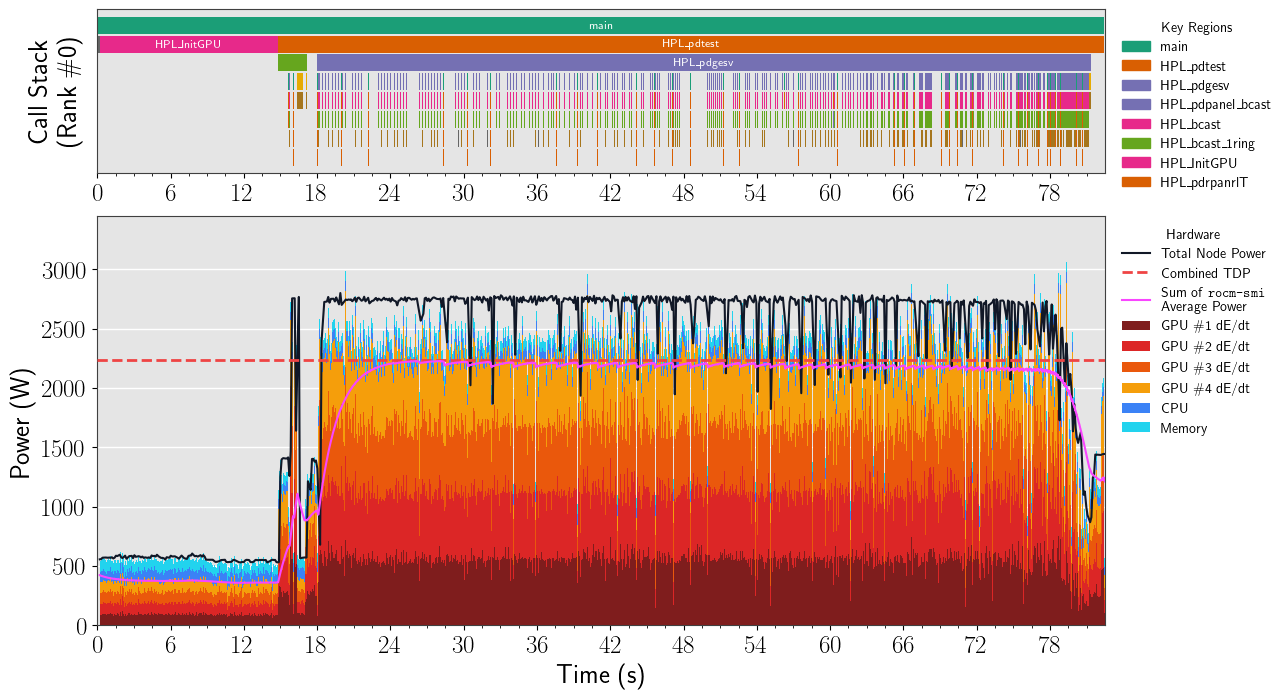

Could not add component metric A2rocm_smi:::current_socket_power:device=0 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=1 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=2 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=3 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=4 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=6 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty


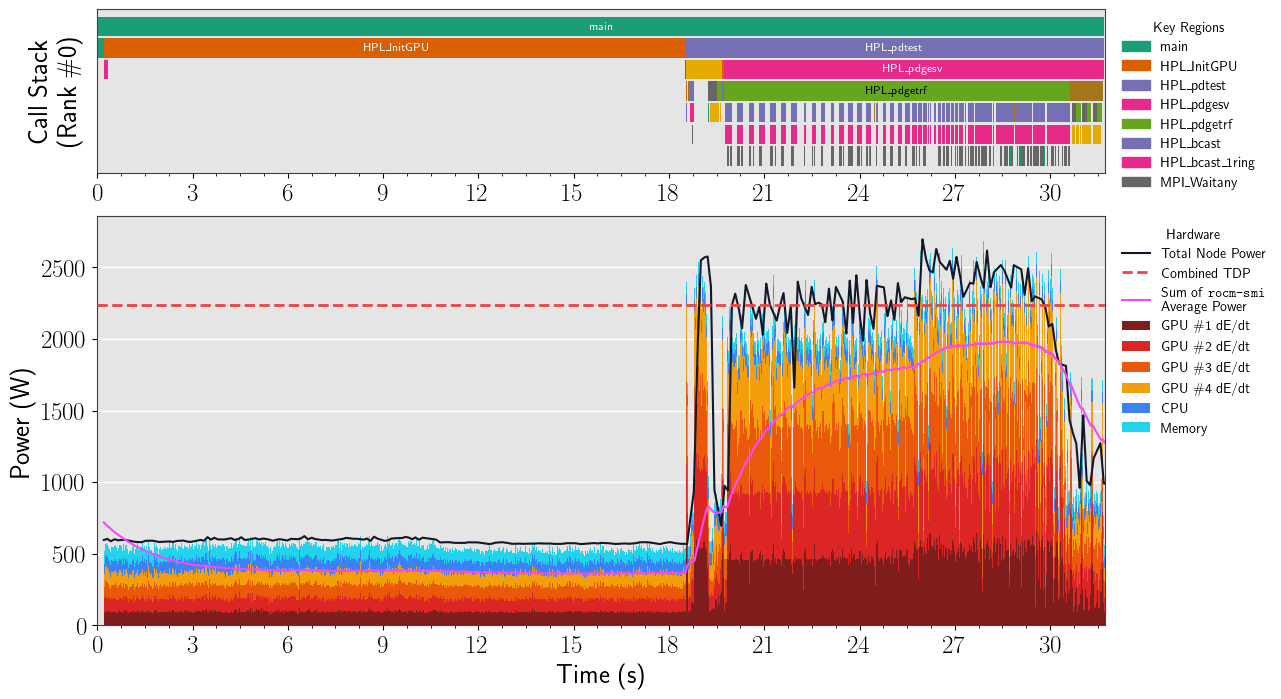

Could not add component metric A2rocm_smi:::power_average:device=0:sensor=0 for combined metric Sum of \texttt{rocm-smi}
Average Power: array of sample points is empty
Could not add component metric A2rocm_smi:::power_average:device=2:sensor=0 for combined metric Sum of \texttt{rocm-smi}
Average Power: array of sample points is empty
Could not add component metric A2rocm_smi:::power_average:device=4:sensor=0 for combined metric Sum of \texttt{rocm-smi}
Average Power: array of sample points is empty
Could not add component metric A2rocm_smi:::power_average:device=6:sensor=0 for combined metric Sum of \texttt{rocm-smi}
Average Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=4 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=6 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is em

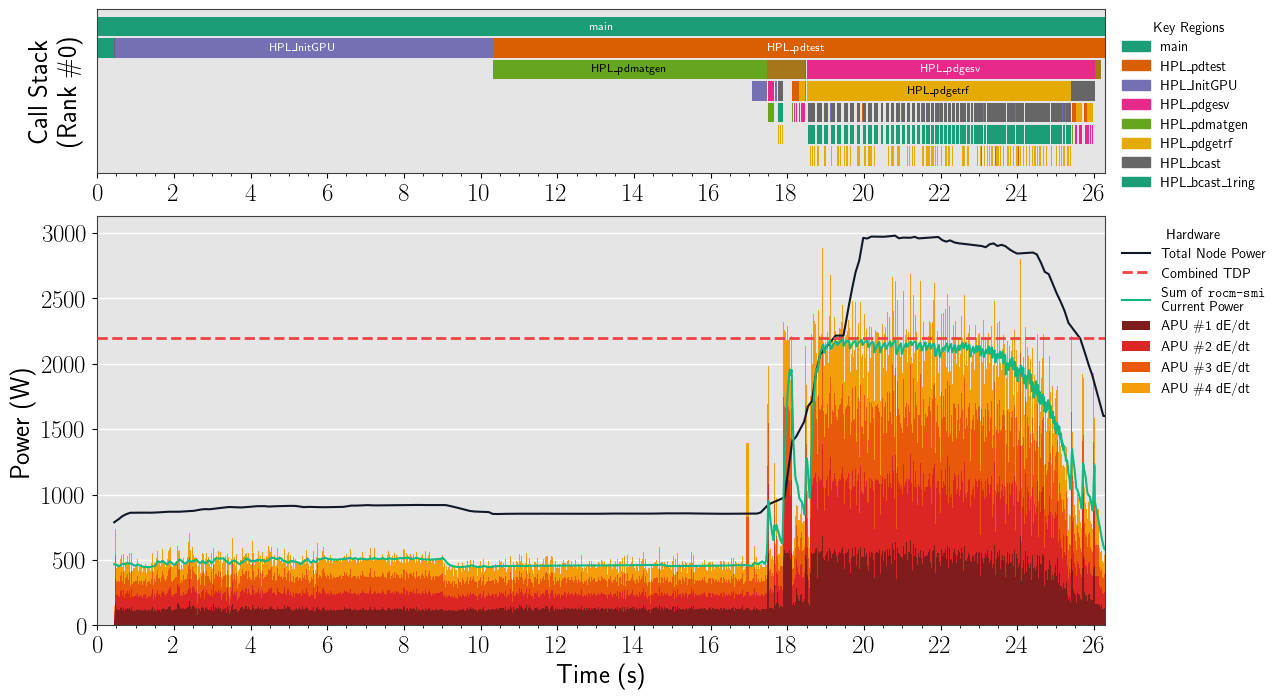

/tmp/ipykernel_2822519/3313893062.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_funcs = call_graph_df.groupby('Name')['Duration'].sum().nlargest(8).index


Could not add component metric A2rocm_smi:::power_average:device=0:sensor=0 for combined metric Sum of \texttt{rocm-smi}
Average Power: array of sample points is empty
Could not add component metric A2rocm_smi:::power_average:device=2:sensor=0 for combined metric Sum of \texttt{rocm-smi}
Average Power: array of sample points is empty
Could not add component metric A2rocm_smi:::power_average:device=4:sensor=0 for combined metric Sum of \texttt{rocm-smi}
Average Power: array of sample points is empty
Could not add component metric A2rocm_smi:::power_average:device=6:sensor=0 for combined metric Sum of \texttt{rocm-smi}
Average Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=4 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=6 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is em

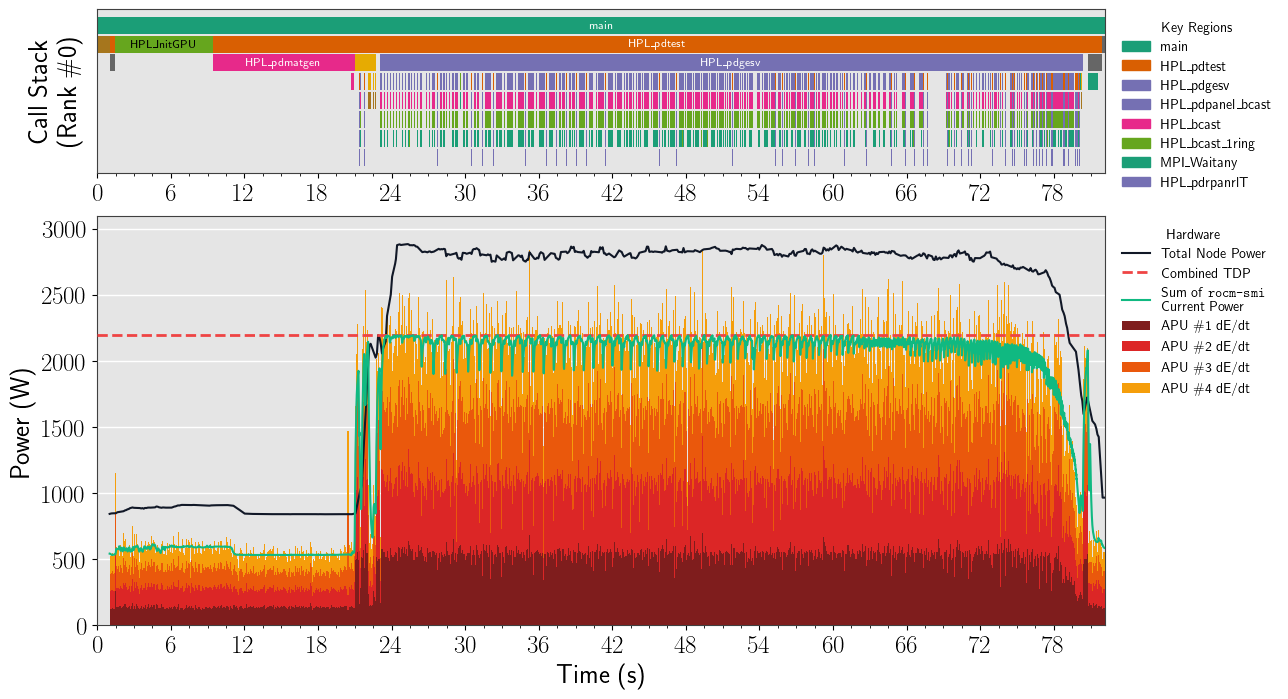

In [32]:
visualize_power_of_runs_stacked_bar(mi250x_rochpl_runs, name='rocHPL (MI250X)', tdp_line=560 * 4)

visualize_power_of_runs_stacked_bar(
    mi250x_rochpl_mxp_runs,
    name='rocHPL-MxP (MI250X)', 
    prefix_replacements=[
        ('HPLMXP_', 'HPL_'),
        ('int HPL_', 'HPL_'),
        ('void HPL_', 'HPL_'),
        ('HPL_p', 'HPL_pd'),
        ('HPL_Warmup', 'HPL_pdwarmup')
    ],
    tdp_line=560 * 4,
)

visualize_power_of_runs_stacked_bar(
    mi300a_rochpl_mxp_runs,
    name='rocHPL-MxP (MI300A)', 
    prefix_replacements=[
        ('HPLMXP_', 'HPL_'),
        ('int HPL_', 'HPL_'),
        ('void HPL_', 'HPL_'),
        ('HPL_p', 'HPL_pd'),
        ('HPL_Warmup', 'HPL_pdwarmup')
    ],
    tdp_line=550 * 4,
    accel_type='APU',
    rank_number=0,
)
visualize_power_of_runs_stacked_bar(mi300a_rochpl_runs, name='rocHPL (MI300A)', tdp_line=550 * 4, rank_number=0, accel_type='APU')


In [33]:
if 'mi250x_hpg_runs' not in globals():
    mi250x_hpg_runs = Ensemble.from_trace_paths(
        [MI250X_TRACES.get('HPG', [])[0]],
        MI250X_HPG_NODE_RANKS,
    )
    
if 'mi250x_hpg_mxp_runs' not in globals():
    mi250x_hpg_mxp_runs = Ensemble.from_trace_paths(
        [MI250X_TRACES.get('HPG_MXP', [])[0]],
        MI250X_HPG_NODE_RANKS,
    )

if 'mi300a_hpg_runs' not in globals():
    mi300a_hpg_runs = Ensemble.from_trace_paths(
        [MI300A_TRACES.get('HPG', [])[0]],
        MI300A_HPG_NODE_RANKS,
    )
    
if 'mi300a_hpg_mxp_runs' not in globals():
    mi300a_hpg_mxp_runs = Ensemble.from_trace_paths(
        [MI300A_TRACES.get('HPG_MXP', [])[0]],
        MI300A_HPG_NODE_RANKS,
    )

Could not add component metric A2rocm_smi:::power_average:device=0:sensor=0 for combined metric Sum of \texttt{rocm-smi}
Average Power: array of sample points is empty
Could not add component metric A2rocm_smi:::power_average:device=2:sensor=0 for combined metric Sum of \texttt{rocm-smi}
Average Power: array of sample points is empty
Could not add component metric A2rocm_smi:::power_average:device=4:sensor=0 for combined metric Sum of \texttt{rocm-smi}
Average Power: array of sample points is empty
Could not add component metric A2rocm_smi:::power_average:device=6:sensor=0 for combined metric Sum of \texttt{rocm-smi}
Average Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=4 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=6 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is em

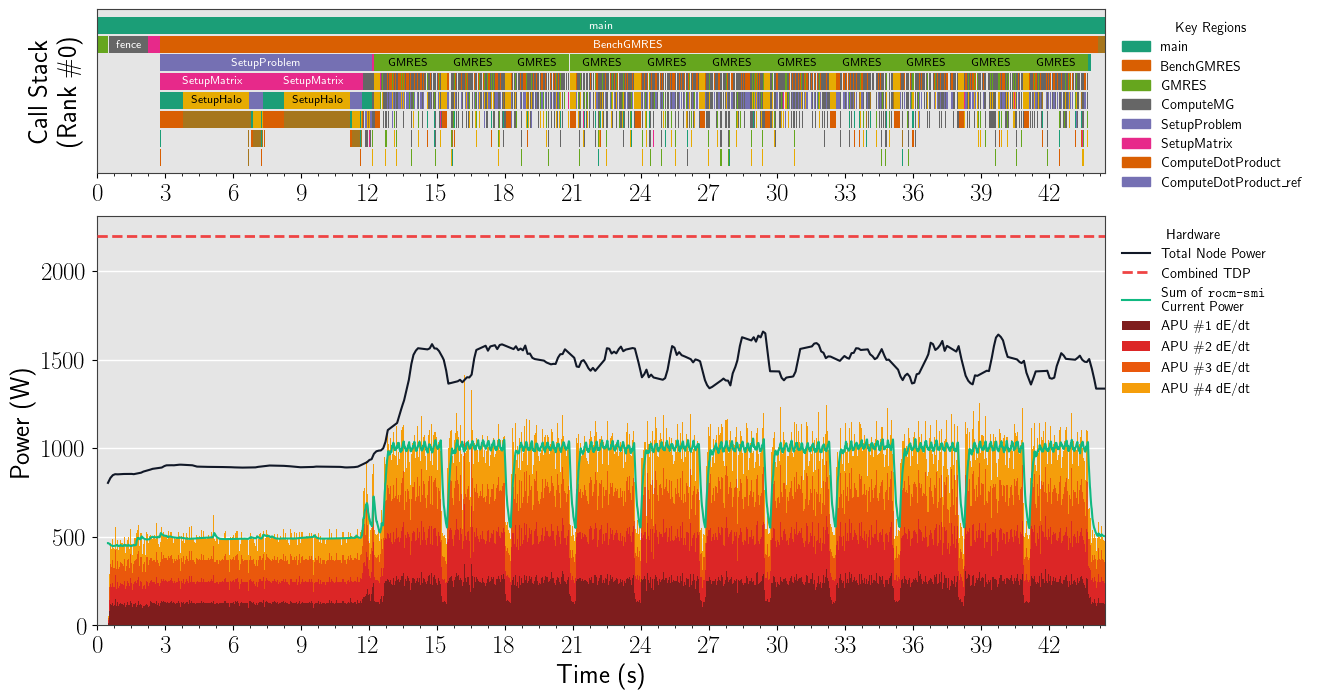

Could not add component metric A2rocm_smi:::power_average:device=0:sensor=0 for combined metric Sum of \texttt{rocm-smi}
Average Power: array of sample points is empty
Could not add component metric A2rocm_smi:::power_average:device=2:sensor=0 for combined metric Sum of \texttt{rocm-smi}
Average Power: array of sample points is empty
Could not add component metric A2rocm_smi:::power_average:device=4:sensor=0 for combined metric Sum of \texttt{rocm-smi}
Average Power: array of sample points is empty
Could not add component metric A2rocm_smi:::power_average:device=6:sensor=0 for combined metric Sum of \texttt{rocm-smi}
Average Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=4 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=6 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is em

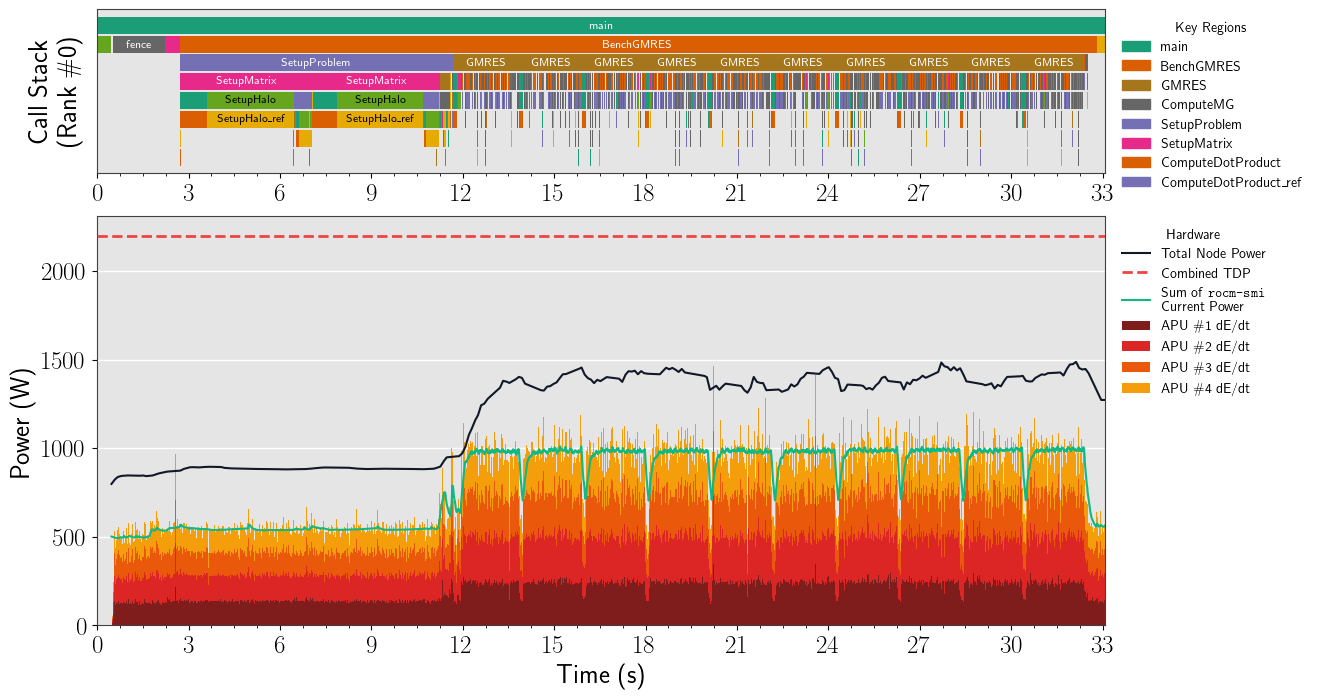

Could not add component metric A2rocm_smi:::current_socket_power:device=0 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=1 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=2 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=3 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=4 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=6 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty


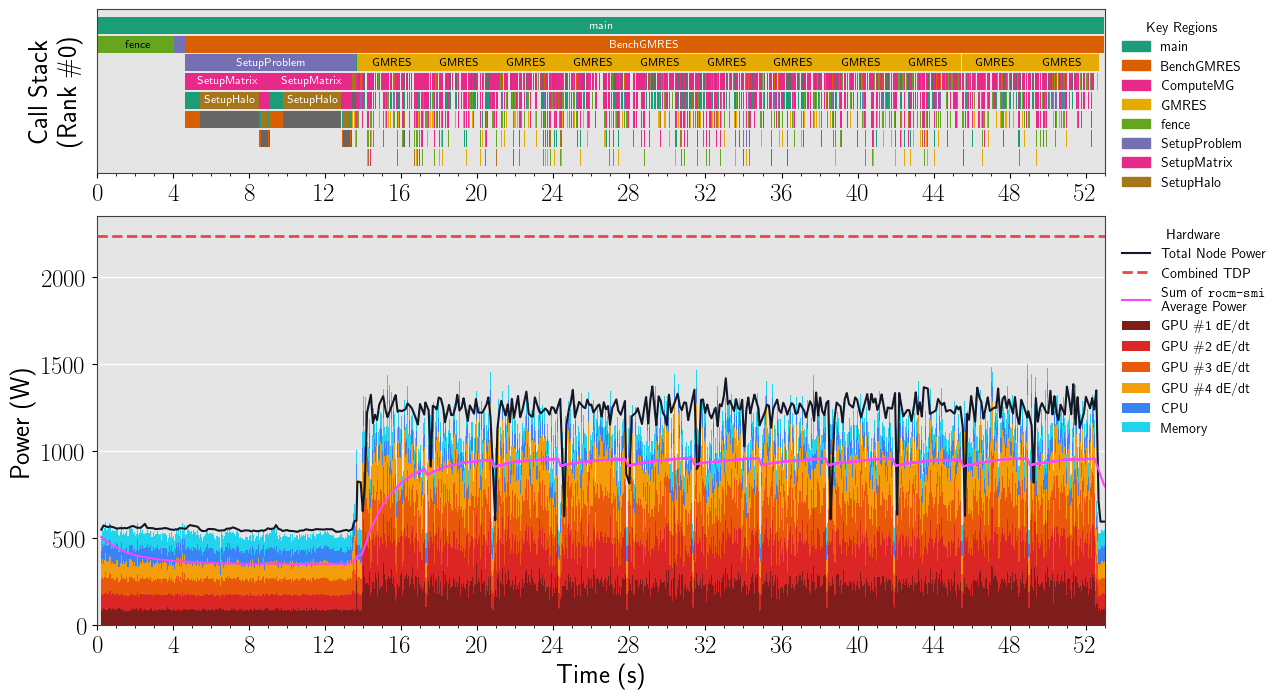

Could not add component metric A2rocm_smi:::current_socket_power:device=0 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=1 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=2 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=3 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=4 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=6 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty


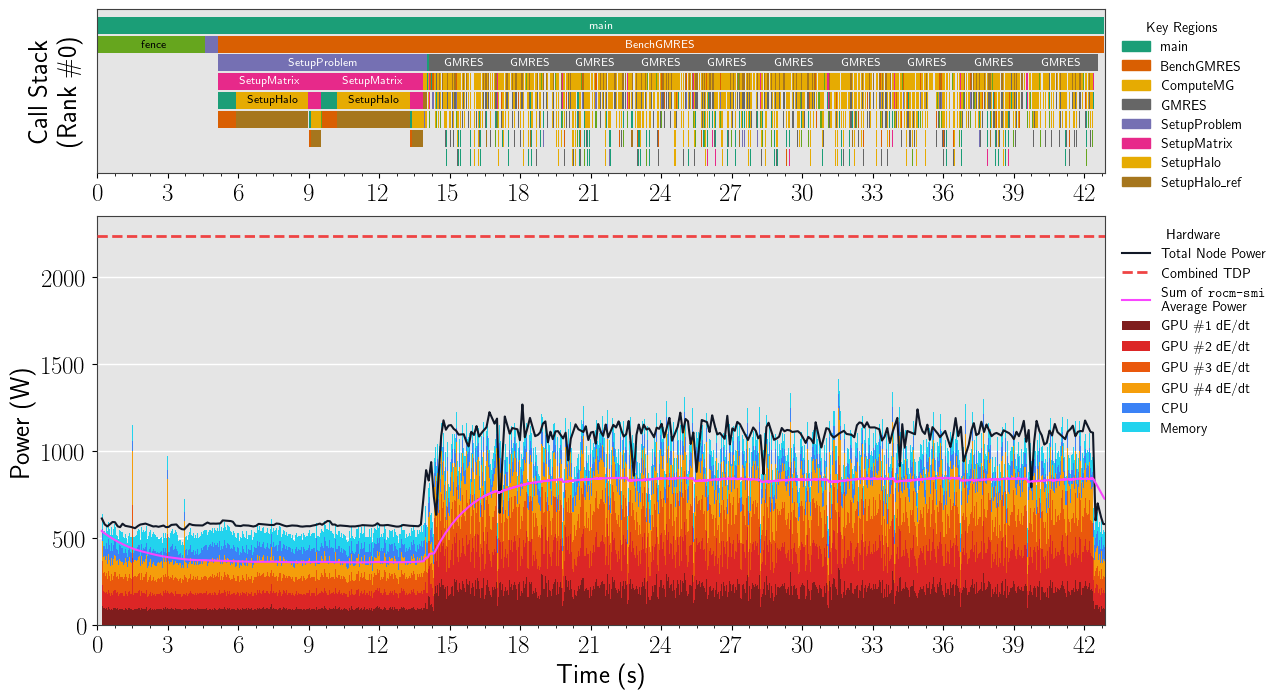

In [34]:
visualize_power_of_runs_stacked_bar(
    mi300a_hpg_runs,
    name='HPG-MxP Full Precision (MI300A)',
    prefix_replacements=[
        ('int ', ''),
        ('void ', '')
    ],
    tdp_line=550 * 4,
    accel_type='APU',
)
visualize_power_of_runs_stacked_bar(
    mi300a_hpg_mxp_runs,
    name='HPG-MxP Mixed Precision (MI300A)',
    prefix_replacements=[
        ('int GMRES_IR', 'int GMRES'),
        ('int ', ''),
        ('void ', '')
    ],
    tdp_line=550 * 4,
    accel_type='APU',
)

visualize_power_of_runs_stacked_bar(
    mi250x_hpg_runs,
    name='HPG-MxP Full Precision (MI250X)',
    prefix_replacements=[
        ('int ', ''),
        ('void ', '')
    ],
    tdp_line=560 * 4
)
visualize_power_of_runs_stacked_bar(
    mi250x_hpg_mxp_runs,
    name='HPG-MxP Mixed Precision (MI250X)',
    prefix_replacements=[
        ('int GMRES_IR', 'int GMRES'),
        ('int ', ''),
        ('void ', '')
    ],
    tdp_line=560 * 4
)


In [35]:
# Get the end time of the notebook
NOTEBOOK_END_TIME = time.time()
print(f"Notebook end time: {NOTEBOOK_END_TIME}")
print(f"Notebook end at {NOTEBOOK_END_TIME} ({datetime.datetime.fromtimestamp(NOTEBOOK_END_TIME)})")

NOTEBOOK_DURATION = NOTEBOOK_END_TIME - NOTEBOOK_START_TIME
print(f"Notebook execution time: {NOTEBOOK_DURATION:.2f} seconds")

Notebook end time: 1766010097.148677
Notebook end at 1766010097.148677 (2025-12-17 17:21:37.148677)
Notebook execution time: 671.49 seconds
